In [2]:
import pandas as pd
import os

# Шлях до ваших сирих даних (змініть на свій, якщо він інший)
DATA_PATH = "C:/University/6 grade/Diploma/AniDB 2020/"

In [3]:
# 1. Завантаження файлів
# Припускаємо, що файли лежать у папці
df_anime = pd.read_csv(os.path.join(DATA_PATH, 'anime.csv'))
df_synopsis = pd.read_csv(os.path.join(DATA_PATH, 'anime_with_synopsis.csv'))

In [4]:
# 2. Огляд структури (перші кілька рядків)
print(f"Розмір основної таблиці: {df_anime.shape}")
print(f"Розмір таблиці з синопсисами: {df_synopsis.shape}")

Розмір основної таблиці: (17562, 35)
Розмір таблиці з синопсисами: (16214, 5)


In [5]:
# 3. Виведення назв колонок
print("Колонки df_anime:", df_anime.columns.tolist())
print("Колонки df_synopsis:", df_synopsis.columns.tolist())

Колонки df_anime: ['MAL_ID', 'Name', 'Score', 'Genres', 'English name', 'Japanese name', 'Type', 'Episodes', 'Aired', 'Premiered', 'Producers', 'Licensors', 'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity', 'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped', 'Plan to Watch', 'Score-10', 'Score-9', 'Score-8', 'Score-7', 'Score-6', 'Score-5', 'Score-4', 'Score-3', 'Score-2', 'Score-1']
Колонки df_synopsis: ['MAL_ID', 'Name', 'Score', 'Genres', 'sypnopsis']


In [6]:
# Перейменування колонки 'sypnopsis' на 'synopsis'
df_synopsis = df_synopsis.rename(columns={'sypnopsis': 'synopsis'})

In [7]:
print("Колонки df_synopsis:", df_synopsis.columns.tolist())

Колонки df_synopsis: ['MAL_ID', 'Name', 'Score', 'Genres', 'synopsis']


In [8]:
# 4. Перевірка пропусків та заглушок у колонці 'synopsis'
total_rows = len(df_synopsis)

# Заглушка 1
placeholder1 = "No synopsis has been added for this series yet. Click here to update this information."
count1 = (df_synopsis['synopsis'] == placeholder1).sum()
percent1 = (count1 / total_rows) * 100

# Заглушка 2
placeholder2 = "No synopsis information has been added to this title. Help improve our database by adding a synopsis here ."
count2 = (df_synopsis['synopsis'] == placeholder2).sum()
percent2 = (count2 / total_rows) * 100

# Пропуски (NaN)
nan_count = df_synopsis['synopsis'].isnull().sum()
nan_percent = (nan_count / total_rows) * 100

print(f"Заглушка 1: {count1} записів ({percent1:.2f}%)")
print(f"Заглушка 2: {count2} записів ({percent2:.2f}%)")
print(f"Пропуски: {nan_count} записів ({nan_percent:.2f}%)")

Заглушка 1: 35 записів (0.22%)
Заглушка 2: 709 записів (4.37%)
Пропуски: 8 записів (0.05%)


In [9]:
df_synopsis.loc[df_synopsis['synopsis'] == placeholder1, 'synopsis'] = None
df_synopsis.loc[df_synopsis['synopsis'] == placeholder2, 'synopsis'] = None

# Перевірка після заміни
nan_count_after = df_synopsis['synopsis'].isnull().sum()
nan_percent_after = (nan_count_after / total_rows) * 100

print(f"Пропуски після заміни: {nan_count_after} записів ({nan_percent_after:.2f}%)")

Пропуски після заміни: 752 записів (4.64%)


In [10]:
# 5. Перевірка співвідношення між df_anime та df_synopsis за MAL_ID
anime_ids = set(df_anime['MAL_ID'])
synopsis_ids = set(df_synopsis['MAL_ID'])

# Аніме у df_synopsis, але не у df_anime
only_in_synopsis = synopsis_ids - anime_ids
count_only_synopsis = len(only_in_synopsis)
percent_only_synopsis = (count_only_synopsis / len(synopsis_ids)) * 100

# Аніме у df_anime, але не у df_synopsis
only_in_anime = anime_ids - synopsis_ids
count_only_anime = len(only_in_anime)
percent_only_anime = (count_only_anime / len(anime_ids)) * 100

# Спільні аніме
common_ids = anime_ids & synopsis_ids
count_common = len(common_ids)

print(f"Всього у df_anime: {len(anime_ids)}")
print(f"Всього у df_synopsis: {len(synopsis_ids)}")
print(f"Спільних аніме: {count_common}")
print(f"\nТільки у df_synopsis: {count_only_synopsis} записів ({percent_only_synopsis:.2f}%)")
print(f"Тільки у df_anime: {count_only_anime} записів ({percent_only_anime:.2f}%)")

Всього у df_anime: 17562
Всього у df_synopsis: 16214
Спільних аніме: 16214

Тільки у df_synopsis: 0 записів (0.00%)
Тільки у df_anime: 1348 записів (7.68%)


In [11]:
# 6. Перевірка та видалення дуплікатів
anime_dup_count = df_anime.duplicated().sum()
synopsis_dup_count = df_synopsis.duplicated().sum()

print(f"Повні дуплікатні рядки в df_anime: {anime_dup_count}")
print(f"Повні дуплікатні рядки в df_synopsis: {synopsis_dup_count}")

df_anime = df_anime.drop_duplicates()
df_synopsis = df_synopsis.drop_duplicates()

print(f"Після видалення: df_anime = {len(df_anime)} рядків, df_synopsis = {len(df_synopsis)} рядків")

Повні дуплікатні рядки в df_anime: 0
Повні дуплікатні рядки в df_synopsis: 0
Після видалення: df_anime = 17562 рядків, df_synopsis = 16214 рядків


In [12]:
anime_dup_by_id = df_anime.duplicated(subset=['MAL_ID']).sum()
print(f"Дуплікатні MAL_ID в df_anime: {anime_dup_by_id}")

synopsis_dup_by_id = df_synopsis.duplicated(subset=['MAL_ID']).sum()
print(f"Дуплікатні MAL_ID в df_synopsis: {synopsis_dup_by_id}")

Дуплікатні MAL_ID в df_anime: 0
Дуплікатні MAL_ID в df_synopsis: 0


In [13]:
# 7. Перевірка збігу даних між df_anime та df_synopsis за MAL_ID
# Об'єднаємо датафрейми за MAL_ID
df_merged = pd.merge(df_synopsis[['MAL_ID', 'Name', 'Score', 'Genres']], 
                      df_anime[['MAL_ID', 'Name', 'Score', 'Genres']], 
                      on='MAL_ID', 
                      suffixes=('_synopsis', '_anime'),
                      how='inner')

# Перевіримо, чи збігаються значення
name_mismatch = (df_merged['Name_synopsis'] != df_merged['Name_anime']).sum()
score_mismatch = (df_merged['Score_synopsis'] != df_merged['Score_anime']).sum()
genres_mismatch = (df_merged['Genres_synopsis'] != df_merged['Genres_anime']).sum()

print(f"Розбіжності в Name: {name_mismatch} записів")
print(f"Розбіжності в Score: {score_mismatch} записів")
print(f"Розбіжності в Genres: {genres_mismatch} записів")

# Виведемо приклади розбіжностей для Name
if name_mismatch > 0:
    print("\nПриклади розбіжностей в Name:")
    print(df_merged[df_merged['Name_synopsis'] != df_merged['Name_anime']][['MAL_ID', 'Name_synopsis', 'Name_anime']].head())

# Виведемо приклади розбіжностей для Score
if score_mismatch > 0:
    print("\nПриклади розбіжностей в Score:")
    print(df_merged[df_merged['Score_synopsis'] != df_merged['Score_anime']][['MAL_ID', 'Score_synopsis', 'Score_anime']].head())

# Виведемо приклади розбіжностей для Genres
if genres_mismatch > 0:
    print("\nПриклади розбіжностей в Genres:")
    print(df_merged[df_merged['Genres_synopsis'] != df_merged['Genres_anime']][['MAL_ID', 'Genres_synopsis', 'Genres_anime']].head())

Розбіжності в Name: 0 записів
Розбіжності в Score: 0 записів
Розбіжності в Genres: 0 записів


In [14]:
# 8. Додавання синопсисів до df_anime
# Створимо словник MAL_ID -> synopsis з df_synopsis
synopsis_dict = dict(zip(df_synopsis['MAL_ID'], df_synopsis['synopsis']))

# Додамо нову колонку з синопсисами (NaN для аніме, яких нема в df_synopsis)
df_anime['synopsis'] = df_anime['MAL_ID'].map(synopsis_dict)

# Перевірка кількості NaN у синопсисах
total_anime = len(df_anime)
nan_count_synopsis = df_anime['synopsis'].isnull().sum()
nan_percent_synopsis = (nan_count_synopsis / total_anime) * 100

print(f"Всього аніме в df_anime: {total_anime}")
print(f"NaN у колонці synopsis: {nan_count_synopsis} записів ({nan_percent_synopsis:.2f}%)")
print(f"З синопсисами: {total_anime - nan_count_synopsis} записів ({100 - nan_percent_synopsis:.2f}%)")

Всього аніме в df_anime: 17562
NaN у колонці synopsis: 2100 записів (11.96%)
З синопсисами: 15462 записів (88.04%)


In [15]:
# 9. Перевірка кількості "Unknown" у колонках імен
name_columns = ['Name', 'English name', 'Japanese name']

print("Перевірка 'Unknown' значень у колонках імен:")
for col in name_columns:
    if col in df_anime.columns:
        unknown_count = (df_anime[col] == 'Unknown').sum()
        unknown_percent = (unknown_count / len(df_anime)) * 100
        nan_count = df_anime[col].isnull().sum()
        nan_percent = (nan_count / len(df_anime)) * 100
        
        print(f"\n{col}:")
        print(f"  Unknown: {unknown_count} записів ({unknown_percent:.2f}%)")
        print(f"  NaN: {nan_count} записів ({nan_percent:.2f}%)")
    else:
        print(f"\n{col}: колонка не знайдена")

Перевірка 'Unknown' значень у колонках імен:

Name:
  Unknown: 0 записів (0.00%)
  NaN: 0 записів (0.00%)

English name:
  Unknown: 10565 записів (60.16%)
  NaN: 0 записів (0.00%)

Japanese name:
  Unknown: 48 записів (0.27%)
  NaN: 0 записів (0.00%)


In [16]:
# 10. Замінити Unknown на NaN у колонці 'English name'
print("Заміна 'Unknown' на NaN у колонці 'English name':")

# Замінити 'Unknown' на None (NaN)
df_anime.loc[df_anime['English name'] == 'Unknown', 'English name'] = None

# Перевірка після заміни
nan_count_after = df_anime['English name'].isnull().sum()
nan_percent_after = (nan_count_after / len(df_anime)) * 100

print(f"NaN після заміни: {nan_count_after} записів ({nan_percent_after:.2f}%)")

Заміна 'Unknown' на NaN у колонці 'English name':
NaN після заміни: 10565 записів (60.16%)


In [17]:
# 11а. Дослідження колонки Score перед конвертацією
print("=== ДОСЛІДЖЕННЯ КОЛОНКИ SCORE ===\n")

# Перевіримо тип даних
print(f"Тип даних: {df_anime['Score'].dtype}")
print(f"Всього записів: {len(df_anime)}\n")

# Подивимось на унікальні значення
print("Кількість унікальних значень:", df_anime['Score'].nunique())
print("\nПерші 20 унікальних значень:")
print(df_anime['Score'].unique()[:20])

# Перевіримо на NaN ДО конвертації
nan_before = df_anime['Score'].isnull().sum()
print(f"\nNaN ДО конвертації: {nan_before} записів")

# Перевіримо на пропуски/порожні рядки
empty_count = (df_anime['Score'] == '').sum()
print(f"Порожні рядки (''):  {empty_count} записів")

# Перевіримо на 'N/A', 'None', тощо
print("\nПоширені значення, які можуть викликати NaN:")
for val in ['N/A', 'None', 'unknown', '-', ' ', 'NA']:
    count = (df_anime['Score'] == val).sum()
    if count > 0:
        print(f"  '{val}': {count} записів")

# Подивимось на значення, які НЕ можна конвертувати в числа
print("\nПриклади значень, які НЕ можна конвертувати:")
test_conversion = pd.to_numeric(df_anime['Score'], errors='coerce')
invalid_mask = test_conversion.isnull() & df_anime['Score'].notna()
invalid_values = df_anime.loc[invalid_mask, 'Score'].unique()
print(invalid_values[:20])
print(f"Всього таких значень: {invalid_mask.sum()}")

=== ДОСЛІДЖЕННЯ КОЛОНКИ SCORE ===

Тип даних: str
Всього записів: 17562

Кількість унікальних значень: 533

Перші 20 унікальних значень:
<ArrowStringArray>
['8.78', '8.39', '8.24', '7.27', '6.98', '7.95', '8.06', '7.59', '8.15',
 '8.76', '7.91', '8.52',  '7.9', '6.38', '7.94', '7.42', '7.76', '7.32',
 '7.51', '8.32']
Length: 20, dtype: str

NaN ДО конвертації: 0 записів
Порожні рядки (''):  0 записів

Поширені значення, які можуть викликати NaN:

Приклади значень, які НЕ можна конвертувати:
<ArrowStringArray>
['Unknown']
Length: 1, dtype: str
Всього таких значень: 5141


In [18]:
# 11б. Дослідження аніме з Unknown Score
print("=== ДОСЛІДЖЕННЯ АНІМЕ З UNKNOWN SCORE ===\n")

# Знайдемо рядки з Unknown Score
unknown_score_mask = df_anime['Score'] == 'Unknown'
unknown_score_count = unknown_score_mask.sum()

print(f"Всього аніме з Unknown Score: {unknown_score_count}\n")

# Виведемо перші 10 аніме з Unknown Score та їх деталі
print("Деталі першого аніме з Unknown Score:\n")
unknown_anime_indices = df_anime[unknown_score_mask].index[:10]

for idx in unknown_anime_indices:
    anime = df_anime.loc[idx]
    print(f"MAL_ID: {anime['MAL_ID']} | Name: {anime['Name']}")
    print(f"  Score: {anime['Score']}")
    print(f"  Ranked: {anime['Ranked']}")
    print(f"  Score-10: {anime['Score-10']}")
    print(f"  Score-9: {anime['Score-9']}")
    print(f"  Score-8: {anime['Score-8']}")
    print(f"  Score-7: {anime['Score-7']}")
    print(f"  Score-6: {anime['Score-6']}")
    print(f"  Score-5: {anime['Score-5']}")
    print(f"  Score-4: {anime['Score-4']}")
    print(f"  Score-3: {anime['Score-3']}")
    print(f"  Score-2: {anime['Score-2']}")
    print(f"  Score-1: {anime['Score-1']}")
    print()

=== ДОСЛІДЖЕННЯ АНІМЕ З UNKNOWN SCORE ===

Всього аніме з Unknown Score: 5141

Деталі першого аніме з Unknown Score:

MAL_ID: 1547 | Name: Obake no Q-tarou
  Score: Unknown
  Ranked: 11270.0
  Score-10: 8.0
  Score-9: 5.0
  Score-8: 6.0
  Score-7: 20.0
  Score-6: 28.0
  Score-5: 31.0
  Score-4: 6.0
  Score-3: 6.0
  Score-2: 2.0
  Score-1: 10.0

MAL_ID: 1656 | Name: PostPet Momobin
  Score: Unknown
  Ranked: 11598.0
  Score-10: 7.0
  Score-9: 2.0
  Score-8: 6.0
  Score-7: 13.0
  Score-6: 17.0
  Score-5: 22.0
  Score-4: 15.0
  Score-3: 12.0
  Score-2: 7.0
  Score-1: 10.0

MAL_ID: 1739 | Name: Shibawanko no Wa no Kokoro
  Score: Unknown
  Ranked: 11947.0
  Score-10: 6.0
  Score-9: 4.0
  Score-8: 23.0
  Score-7: 28.0
  Score-6: 18.0
  Score-5: 17.0
  Score-4: 1.0
  Score-3: 3.0
  Score-2: Unknown
  Score-1: 8.0

MAL_ID: 1863 | Name: Silk Road Shounen Yuuto
  Score: Unknown
  Ranked: 12096.0
  Score-10: 3.0
  Score-9: 1.0
  Score-8: 2.0
  Score-7: 9.0
  Score-6: 5.0
  Score-5: 9.0
  Score-4

Аналіз розподілу оцінок (Score):

Оцінки 0: 0 записів (0.00%)
Unknown/NaN: 5141 записів (29.27%)
Дійсних оцінок (1-10): 12421 записів (70.73%)

Розподіл оцінок за діапазонами:
  (0, 1]: 0 записів (0.00% від валідних, 0.00% від всіх)
  (1, 2]: 1 записів (0.01% від валідних, 0.01% від всіх)
  (2, 3]: 12 записів (0.10% від валідних, 0.07% від всіх)
  (3, 4]: 48 записів (0.39% від валідних, 0.27% від всіх)
  (4, 5]: 452 записів (3.64% від валідних, 2.57% від всіх)
  (5, 6]: 2880 записів (23.19% від валідних, 16.40% від всіх)
  (6, 7]: 5284 записів (42.54% від валідних, 30.09% від всіх)
  (7, 8]: 3211 записів (25.85% від валідних, 18.28% від всіх)
  (8, 9]: 524 записів (4.22% від валідних, 2.98% від всіх)
  (9, 10]: 9 записів (0.07% від валідних, 0.05% від всіх)


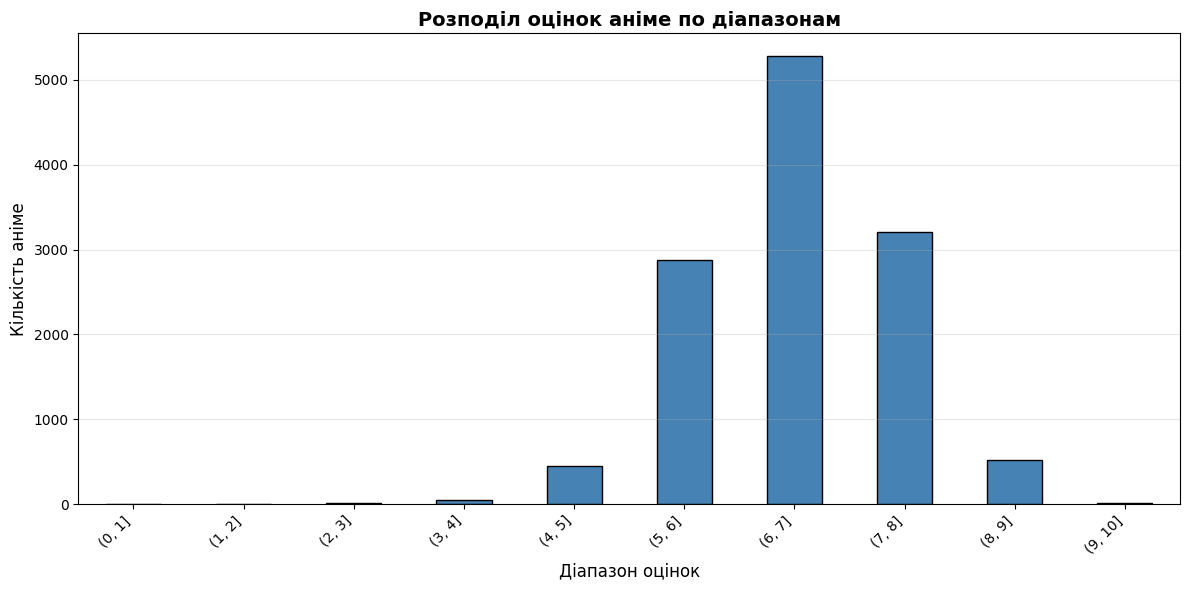

In [19]:
# 11. Аналіз розподілу оцінок (Score)
import matplotlib.pyplot as plt
import numpy as np

print("Аналіз розподілу оцінок (Score):")

# Замінити 'Unknown' на NaN перед конвертацією
df_anime['Score'] = df_anime['Score'].replace('Unknown', np.nan)

# Конвертуємо Score в float
df_anime['Score'] = pd.to_numeric(df_anime['Score'], errors='coerce')

total_anime = len(df_anime)

# Перевірка на 0 та Unknown значення
zero_count = (df_anime['Score'] == 0).sum()
zero_percent = (zero_count / total_anime) * 100

unknown_count = df_anime['Score'].isnull().sum()
unknown_percent = (unknown_count / total_anime) * 100

print(f"\nОцінки 0: {zero_count} записів ({zero_percent:.2f}%)")
print(f"Unknown/NaN: {unknown_count} записів ({unknown_percent:.2f}%)")

# Фільтруємо оцінки від 1 до 10
valid_scores = df_anime[(df_anime['Score'] > 0) & (df_anime['Score'] <= 10)]['Score']
valid_count = len(valid_scores)
valid_percent = (valid_count / total_anime) * 100

print(f"Дійсних оцінок (1-10): {valid_count} записів ({valid_percent:.2f}%)")

# Розбиваємо на 10 діапазонів
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = ['(0, 1]', '(1, 2]', '(2, 3]', '(3, 4]', '(4, 5]', '(5, 6]', '(6, 7]', '(7, 8]', '(8, 9]', '(9, 10]']

score_distribution = pd.cut(valid_scores, bins=bins, labels=labels, right=True)
score_counts = score_distribution.value_counts().sort_index()

print("\nРозподіл оцінок за діапазонами:")
for label, count in score_counts.items():
    percent_range = (count / valid_count) * 100
    percent_total = (count / total_anime) * 100
    print(f"  {label}: {count} записів ({percent_range:.2f}% від валідних, {percent_total:.2f}% від всіх)")

# Побудова діаграми
plt.figure(figsize=(12, 6))
score_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Розподіл оцінок аніме по діапазонам', fontsize=14, fontweight='bold')
plt.xlabel('Діапазон оцінок', fontsize=12)
plt.ylabel('Кількість аніме', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# 12. Конвертація Ranked та колонок Score-* у числовий формат
print("Конвертація Ranked та колонок Score-* у числовий формат:")

# Перетворюємо Ranked на числа. Помилки (Unknown) стануть NaN.
df_anime['Ranked'] = pd.to_numeric(df_anime['Ranked'], errors='coerce')

# Перетворюємо колонки Score-1...10 на числа
score_cols = [f'Score-{i}' for i in range(1, 11)]
for col in score_cols:
    df_anime[col] = pd.to_numeric(df_anime[col], errors='coerce')

print("Конвертація завершена.\n")

Конвертація Ranked та колонок Score-* у числовий формат:


Конвертація завершена.



In [21]:
# 13. Аналіз зв'язків між Score та Ranked
print("Аналіз зв'язків між Score та Ranked:")

total_anime = len(df_anime)

# Перевірка: скільки Unknown Score мають відомий Ranked?
missing_score_with_rank = df_anime[df_anime['Score'].isnull() & df_anime['Ranked'].notnull()].shape[0]
missing_score_with_rank_percent = (missing_score_with_rank / total_anime) * 100
print(f"Кількість аніме без Score, але з відомим Ranked: {missing_score_with_rank} записів ({missing_score_with_rank_percent:.2f}%)")

# Перевірка: скільки Ranked Unknown
ranked_unknown_count = df_anime[df_anime['Ranked'].isnull()].shape[0]
ranked_unknown_percent = (ranked_unknown_count / total_anime) * 100
print(f"Кількість аніме з Unknown Ranked: {ranked_unknown_count} записів ({ranked_unknown_percent:.2f}%)")

# Перевірка: скільки Unknown Ranked мають відомий Score
ranked_unknown_with_score = df_anime[df_anime['Ranked'].isnull() & df_anime['Score'].notnull()].shape[0]
ranked_unknown_with_score_percent = (ranked_unknown_with_score / total_anime) * 100
print(f"Кількість аніме з Unknown Ranked, але відомим Score: {ranked_unknown_with_score} записів ({ranked_unknown_with_score_percent:.2f}%)")

# Перевірка: скільки аніме мають і Unknown Score, і Unknown Ranked
both_unknown_count = df_anime[df_anime['Score'].isnull() & df_anime['Ranked'].isnull()].shape[0]
both_unknown_percent = (both_unknown_count / total_anime) * 100
print(f"Кількість аніме з Unknown Score та Unknown Ranked: {both_unknown_count} записів ({both_unknown_percent:.2f}%)")

Аналіз зв'язків між Score та Ranked:
Кількість аніме без Score, але з відомим Ranked: 4737 записів (26.97%)
Кількість аніме з Unknown Ranked: 1762 записів (10.03%)
Кількість аніме з Unknown Ranked, але відомим Score: 1358 записів (7.73%)
Кількість аніме з Unknown Score та Unknown Ranked: 404 записів (2.30%)


In [22]:
# 14. Перевірка кількості Unknown/NaN у колонках Score-*
print("Перевірка кількості Unknown/NaN у колонках Score-*:")

score_cols = [f'Score-{i}' for i in range(1, 11)]
total_anime = len(df_anime)

for col in score_cols:
    if col in df_anime.columns:
        unknown_count = df_anime[col].isnull().sum()
        unknown_percent = (unknown_count / total_anime) * 100
        print(f"{col}: {unknown_count} записів ({unknown_percent:.2f}%)")
    else:
        print(f"{col}: колонка не знайдена")

Перевірка кількості Unknown/NaN у колонках Score-*:
Score-1: 459 записів (2.61%)
Score-2: 1597 записів (9.09%)
Score-3: 1307 записів (7.44%)
Score-4: 977 записів (5.56%)
Score-5: 584 записів (3.33%)
Score-6: 511 записів (2.91%)
Score-7: 503 записів (2.86%)
Score-8: 1371 записів (7.81%)
Score-9: 3167 записів (18.03%)
Score-10: 437 записів (2.49%)


In [23]:
# 15. Перевірка кількості аніме з 2+ невідомими Score-*
print("Перевірка кількості аніме з 2+ невідомими Score-*:")

score_cols = [f'Score-{i}' for i in range(1, 11)]
total_anime = len(df_anime)

# Підрахуємо кількість NaN в Score-* для кожного аніме
nan_counts = df_anime[score_cols].isnull().sum(axis=1)

# Аніме з 2+ NaN
two_or_more_nan = (nan_counts >= 2).sum()
two_or_more_percent = (two_or_more_nan / total_anime) * 100

print(f"Аніме з 2+ невідомими Score-*: {two_or_more_nan} записів ({two_or_more_percent:.2f}%)")

# Додатково: розподіл кількості NaN
print("\nРозподіл кількості невідомих Score-* на аніме:")
for i in range(11):
    count = (nan_counts == i).sum()
    if count > 0:
        percent = (count / total_anime) * 100
        print(f"  {i} невідомих: {count} записів ({percent:.2f}%)")

Перевірка кількості аніме з 2+ невідомими Score-*:
Аніме з 2+ невідомими Score-*: 2167 записів (12.34%)

Розподіл кількості невідомих Score-* на аніме:
  0 невідомих: 13436 записів (76.51%)
  1 невідомих: 1959 записів (11.15%)
  2 невідомих: 889 записів (5.06%)
  3 невідомих: 427 записів (2.43%)
  4 невідомих: 243 записів (1.38%)
  5 невідомих: 134 записів (0.76%)
  6 невідомих: 71 записів (0.40%)
  7 невідомих: 40 записів (0.23%)
  8 невідомих: 17 записів (0.10%)
  9 невідомих: 49 записів (0.28%)
  10 невідомих: 297 записів (1.69%)


In [24]:
# 16. Функції для розрахунку оцінок

def estimate_methods(df, target_idx):
    """
    Розраховує оцінку трьома методами для аніме з відсутнім Score.
    """
    target_rank = df.loc[target_idx, 'Ranked']
    
    # --- Метод 1: Інтерполяція за сусідніми рангами ---
    # Шукаємо аніме з рангом n-1 та n+1
    prev_score = df[df['Ranked'] == target_rank - 1]['Score'].values
    next_score = df[df['Ranked'] == target_rank + 1]['Score'].values
    
    m1 = np.nan
    if len(prev_score) > 0 and len(next_score) > 0:
        m1 = (prev_score[0] + next_score[0]) / 2

    # --- Метод 2: Зважене середнє голосів ---
    # Формула: (1*S1 + 2*S2 + ... + 10*S10) / (S1 + S2 + ... + S10)
    counts = df.loc[target_idx, score_cols].values
    weights = np.arange(1, 11)
    
    m2 = np.nan
    if np.nansum(counts) > 0:
        m2 = np.nansum(counts * weights) / np.nansum(counts)

    # --- Метод 3: Середнє арифметичне ---
    m3 = np.nan
    if not np.isnan(m1) and not np.isnan(m2):
        m3 = (m1 + m2) / 2
        
    return m1, m2, m3

print("Функції для розрахунку оцінок визначені.")

Функції для розрахунку оцінок визначені.


In [25]:
# Тестування на 10 рандомних аніме
print("Тестування методів на 10 випадкових аніме з повними даними:")

# Вибираємо дані, де все відомо (Score, Ranked та всі Score-X не NaN)
test_pool = df_anime.dropna(subset=['Score', 'Ranked'] + score_cols)
samples = test_pool.sample(10, random_state=42)  # random_state для відтворення результату

results = []

for idx in samples.index:
    real_score = samples.loc[idx, 'Score']
    name = samples.loc[idx, 'Name']
    m1, m2, m3 = estimate_methods(df_anime, idx)
    
    results.append({
        'Name': name[:30],
        'Real': real_score,
        'M1 (Rank)': round(m1, 2) if not np.isnan(m1) else None,
        'M2 (Votes)': round(m2, 2) if not np.isnan(m2) else None,
        'M3 (Hybrid)': round(m3, 2) if not np.isnan(m3) else None,
        'Error M3': round(abs(real_score - m3), 3) if not np.isnan(m3) else None
    })

# Виводимо таблицю результатів
res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

mae = res_df['Error M3'].dropna().mean()
print(f"\nСередня абсолютна помилка (MAE) для Метод 3: {mae:.4f}")

Тестування методів на 10 випадкових аніме з повними даними:
                          Name  Real  M1 (Rank)  M2 (Votes)  M3 (Hybrid)  Error M3
            100% Pascal-sensei  5.60       5.60        5.14         5.37     0.229
                  SSSS.Gridman  7.19        NaN        7.13          NaN       NaN
                      Kujakuou  5.95       5.95        5.94         5.94     0.007
    Dororon Enma-kun Meeramera  6.53        NaN        6.41          NaN       NaN
                        Tarzan  5.34       5.35        4.76         5.06     0.283
               Haru no Shikumi  4.53       4.48        4.10         4.29     0.238
                   Yuukan Club  5.86        NaN        5.74          NaN       NaN
Paniponi Dash!: Danjite Okonae  7.51        NaN        7.54          NaN       NaN
                   Youjo Senki  8.00        NaN        7.96          NaN       NaN
              Marriage: Kekkon  5.43        NaN        5.25          NaN       NaN

Середня абсолютна помилка 

In [26]:
import seaborn as sns

# 1. Отримуємо всі дійсні ранги
existing_ranks = df_anime['Ranked'].dropna().sort_values().unique()
max_rank = int(existing_ranks.max())
full_range = set(range(1, max_rank + 1))

# 2. Знаходимо "дірки" в нумерації
missing_in_sequence = full_range - set(existing_ranks)

print(f"Максимальний ранг у базі: {max_rank}")
print(f"Кількість аніме в базі: {len(df_anime)}")
print(f"Кількість 'дірок' у самій послідовності рангів: {len(missing_in_sequence)}")

if len(missing_in_sequence) > 0:
    print(f"Перші 10 пропущених номерів рангів: {sorted(list(missing_in_sequence))[:10]}")

Максимальний ранг у базі: 15780
Кількість аніме в базі: 17562
Кількість 'дірок' у самій послідовності рангів: 5292
Перші 10 пропущених номерів рангів: [8, 14, 24, 41, 48, 58, 66, 72, 73, 83]


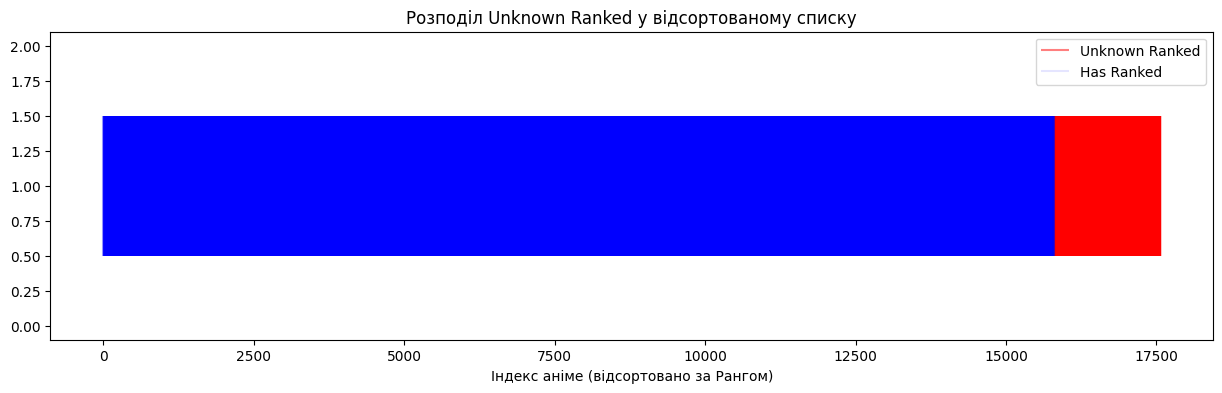

In [27]:
# Створимо копію для візуалізації, відсортовану за рангом
df_sorted = df_anime.copy()
# Для аніме без рангу присвоїмо значення вище максимального, щоб побачити їх в кінці
df_sorted['Ranked_Viz'] = df_sorted['Ranked'].fillna(max_rank + 500)
df_sorted = df_sorted.sort_values('Ranked_Viz').reset_index()

plt.figure(figsize=(15, 4))
# Візуалізуємо наявність рангу як "штрих-код"
plt.eventplot(df_sorted[df_sorted['Ranked'].isnull()].index, color='red', alpha=0.5, label='Unknown Ranked')
plt.eventplot(df_sorted[df_sorted['Ranked'].notnull()].index, color='blue', alpha=0.1, label='Has Ranked')

plt.title('Розподіл Unknown Ranked у відсортованому списку')
plt.xlabel('Індекс аніме (відсортовано за Рангом)')
plt.legend()
plt.show()

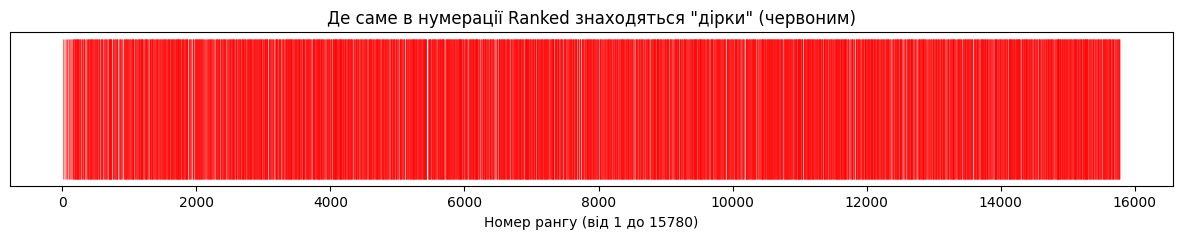

In [28]:
# Створимо список усіх можливих рангів від 1 до Макс
all_possible_ranks = pd.DataFrame({'rank_id': range(1, int(df_anime['Ranked'].max()) + 1)})

# Перевіримо, які з них є в нашому df
all_possible_ranks['exists'] = all_possible_ranks['rank_id'].isin(df_anime['Ranked'])

plt.figure(figsize=(15, 2))
# Малюємо вертикальні лінії тільки там, де ранг ІСНУЄ
plt.vlines(x=all_possible_ranks[all_possible_ranks['exists'] == False]['rank_id'], 
           ymin=0, ymax=1, color='red', alpha=0.5, linewidth=0.5)

plt.title('Де саме в нумерації Ranked знаходяться "дірки" (червоним)')
plt.xlabel('Номер рангу (від 1 до 15780)')
plt.yticks([]) # прибираємо вісь Y
plt.show()

In [29]:
# Рахуємо, скільки разів зустрічається кожен номер рангу
rank_counts = df_anime['Ranked'].value_counts()

# Виводимо ранги, які мають найбільше дублікатів
print("Ранги, які повторюються найчастіше:")
print(rank_counts[rank_counts > 1].head(10))

# Скільки всього аніме мають «не унікальний» ранг?
duplicated_ranks_count = df_anime.duplicated(subset=['Ranked'], keep=False) & df_anime['Ranked'].notnull()
print(f"\nКількість аніме з дубльованими рангами: {duplicated_ranks_count.sum()}")

Ранги, які повторюються найчастіше:
Ranked
5297.0     6
12978.0    6
1804.0     5
5946.0     5
6170.0     5
5919.0     5
6413.0     5
3879.0     5
9132.0     5
11947.0    5
Name: count, dtype: int64

Кількість аніме з дубльованими рангами: 9396


In [30]:
# 1. Беремо лише ті записи, де є і Score, і Ranked
df_check = df_anime.dropna(subset=['Score', 'Ranked']).copy()

# 2. Групуємо за рангом і рахуємо кількість унікальних значень Score
rank_variance = df_check.groupby('Ranked')['Score'].nunique()

# 3. Виводимо ранги, де більше одного унікального Score
multi_score_ranks = rank_variance[rank_variance > 1]

print(f"Кількість рангів з кількома різними оцінками: {len(multi_score_ranks)}")
if len(multi_score_ranks) > 0:
    print("Приклади рангів з різними Score:")
    example_rank = multi_score_ranks.index[0]
    print(df_check[df_check['Ranked'] == example_rank][['Name', 'Score', 'Ranked']])
else:
    print("Гіпотеза підтверджена: Кожен ранг відповідає одному унікальному значенню Score.")

Кількість рангів з кількома різними оцінками: 612
Приклади рангів з різними Score:
                      Name  Score  Ranked
741   Ginga Eiyuu Densetsu   9.07     7.0
6006              Gintama'   9.08     7.0


In [31]:
# 1. Рахуємо різницю між макс і мін Score для кожного рангу
score_diffs = df_check.groupby('Ranked')['Score'].agg(lambda x: x.max() - x.min())

# 2. Фільтруємо лише ті, де є різниця > 0
varying_ranks = score_diffs[score_diffs > 0]

print(f"Статистика розбіжностей Score всередині одного рангу:")
print(varying_ranks.describe())

print(f"\nМаксимальна розбіжність: {varying_ranks.max():.4f}")
print(f"Середня розбіжність: {varying_ranks.mean():.4f}")

# Подивимось на ранг з найбільшою помилкою
max_diff_rank = varying_ranks.idxmax()
print(f"\nНайбільша розбіжність у рангу {max_diff_rank}:")
print(df_check[df_check['Ranked'] == max_diff_rank][['Name', 'Score']])

Статистика розбіжностей Score всередині одного рангу:
count    612.000000
mean       0.027435
std        0.083257
min        0.010000
25%        0.010000
50%        0.010000
75%        0.010000
max        0.970000
Name: Score, dtype: float64

Максимальна розбіжність: 0.9700
Середня розбіжність: 0.0274

Найбільша розбіжність у рангу 11047.0:
              Name  Score
8612   Scrap Diary   3.32
10253         Nami   2.35
10270          001   3.27


In [32]:
# 1. Знаходимо найближчі існуючі ранги до 11047
prev_ranks = df_anime[df_anime['Ranked'] < 11047]['Ranked'].sort_values(ascending=False).unique()[:2]
next_ranks = df_anime[df_anime ['Ranked'] > 11047]['Ranked'].sort_values(ascending=True).unique()[:2]

print(f"Сусіди рангу 11047.0:")
print(f"Попередні: {prev_ranks}")
print(f"Наступні: {next_ranks}")

# 2. Перевіряємо очікуваний наступний ранг
# Ранг 11047 мають 3 аніме, отже наступний має бути 11047 + 3 = 11050
expected_next = 11047 + 3
print(f"\nОчікуваний наступний ранг: {expected_next}")

# 3. Шукаємо аніме БЕЗ рангу, але з оцінками в діапазоні [2.35, 3.32]
candidates = df_anime[df_anime['Ranked'].isna() & df_anime['Score'].between(2.35, 3.32)]
print(f"\nКількість аніме без рангу з оцінкою 2.35-3.32: {len(candidates)}")
if len(candidates) > 0:
    print("Приклади кандидатів:")
    print(candidates[['Name', 'Score', 'Genres']].head(5))

Сусіди рангу 11047.0:
Попередні: [11046. 11045.]
Наступні: [11048. 11049.]

Очікуваний наступний ранг: 11050

Кількість аніме без рангу з оцінкою 2.35-3.32: 0


In [33]:
# Перевірка оцінок сусідів для виявлення розриву (cliff)
neighbors_scores = df_anime[df_anime['Ranked'].isin([11046, 11048])][['Ranked', 'Score']]
print(neighbors_scores.groupby('Ranked')['Score'].mean())

Ranked
11046.0    3.083333
11048.0    3.380000
Name: Score, dtype: float64


In [34]:
# Рахуємо різницю Score для кожного рангу
rank_diffs = df_anime.dropna(subset=['Score', 'Ranked']).groupby('Ranked')['Score'].agg(lambda x: x.max() - x.min())

# Знаходимо аномалії
big_anomalies = rank_diffs[rank_diffs > 0.5]

print(f"Кількість рангів з розбіжністю Score > 0.5: {len(big_anomalies)}")
if len(big_anomalies) > 0:
    print("\nЦі ранги та їх максимальна розбіжність:")
    print(big_anomalies)

Кількість рангів з розбіжністю Score > 0.5: 6

Ці ранги та їх максимальна розбіжність:
Ranked
11016.0    0.62
11026.0    0.65
11028.0    0.66
11041.0    0.84
11046.0    0.62
11047.0    0.97
Name: Score, dtype: float64


In [35]:
# Перевіримо кореляцію (має бути від'ємною: чим більший ранг, тим менша оцінка)
correlation = df_anime['Ranked'].corr(df_anime['Score'])
print(f"Глобальна кореляція Ranked та Score: {correlation:.4f}")

# Подивимось на середні оцінки в різних діапазонах рангів
print("\nСередній Score за діапазонами рангів:")
ranges = [0, 100, 1000, 5000, 10000, 15000, 15780]
print(df_anime.groupby(pd.cut(df_anime['Ranked'], bins=ranges))['Score'].mean())

Глобальна кореляція Ranked та Score: -0.9730

Середній Score за діапазонами рангів:
Ranked
(0, 100]          8.716139
(100, 1000]       8.019356
(1000, 5000]      7.153566
(5000, 10000]     6.120719
(10000, 15000]    4.902439
(15000, 15780]         NaN
Name: Score, dtype: float64


In [36]:
# Перевіримо останній сегмент рангів
tail_check = df_anime[df_anime['Ranked'] > 15000]
print(f"Кількість аніме з рангом > 15000: {len(tail_check)}")
print(f"З них мають відомий Score: {tail_check['Score'].notnull().sum()}")

Кількість аніме з рангом > 15000: 780
З них мають відомий Score: 0


In [37]:
# Перевіримо, чи є хоч якісь голоси у аніме з рангом > 15000
tail_votes_check = df_anime[df_anime['Ranked'] > 15000][[f'Score-{i}' for i in range(1, 11)]]

# Рахуємо, скільки з цих 780 аніме мають хоча б один голос у будь-якій колонці Score-X
have_any_votes = tail_votes_check.notnull().any(axis=1).sum()

print(f"З 780 аніме у 'хвості' мають дані про голоси: {have_any_votes}")

З 780 аніме у 'хвості' мають дані про голоси: 780


In [38]:
# 1. Рахуємо бали для "хвоста" за Методом 2
tail_df = df_anime[df_anime['Ranked'] > 15000].copy()

def get_m2_score(row):
    counts = np.array([row[f'Score-{i}'] for i in range(1, 11)])
    weights = np.arange(1, 11)
    total = np.nansum(counts)
    return np.nansum(counts * weights) / total if total > 0 else np.nan

tail_calculated_scores = tail_df.apply(get_m2_score, axis=1)

print(f"Діапазон розрахованих оцінок для хвоста (>15000): {tail_calculated_scores.min():.2f} — {tail_calculated_scores.max():.2f}")

# 2. Для порівняння: останній відомий сегмент перед хвостом
pre_tail = df_anime[(df_anime['Ranked'] > 14000) & (df_anime['Ranked'] <= 15000)]['Score']
print(f"Діапазон відомих оцінок (Rank 14000-15000): {pre_tail.min():.2f} — {pre_tail.max():.2f}")

Діапазон розрахованих оцінок для хвоста (>15000): 1.67 — 8.61
Діапазон відомих оцінок (Rank 14000-15000): nan — nan


In [39]:
# 1. Знаходимо останній (найбільший) ранг, у якого ще є офіційний Score
last_official_rank = df_anime[df_anime['Score'].notnull()]['Ranked'].max()
print(f"Офіційні оцінки обриваються на ранзі: {last_official_rank}")

# 2. Досліджуємо аномалію 8.61 у хвості
tail_df['Calculated_Score'] = tail_calculated_scores
outlier = tail_df[tail_df['Calculated_Score'] > 8.0].sort_values('Calculated_Score', ascending=False)

print(f"\nАніме з високим балом, але низьким рангом (>15000):")
# Подивимось на назву та сумарну кількість голосів
score_cols = [f'Score-{i}' for i in range(1, 11)]
outlier['Total_Votes'] = outlier[score_cols].sum(axis=1)
print(outlier[['Name', 'Calculated_Score', 'Ranked', 'Total_Votes']].head(5))

Офіційні оцінки обриваються на ранзі: 11074.0

Аніме з високим балом, але низьким рангом (>15000):
                                                    Name  Calculated_Score  \
9462                                            Kokoroya          8.610063   
7695                                      Mr. Pen Pen II          8.407186   
10460  Mahou no Princess Minky Momo: Yume wo Dakishim...          8.395722   
7694                                         Mr. Pen Pen          8.301775   
16624                                     Kimi wa Kanata          8.226190   

        Ranked  Total_Votes  
9462   15119.0        159.0  
7695   15687.0        167.0  
10460  15369.0        187.0  
7694   15686.0        169.0  
16624  15012.0         84.0  


In [40]:
# Порівняємо наш розрахунок (M2) з офіційним Score у безпечній зоні
df_safe = df_anime[df_anime['Ranked'] < 11074].dropna(subset=['Score']).copy()

# Рахуємо наш бал для них
df_safe['M2_Score'] = df_safe.apply(lambda row: 
    np.nansum(np.array([row[f'Score-{i}'] for i in range(1, 11)]) * np.arange(1, 11)) / 
    np.nansum([row[f'Score-{i}'] for i in range(1, 11)]) if np.nansum([row[f'Score-{i}'] for i in range(1, 11)]) > 0 else np.nan
, axis=1)

# Рахуємо різницю
df_safe['Diff'] = (df_safe['Score'] - df_safe['M2_Score']).abs()
print(f"Середня розбіжність між M2 та офіційним балом: {df_safe['Diff'].mean():.4f}")
print(f"Максимальна розбіжність: {df_safe['Diff'].max():.4f}")

Середня розбіжність між M2 та офіційним балом: 0.1209
Максимальна розбіжність: 2.3860


In [41]:
# Знаходимо аніме з максимальною розбіжністю
anomaly_238 = df_safe[df_safe['Diff'] > 2.0].sort_values('Diff', ascending=False)
print("Записи з максимальною розбіжністю (M2 vs Official):")
print(anomaly_238[['Name', 'Score', 'M2_Score', 'Diff', 'Ranked']].head(5))

# Додамо перевірку кількості голосів для цих аномалій
score_cols = [f'Score-{i}' for i in range(1, 11)]
anomaly_238['Total_Votes'] = anomaly_238[score_cols].sum(axis=1)
print("\nКількість голосів для цих аномалій:")
print(anomaly_238[['Name', 'Total_Votes']])

Записи з максимальною розбіжністю (M2 vs Official):
                  Name  Score  M2_Score      Diff   Ranked
5187       Super Child   4.89  2.503984  2.386016  10699.0
8615   Goldfish Fetish   5.45  3.081545  2.368455   9817.0
15264        I Like It   4.76  2.740947  2.019053  10795.0

Кількість голосів для цих аномалій:
                  Name  Total_Votes
5187       Super Child        502.0
8615   Goldfish Fetish        233.0
15264        I Like It        359.0


In [42]:
# Беремо хвіст, де немає офіційного Score
df_tail = df_anime[df_anime['Ranked'] > 11074].copy()

# Рахуємо для них M2
df_tail['M2_Score'] = df_tail.apply(lambda row: 
    np.nansum(np.array([row[f'Score-{i}'] for i in range(1, 11)]) * np.arange(1, 11)) / 
    np.nansum([row[f'Score-{i}'] for i in range(1, 11)]) if np.nansum([row[f'Score-{i}'] for i in range(1, 11)]) > 0 else np.nan
, axis=1)

# Перевіряємо кореляцію Ranked та M2_Score у цьому хвості
tail_corr = df_tail['Ranked'].corr(df_tail['M2_Score'])
print(f"Кореляція у хвості (Rank > 11074): {tail_corr:.4f}")

Кореляція у хвості (Rank > 11074): -0.0022


In [43]:
# Перевіримо, що керує рангом у хвості
tail_analysis = df_anime[df_anime['Ranked'] > 11074].copy()

# Кореляція з популярністю (числом учасників) та ID
corr_pop = tail_analysis['Ranked'].corr(tail_analysis['Popularity'])
corr_id = tail_analysis['Ranked'].corr(tail_analysis['MAL_ID'])

print(f"Кореляція Ranked з Popularity у хвості: {corr_pop:.4f}")
print(f"Кореляція Ranked з MAL_ID у хвості: {corr_id:.4f}")

Кореляція Ranked з Popularity у хвості: 0.0151
Кореляція Ranked з MAL_ID у хвості: 0.0130


Топ-3 найвищі (найменше число) ранги БЕЗ Score:
                                        Name   Ranked  Score
16761  Koukaku Kidoutai: SAC_2045 2nd Season      0.0    NaN
17548                The Sun, Moon and Stars      0.0    NaN
10759                                 Nanoha  11044.0    NaN
------------------------------------------------------------
Топ-3 найвищі оцінки БЕЗ Ranked:
                                             Name  Score  Ranked
15573                  Master Piece The Animation   7.76     NaN
10065                          Mankitsu Happening   7.72     NaN
9320   Rance 01: Hikari wo Motomete The Animation   7.64     NaN
------------------------------------------------------------
Кількість пропусків у нових колонках до та після очищення:
Popularity     0
Members        0
Favorites      0
Total_Votes    0
dtype: int64
------------------------------------------------------------
Матриця кореляції:
                Score    Ranked  Popularity   Members  Favorites  Total_V

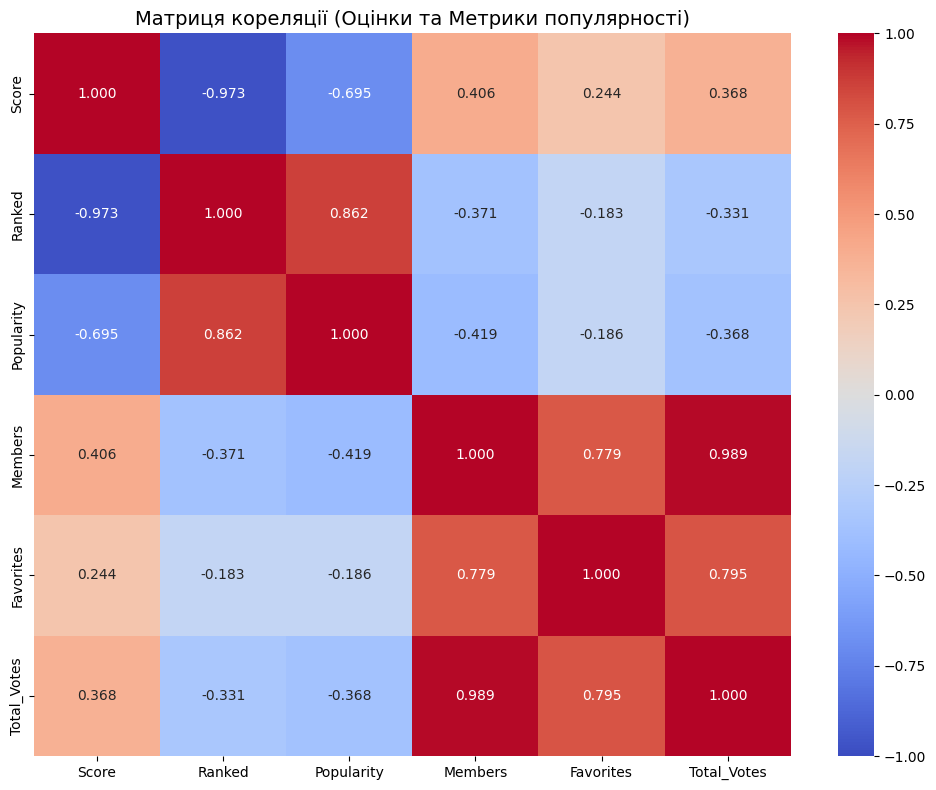


Медіанні значення метрик залежно від наявності Score:
              Popularity  Members  Favorites  Total_Votes
Score_is_NaN                                             
False             6347.0   5279.0       10.0       1975.0
True             14933.0    198.0        0.0         42.0

Медіанні значення метрик залежно від наявності Ranked:
               Popularity  Members  Favorites  Total_Votes
Ranked_is_NaN                                             
False              9195.0   1737.0        2.0        571.0
True               7370.5   3615.0       11.0        918.5


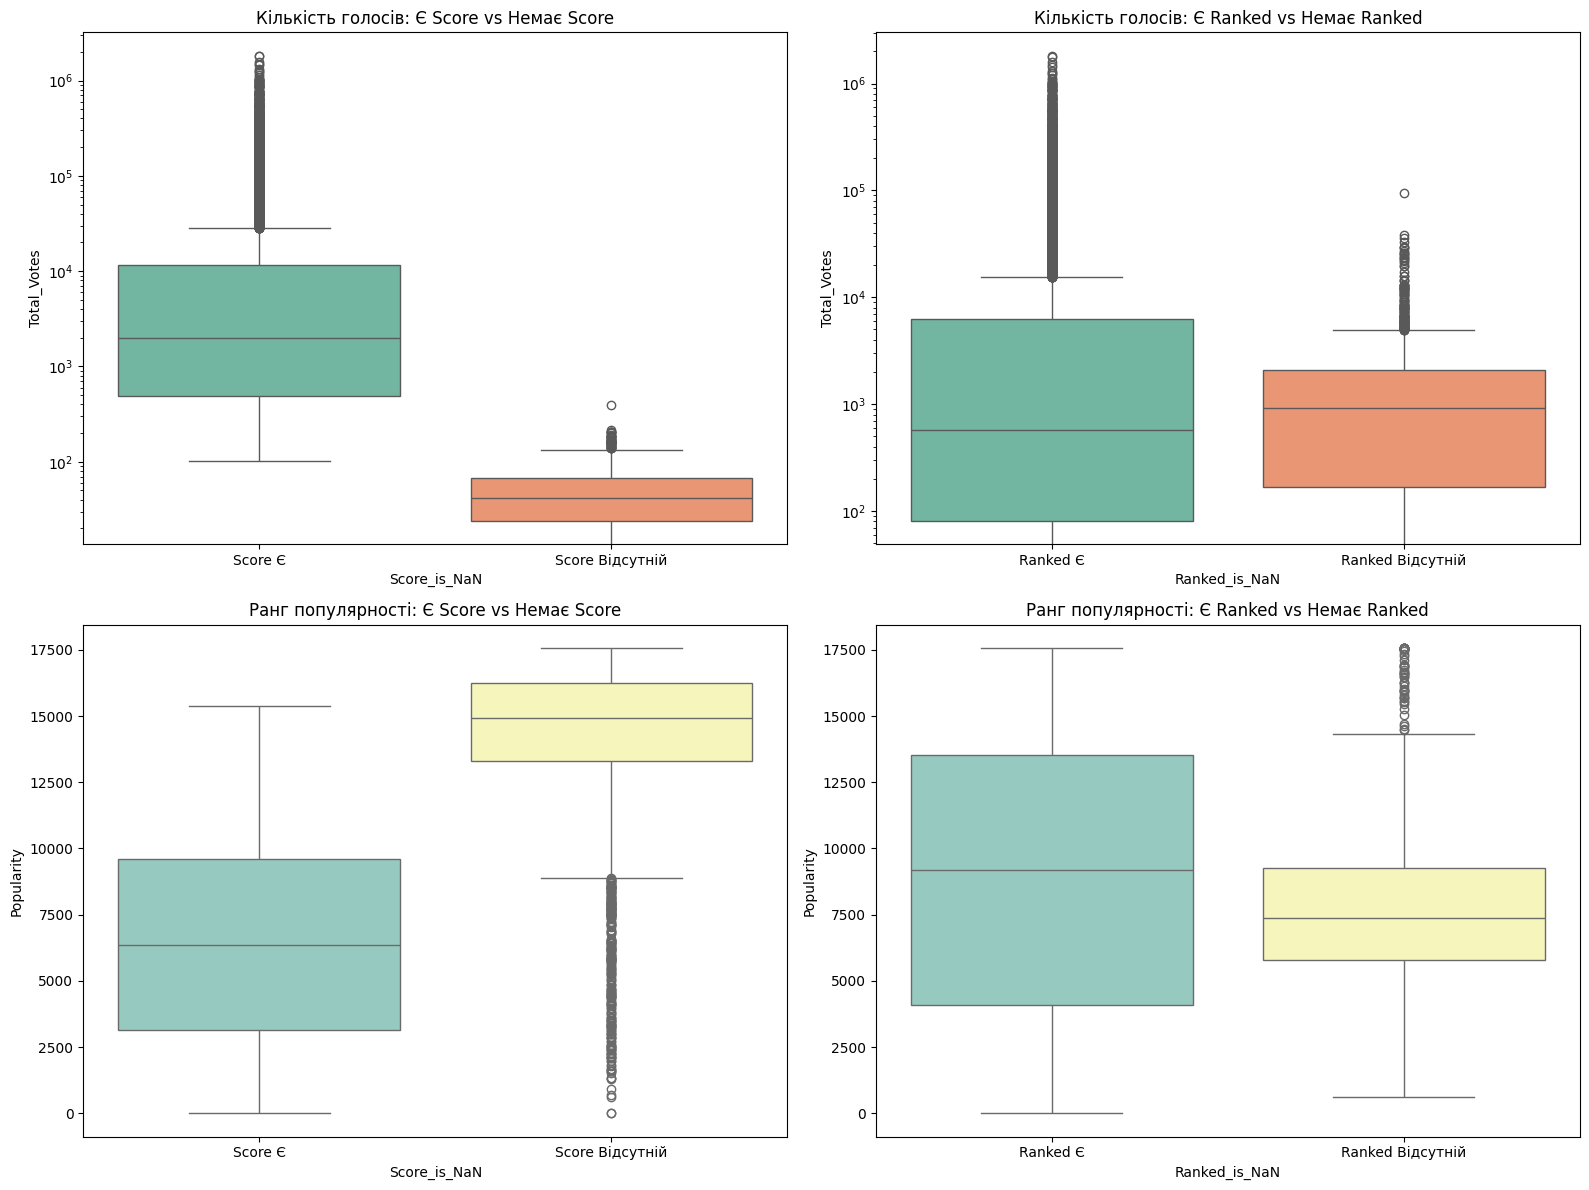

In [44]:
# 1. Топ-3 найменші ранги (ближчі до 1) без Score
top_3_min_ranked = df_anime[df_anime['Score'].isna() & df_anime['Ranked'].notna()].nsmallest(3, 'Ranked')
print("Топ-3 найвищі (найменше число) ранги БЕЗ Score:")
print(top_3_min_ranked[['Name', 'Ranked', 'Score']])
print("-" * 60)

# 2. Топ-3 найбільші Score без Ranked
top_3_max_score = df_anime[df_anime['Ranked'].isna() & df_anime['Score'].notna()].nlargest(3, 'Score')
print("Топ-3 найвищі оцінки БЕЗ Ranked:")
print(top_3_max_score[['Name', 'Score', 'Ranked']])
print("-" * 60)

# 3. Перевірка та очищення нових колонок
cols_to_clean = ['Popularity', 'Members', 'Favorites']
for col in cols_to_clean:
    # Перетворюємо на числа, ігноруючи текст на кшталт 'Unknown'
    df_anime[col] = pd.to_numeric(df_anime[col].astype(str).str.replace('Unknown', 'nan'), errors='coerce')

# Підрахунок загальної кількості голосів (Total_Votes)
score_cols = [f'Score-{i}' for i in range(1, 11)]
for col in score_cols:
    df_anime[col] = pd.to_numeric(df_anime[col].astype(str).str.replace('Unknown', 'nan'), errors='coerce')

# Додаємо нову колонку з сумою всіх голосів
df_anime['Total_Votes'] = df_anime[score_cols].sum(axis=1)

print("Кількість пропусків у нових колонках до та після очищення:")
print(df_anime[['Popularity', 'Members', 'Favorites', 'Total_Votes']].isna().sum())
print("-" * 60)

# 4. Кореляційна матриця (включаємо всі числові метрики)
corr_cols = ['Score', 'Ranked', 'Popularity', 'Members', 'Favorites', 'Total_Votes']
corr_matrix = df_anime[corr_cols].corr()
print("Матриця кореляції:")
print(corr_matrix)

# 5. ВІЗУАЛІЗАЦІЯ 1: Матриця кореляції
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, center=0)
plt.title('Матриця кореляції (Оцінки та Метрики популярності)', fontsize=14)
plt.tight_layout()
plt.show()

# 6. Дослідження зв'язку відсутності Score/Ranked від цих метрик
df_anime['Score_is_NaN'] = df_anime['Score'].isna()
df_anime['Ranked_is_NaN'] = df_anime['Ranked'].isna()

print("\nМедіанні значення метрик залежно від наявності Score:")
# Використовуємо медіану, бо середнє арифметичне (mean) дуже чутливе до аномалій (як-от 1 млн Members)
print(df_anime.groupby('Score_is_NaN')[['Popularity', 'Members', 'Favorites', 'Total_Votes']].median())

print("\nМедіанні значення метрик залежно від наявності Ranked:")
print(df_anime.groupby('Ranked_is_NaN')[['Popularity', 'Members', 'Favorites', 'Total_Votes']].median())

# 7. ВІЗУАЛІЗАЦІЯ 2: Вплив параметрів на відсутність даних (Виправлений код)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Вплив кількості голосів
sns.boxplot(data=df_anime, x='Score_is_NaN', y='Total_Votes', ax=axes[0, 0], 
            hue='Score_is_NaN', palette='Set2', legend=False)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Кількість голосів: Є Score vs Немає Score')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Score Є', 'Score Відсутній'])

sns.boxplot(data=df_anime, x='Ranked_is_NaN', y='Total_Votes', ax=axes[0, 1], 
            hue='Ranked_is_NaN', palette='Set2', legend=False)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Кількість голосів: Є Ranked vs Немає Ranked')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Ranked Є', 'Ranked Відсутній'])

# Вплив популярності
sns.boxplot(data=df_anime, x='Score_is_NaN', y='Popularity', ax=axes[1, 0], 
            hue='Score_is_NaN', palette='Set3', legend=False)
axes[1, 0].set_title('Ранг популярності: Є Score vs Немає Score')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Score Є', 'Score Відсутній'])

sns.boxplot(data=df_anime, x='Ranked_is_NaN', y='Popularity', ax=axes[1, 1], 
            hue='Ranked_is_NaN', palette='Set3', legend=False)
axes[1, 1].set_title('Ранг популярності: Є Ranked vs Немає Ranked')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Ranked Є', 'Ranked Відсутній'])

plt.tight_layout()
plt.show()

In [45]:
# 1. Замінюємо 0.0 на NaN у колонці Ranked
df_anime['Ranked'] = df_anime['Ranked'].replace(0.0, np.nan)
print(f"Залишилось рангів зі значенням 0.0: {(df_anime['Ranked'] == 0.0).sum()}")
print("-" * 50)

# 2. Дослідження неперервності та повноти Popularity
pop_clean = df_anime['Popularity'].dropna().astype(int)

max_pop = pop_clean.max()
min_pop = pop_clean.min()
total_with_pop = len(pop_clean)
total_missing_pop = df_anime['Popularity'].isna().sum()

# Перевірка на дублікати (чи є аніме з однаковим місцем популярності)
pop_counts = pop_clean.value_counts()
duplicated_pops = pop_counts[pop_counts > 1]

# Перевірка на "дірки" (пропущені номери)
full_pop_range = set(range(1, max_pop + 1))
existing_pop = set(pop_clean)
missing_pop = full_pop_range - existing_pop

print("--- АНАЛІЗ POPULARITY ---")
print(f"Діапазон місць: від {min_pop} до {max_pop}")
print(f"Аніме з відомим Popularity: {total_with_pop}")
print(f"Аніме без Popularity (NaN): {total_missing_pop}")
print(f"Кількість місць, які ділять кілька аніме (дублікати): {len(duplicated_pops)}")
print(f"Кількість 'дірок' (пропущених номерів): {len(missing_pop)}")

if len(missing_pop) > 0:
    print(f"Перші 10 пропущених номерів Popularity: {sorted(list(missing_pop))[:10]}")
    
if len(duplicated_pops) > 0:
    print(f"\nПриклади місць Popularity з найбільшою кількістю дублікатів:")
    print(duplicated_pops.head(5))

Залишилось рангів зі значенням 0.0: 0
--------------------------------------------------
--- АНАЛІЗ POPULARITY ---
Діапазон місць: від 0 до 17565
Аніме з відомим Popularity: 17562
Аніме без Popularity (NaN): 0
Кількість місць, які ділять кілька аніме (дублікати): 4543
Кількість 'дірок' (пропущених номерів): 5811
Перші 10 пропущених номерів Popularity: [14, 20, 26, 30, 38, 44, 47, 56, 73, 76]

Приклади місць Popularity з найбільшою кількістю дублікатів:
Popularity
4161     6
11039    6
3240     5
6575     5
7944     5
Name: count, dtype: int64


In [46]:
# Загальна кількість Rx - Hentai
hentai_anime = df_anime[df_anime['Rating'] == 'Rx - Hentai']
total_hentai = len(hentai_anime)

# Скільки Rx - Hentai мають пропущений Ranked
hentai_without_rank = hentai_anime['Ranked'].isna().sum()
hentai_with_rank = total_hentai - hentai_without_rank

# Загальна кількість пропущених Ranked у всьому датасеті
nan_ranked_anime = df_anime[df_anime['Ranked'].isna()]
total_nan_ranked = len(nan_ranked_anime)

# Хто ще має пропущений Ranked, крім Hentai?
nan_ranked_not_hentai = nan_ranked_anime[nan_ranked_anime['Rating'] != 'Rx - Hentai']

print(f"--- АНАЛІЗ 'Rx - Hentai' ТА RANKED ---")
print(f"Всього аніме з рейтингом 'Rx - Hentai': {total_hentai}")
print(f"З них НЕ мають Ranked (NaN): {hentai_without_rank} ({(hentai_without_rank/total_hentai*100) if total_hentai else 0:.1f}%)")
print(f"З них МАЮТЬ Ranked: {hentai_with_rank}")
print("-" * 40)
print(f"Всього аніме БЕЗ Ranked (NaN): {total_nan_ranked}")
print(f"З них є 'Rx - Hentai': {hentai_without_rank} ({(hentai_without_rank/total_nan_ranked*100) if total_nan_ranked else 0:.1f}%)")
print(f"З них НЕ 'Rx - Hentai': {len(nan_ranked_not_hentai)}")

if len(nan_ranked_not_hentai) > 0:
    print("\nЯкі ще рейтинги (Rating) зустрічаються серед аніме БЕЗ Ranked?")
    print(nan_ranked_not_hentai['Rating'].value_counts())

--- АНАЛІЗ 'Rx - Hentai' ТА RANKED ---
Всього аніме з рейтингом 'Rx - Hentai': 1345
З них НЕ мають Ranked (NaN): 1345 (100.0%)
З них МАЮТЬ Ranked: 0
----------------------------------------
Всього аніме БЕЗ Ranked (NaN): 1764
З них є 'Rx - Hentai': 1345 (76.2%)
З них НЕ 'Rx - Hentai': 419

Які ще рейтинги (Rating) зустрічаються серед аніме БЕЗ Ranked?
Rating
Unknown                           243
PG-13 - Teens 13 or older          98
R+ - Mild Nudity                   33
R - 17+ (violence & profanity)     21
PG - Children                      13
G - All Ages                       11
Name: count, dtype: int64


Шукаємо оптимальну формулу... Зачекайте кілька секунд.

--- РЕЗУЛЬТАТИ ТЕСТУВАННЯ БАЙЄСОВОЇ ФОРМУЛИ ---
Оптимальний поріг голосів (m): 71.27
Середній бал по базі (C): 6.51
--------------------------------------------------
Метод 2 (Сире середнє M2):
Середня похибка (MAE): 0.1205
Максимальна похибка: 2.3860
--------------------------------------------------
Байєсове середнє (MAL Formula):
Середня похибка (MAE): 0.0691
Максимальна похибка: 1.8880


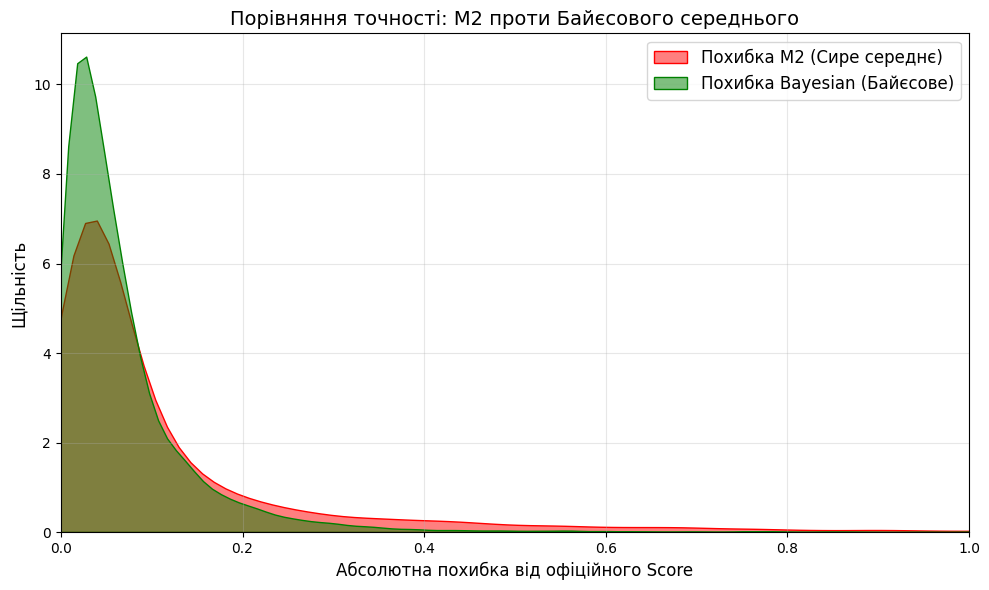

In [47]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

# Беремо лише ті рядки, де є офіційний Score
df_valid = df_anime.dropna(subset=['Score']).copy()

# C - середній бал по всій базі
C = df_valid['Score'].mean()

# Рахуємо v (Total_Votes) та S (M2_Score), якщо вони ще не пораховані
if 'Total_Votes' not in df_valid.columns:
    score_cols = [f'Score-{i}' for i in range(1, 11)]
    for col in score_cols:
        df_valid[col] = pd.to_numeric(df_valid[col].astype(str).str.replace('Unknown', 'nan'), errors='coerce')
    df_valid['Total_Votes'] = df_valid[score_cols].sum(axis=1)

def calc_m2(row):
    counts = np.array([row[f'Score-{i}'] for i in range(1, 11)])
    weights = np.arange(1, 11)
    total = np.nansum(counts)
    if total > 0:
        return np.nansum(counts * weights) / total
    return np.nan

if 'M2_Score' not in df_valid.columns:
    df_valid['M2_Score'] = df_valid.apply(calc_m2, axis=1)

# Відкидаємо рядки, де голосів немає (M2_Score is NaN)
df_valid = df_valid.dropna(subset=['M2_Score', 'Score'])

# Функція для оптимізації m (шукаємо мінімальну похибку MAE)
def objective(m_val):
    m = m_val[0]
    # Байєсова формула: (v * S + m * C) / (v + m)
    preds = (df_valid['Total_Votes'] * df_valid['M2_Score'] + m * C) / (df_valid['Total_Votes'] + m)
    mae = np.mean(np.abs(df_valid['Score'] - preds))
    return mae

# Запускаємо оптимізатор
print("Шукаємо оптимальну формулу... Зачекайте кілька секунд.")
res = minimize(objective, x0=[50], bounds=[(0, 10000)])
optimal_m = res.x[0]

# Рахуємо фінальні бали за Байєсовою формулою з оптимальним m
df_valid['Bayesian_Score'] = (df_valid['Total_Votes'] * df_valid['M2_Score'] + optimal_m * C) / (df_valid['Total_Votes'] + optimal_m)

# Розрахунок похибок
df_valid['Error_M2'] = np.abs(df_valid['Score'] - df_valid['M2_Score'])
df_valid['Error_Bayes'] = np.abs(df_valid['Score'] - df_valid['Bayesian_Score'])

mae_m2 = df_valid['Error_M2'].mean()
max_m2 = df_valid['Error_M2'].max()

mae_bayes = df_valid['Error_Bayes'].mean()
max_bayes = df_valid['Error_Bayes'].max()

print(f"\n--- РЕЗУЛЬТАТИ ТЕСТУВАННЯ БАЙЄСОВОЇ ФОРМУЛИ ---")
print(f"Оптимальний поріг голосів (m): {optimal_m:.2f}")
print(f"Середній бал по базі (C): {C:.2f}")
print("-" * 50)
print("Метод 2 (Сире середнє M2):")
print(f"Середня похибка (MAE): {mae_m2:.4f}")
print(f"Максимальна похибка: {max_m2:.4f}")
print("-" * 50)
print("Байєсове середнє (MAL Formula):")
print(f"Середня похибка (MAE): {mae_bayes:.4f}")
print(f"Максимальна похибка: {max_bayes:.4f}")

# Створимо графік розподілу похибок
plt.figure(figsize=(10, 6))
sns.kdeplot(df_valid['Error_M2'], label='Похибка M2 (Сире середнє)', fill=True, color='red', alpha=0.5)
sns.kdeplot(df_valid['Error_Bayes'], label='Похибка Bayesian (Байєсове)', fill=True, color='green', alpha=0.5)
plt.title('Порівняння точності: M2 проти Байєсового середнього', fontsize=14)
plt.xlabel('Абсолютна похибка від офіційного Score', fontsize=12)
plt.ylabel('Щільність', fontsize=12)
plt.legend(fontsize=12)
plt.xlim(0, 1)  # Обмежуємо до 1 бала для наочності
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

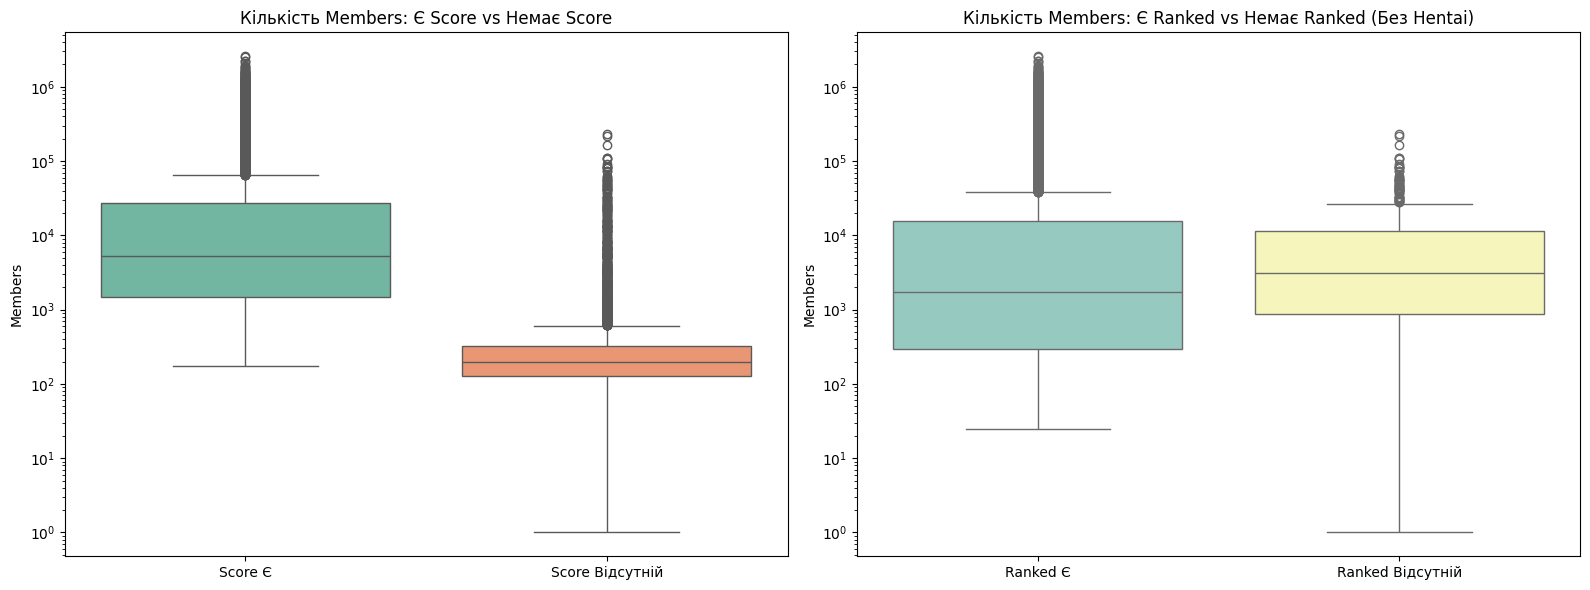

--- АНАЛІЗ ПОРОГУ MEMBERS ---
Найменша кількість Members, при якій аніме має офіційний Score: 172
Кількість аніме БЕЗ Score, але з Members > 172: 2993

Топ-5 аніме без Score з найбільшою кількістю Members:
                                                    Name  Members  \
16719                   Boku no Hero Academia 5th Season   231671   
16108               Tate no Yuusha no Nariagari Season 2   219840   
3280              Evangelion: 3.0+1.0 Thrice Upon a Time   162841   
17272  Kaguya-sama wa Kokurasetai: Tensai-tachi no Re...   111055   
16109               Tate no Yuusha no Nariagari Season 3   108628   

                               Rating  
16719       PG-13 - Teens 13 or older  
16108       PG-13 - Teens 13 or older  
3280   R - 17+ (violence & profanity)  
17272       PG-13 - Teens 13 or older  
16109       PG-13 - Teens 13 or older  


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Переконаємось, що колонки існують і мають правильний тип
df_anime['Score_is_NaN'] = df_anime['Score'].isna()
df_anime['Ranked_is_NaN'] = df_anime['Ranked'].isna()

# 1. ВІЗУАЛІЗАЦІЯ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Фільтруємо Hentai для аналізу Ranked
df_no_hentai = df_anime[df_anime['Rating'] != 'Rx - Hentai'].copy()

# Графік 1: Вплив Members на Score (Всі дані)
sns.boxplot(data=df_anime, x='Score_is_NaN', y='Members', ax=axes[0], 
            hue='Score_is_NaN', palette='Set2', legend=False)
axes[0].set_yscale('log')
axes[0].set_title('Кількість Members: Є Score vs Немає Score')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Score Є', 'Score Відсутній'])
axes[0].set_xlabel('')

# Графік 2: Вплив Members на Ranked (БЕЗ Hentai)
sns.boxplot(data=df_no_hentai, x='Ranked_is_NaN', y='Members', ax=axes[1], 
            hue='Ranked_is_NaN', palette='Set3', legend=False)
axes[1].set_yscale('log')
axes[1].set_title('Кількість Members: Є Ranked vs Немає Ranked (Без Hentai)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Ranked Є', 'Ranked Відсутній'])
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

# 2. АНАЛІЗ МІНІМАЛЬНИХ MEMBERS
# Знаходимо найменшу кількість Members серед аніме, які мають Score
min_members_with_score = df_anime[df_anime['Score'].notna()]['Members'].min()

print(f"--- АНАЛІЗ ПОРОГУ MEMBERS ---")
print(f"Найменша кількість Members, при якій аніме має офіційний Score: {min_members_with_score}")

# Знаходимо аніме, у яких НЕМАЄ Score, але Members більше за цей мінімум
anomalies_no_score = df_anime[(df_anime['Score'].isna()) & (df_anime['Members'] > min_members_with_score)]
count_anomalies = len(anomalies_no_score)

print(f"Кількість аніме БЕЗ Score, але з Members > {min_members_with_score}: {count_anomalies}")

if count_anomalies > 0:
    print("\nТоп-5 аніме без Score з найбільшою кількістю Members:")
    print(anomalies_no_score[['Name', 'Members', 'Rating']].sort_values(by='Members', ascending=False).head(5))

In [49]:
# Знаходимо найменшу кількість Total_Votes серед аніме, які мають офіційний Score
min_votes_with_score = df_anime[df_anime['Score'].notna()]['Total_Votes'].min()

print(f"--- АНАЛІЗ ПОРОГУ TOTAL_VOTES ---")
print(f"Найменша кількість Total_Votes, при якій аніме має офіційний Score: {min_votes_with_score}")

# Знаходимо аніме, у яких НЕМАЄ Score, але Total_Votes більше за цей мінімум
anomalies_no_score_votes = df_anime[(df_anime['Score'].isna()) & (df_anime['Total_Votes'] > min_votes_with_score)]
count_anomalies_votes = len(anomalies_no_score_votes)

print(f"Кількість аніме БЕЗ Score, але з Total_Votes > {min_votes_with_score}: {count_anomalies_votes}")

if count_anomalies_votes > 0:
    print("\nТоп-5 аніме без Score з найбільшою кількістю Total_Votes:")
    print(anomalies_no_score_votes[['Name', 'Total_Votes', 'Rating', 'Members']].sort_values(by='Total_Votes', ascending=False).head(5))

--- АНАЛІЗ ПОРОГУ TOTAL_VOTES ---
Найменша кількість Total_Votes, при якій аніме має офіційний Score: 101.0
Кількість аніме БЕЗ Score, але з Total_Votes > 101.0: 231

Топ-5 аніме без Score з найбільшою кількістю Total_Votes:
                                       Name  Total_Votes  \
17158  Muteki-kyuu*Believer / Mirai Harmony        394.0   
8108       Milk House Dreaming: Ai no Shiki        214.0   
12877      Warau Salesman Tokubetsu Bangumi        206.0   
5449                         YanYan Machiko        205.0   
9321      Gensei Shugoshin P-hyoro Ikka OVA        204.0   

                          Rating  Members  
17158  PG-13 - Teens 13 or older     1144  
8108                G - All Ages      482  
12877  PG-13 - Teens 13 or older      635  
5449                G - All Ages      543  
9321   PG-13 - Teens 13 or older      505  


--- АНАЛІЗ КОНКУРЕНТНОГО РАНЖУВАННЯ ---
Загальна кількість дірок: 2528
Загальна кількість нахлестів: 2852

Топ-10 найбільших НАХЛЕСТІВ (наступний ранг з'явився зарано):
 Current_Rank  Actual_Next  Expected_Next  Overlap_Size
         3879         3880           3884             4
         5297         5299           5303             4
        14687        14688          14692             4
         1804         1805           1809             4
         9501         9502           9506             4
        12978        12980          12984             4
        11558        11559          11563             4
         9132         9133           9137             4
        15327        15328          15331             3
        15285        15286          15289             3

Топ-10 найбільших ДІРОК (пропущені легітимні місця):
 Current_Rank  Actual_Next  Expected_Next  Hole_Size
        10430        10438          10431          7
         4137         4144           4138          6
  

C:\Users\Anton\AppData\Local\Temp\ipykernel_12404\1864181439.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(abs(int(tick))) for tick in ticks])


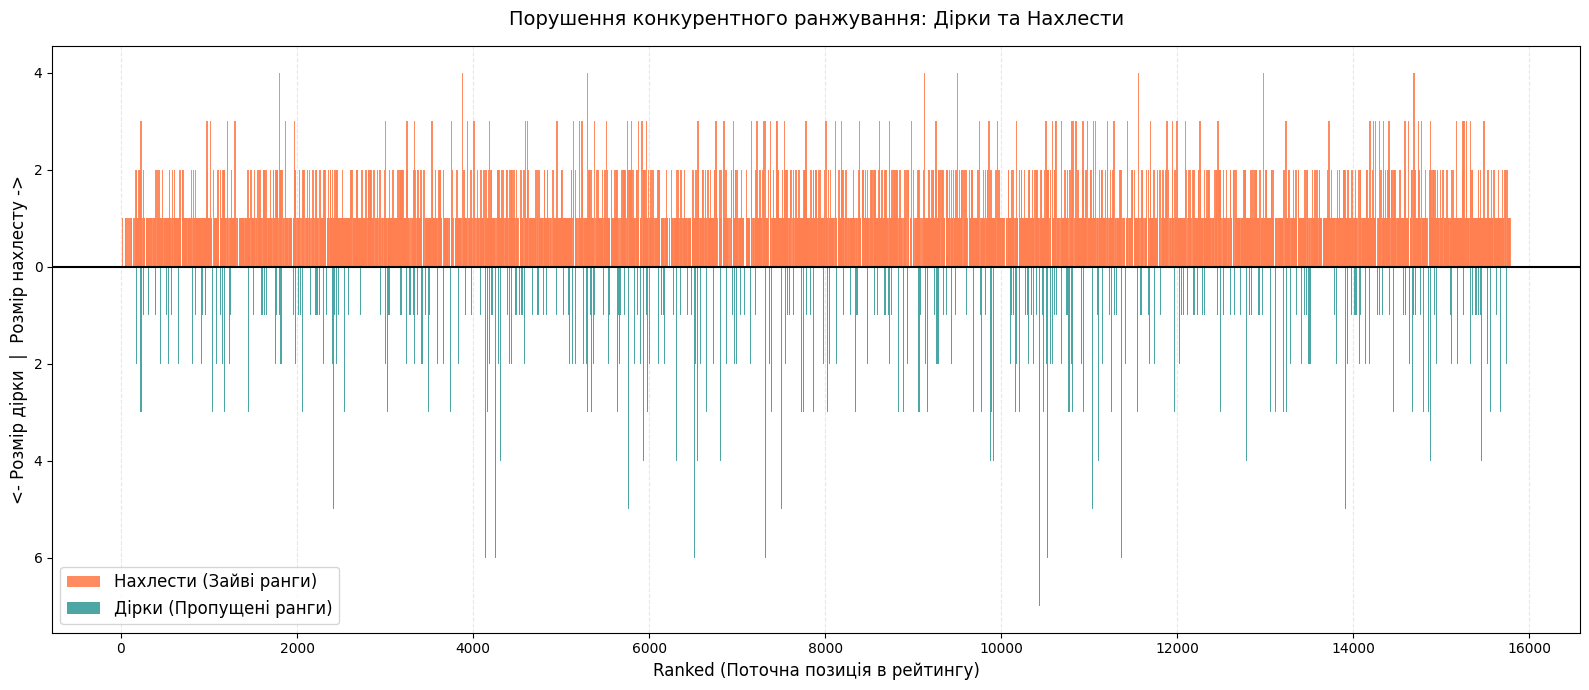

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Підготовка даних
ranked_clean = df_anime['Ranked'].dropna().astype(int)
# Рахуємо скільки разів зустрічається кожен ранг і сортуємо за зростанням
rank_counts = ranked_clean.value_counts().sort_index()

ranks = rank_counts.index.values
counts = rank_counts.values

holes = []
overlaps = []

# 2. Проходимо по рейтингу і перевіряємо логіку конкурентного ранжування
for i in range(len(ranks) - 1):
    current_rank = ranks[i]
    current_count = counts[i]
    actual_next = ranks[i+1]
    
    # За вашою логікою: поточний ранг + кількість аніме на ньому
    expected_next = current_rank + current_count
    
    diff = actual_next - expected_next
    
    if diff > 0:
        # Наступний ранг більший за очікуваний -> Дірка
        holes.append({
            'Current_Rank': current_rank,
            'Actual_Next': actual_next,
            'Expected_Next': expected_next,
            'Hole_Size': diff
        })
    elif diff < 0:
        # Наступний ранг менший за очікуваний -> Нахлест
        overlaps.append({
            'Current_Rank': current_rank,
            'Actual_Next': actual_next,
            'Expected_Next': expected_next,
            'Overlap_Size': abs(diff)
        })

holes_df = pd.DataFrame(holes)
overlaps_df = pd.DataFrame(overlaps)

# 3. Вивід результатів
print("--- АНАЛІЗ КОНКУРЕНТНОГО РАНЖУВАННЯ ---")
print(f"Загальна кількість дірок: {len(holes_df)}")
print(f"Загальна кількість нахлестів: {len(overlaps_df)}\n")

if not overlaps_df.empty:
    print("Топ-10 найбільших НАХЛЕСТІВ (наступний ранг з'явився зарано):")
    top_overlaps = overlaps_df.sort_values('Overlap_Size', ascending=False)
    print(top_overlaps.head(10).to_string(index=False))
else:
    print("Нахлестів не виявлено.")

print("\nТоп-10 найбільших ДІРОК (пропущені легітимні місця):")
if not holes_df.empty:
    top_holes = holes_df.sort_values('Hole_Size', ascending=False)
    print(top_holes.head(10).to_string(index=False))
else:
    print("Дірок не виявлено.")

# 4. ВІЗУАЛІЗАЦІЯ
fig, ax = plt.subplots(figsize=(16, 7))

# Малюємо нахлести (спрямовані вгору, помаранчеві)
if not overlaps_df.empty:
    ax.bar(overlaps_df['Current_Rank'], overlaps_df['Overlap_Size'], 
           color='coral', width=15, alpha=0.9, 
           label='Нахлести (Зайві ранги)')

# Малюємо дірки (спрямовані вниз, бірюзові)
# Ширина відповідає розміру дірки для наочності
if not holes_df.empty:
    ax.bar(holes_df['Current_Rank'], -holes_df['Hole_Size'], 
           width=holes_df['Hole_Size'], align='edge', 
           color='teal', alpha=0.7, 
           label='Дірки (Пропущені ранги)')

# Лінія ідеального рейтингу
ax.axhline(0, color='black', linewidth=1.5)

ax.set_title('Порушення конкурентного ранжування: Дірки та Нахлести', fontsize=14, pad=15)
ax.set_xlabel('Ranked (Поточна позиція в рейтингу)', fontsize=12)
ax.set_ylabel('<- Розмір дірки  |  Розмір нахлесту ->', fontsize=12)

# Прибираємо мінуси з вісі Y для краси
ticks = ax.get_yticks()
ax.set_yticklabels([str(abs(int(tick))) for tick in ticks])

ax.legend(fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [51]:
import pandas as pd
import numpy as np

# 1. Підготовка даних (Беремо Popularity, відкидаємо можливі пропуски та переводимо в int)
# Також пам'ятаємо, що там був дивний 0, але ми просто перевіряємо кроки, тому беремо як є
pop_clean = df_anime['Popularity'].dropna().astype(int)

# Рахуємо скільки разів зустрічається кожне місце популярності
pop_counts = pop_clean.value_counts().sort_index()

ranks = pop_counts.index.values
counts = pop_counts.values

holes = []
overlaps = []

# 2. Перевірка конкурентного ранжування для Popularity
for i in range(len(ranks) - 1):
    current_rank = ranks[i]
    current_count = counts[i]
    actual_next = ranks[i+1]
    
    # Очікуване наступне місце = поточне місце + кількість аніме на цьому місці
    expected_next = current_rank + current_count
    
    diff = actual_next - expected_next
    
    if diff > 0:
        holes.append({
            'Current_Pop': current_rank,
            'Actual_Next': actual_next,
            'Expected_Next': expected_next,
            'Hole_Size': diff
        })
    elif diff < 0:
        overlaps.append({
            'Current_Pop': current_rank,
            'Actual_Next': actual_next,
            'Expected_Next': expected_next,
            'Overlap_Size': abs(diff)
        })

holes_df = pd.DataFrame(holes)
overlaps_df = pd.DataFrame(overlaps)

# 3. Вивід результатів
print("--- АНАЛІЗ КОНКУРЕНТНОГО РАНЖУВАННЯ (POPULARITY) ---")
print(f"Загальна кількість дірок: {len(holes_df)}")
print(f"Загальна кількість нахлестів: {len(overlaps_df)}\n")

if not overlaps_df.empty:
    print("Топ-10 найбільших НАХЛЕСТІВ (наступне місце з'явилося зарано):")
    top_overlaps = overlaps_df.sort_values('Overlap_Size', ascending=False)
    print(top_overlaps.head(10).to_string(index=False))
else:
    print("Нахлестів не виявлено.")

print("\nТоп-10 найбільших ДІРОК (пропущені легітимні місця):")
if not holes_df.empty:
    top_holes = holes_df.sort_values('Hole_Size', ascending=False)
    print(top_holes.head(10).to_string(index=False))
else:
    print("Дірок не виявлено.")

--- АНАЛІЗ КОНКУРЕНТНОГО РАНЖУВАННЯ (POPULARITY) ---
Загальна кількість дірок: 2833
Загальна кількість нахлестів: 3156

Топ-10 найбільших НАХЛЕСТІВ (наступне місце з'явилося зарано):
 Current_Pop  Actual_Next  Expected_Next  Overlap_Size
       11039        11040          11045             5
        6894         6895           6899             4
        7944         7945           7949             4
        8189         8190           8194             4
       11436        11437          11441             4
       17332        17333          17337             4
       13393        13394          13398             4
       13583        13584          13588             4
         628          629            632             3
        5421         5422           5425             3

Топ-10 найбільших ДІРОК (пропущені легітимні місця):
 Current_Pop  Actual_Next  Expected_Next  Hole_Size
       17530        17552          17531         21
       17502        17513          17503         10
  

In [52]:
import pandas as pd

# Відбираємо вузький зріз навколо межі 11074
boundary_df = df_anime[(df_anime['Ranked'] >= 11050) & (df_anime['Ranked'] <= 11100)].copy()

# Сортуємо за рангом
boundary_df = boundary_df.sort_values('Ranked')

print("--- ЗРІЗ ДАНИХ НА МЕЖІ (Ranked 11050 - 11100) ---")
print(boundary_df[['Ranked', 'Name', 'Score', 'Total_Votes', 'Rating']].head(30).to_string(index=False))

--- ЗРІЗ ДАНИХ НА МЕЖІ (Ranked 11050 - 11100) ---
 Ranked                                                  Name  Score  Total_Votes                         Rating
11050.0                                      Nendo no Tatakai   3.23       1569.0                  PG - Children
11051.0                                       Madonna (Movie)   3.19        518.0               R+ - Mild Nudity
11052.0                                        Panzer Dragoon   3.28       1257.0      PG-13 - Teens 13 or older
11052.0                                          Nanumu no Ie    NaN         18.0                  PG - Children
11053.0                                        Born by Myself   3.28       1048.0      PG-13 - Teens 13 or older
11055.0                                    Nendo no Tatakai 2   3.26       1309.0      PG-13 - Teens 13 or older
11056.0                                     Narara Superboard    NaN         57.0                  PG - Children
11056.0                                       

In [53]:
# 1. Отримуємо унікальні ранги та кількість аніме для кожного рангу
rank_counts = df_anime['Ranked'].value_counts().sort_index()

# 2. Логіка перевірки:
# Наступний очікуваний ранг = Поточний ранг + Кількість аніме з цим рангом
current_ranks = rank_counts.index.astype(int)
counts = rank_counts.values

true_gaps = []
for i in range(len(current_ranks) - 1):
    expected_next = current_ranks[i] + counts[i]
    actual_next = current_ranks[i+1]
    
    if actual_next != expected_next:
        true_gaps.append({
            'очікуваний': expected_next,
            'реальний': actual_next,
            'gap_size': actual_next - expected_next
        })

true_gaps_df = pd.DataFrame(true_gaps)
print(f"Знайдено справжніх розривів у нумерації: {len(true_gaps)}")
print(true_gaps_df.head(10))

Знайдено справжніх розривів у нумерації: 5380
   очікуваний  реальний  gap_size
0          14        15         1
1          17        16        -1
2          48        49         1
3          57        56        -1
4          58        57        -1
5          58        59         1
6          73        74         1
7          79        78        -1
8          90        89        -1
9          93        94         1


In [54]:
import pandas as pd
import numpy as np

# Підготовка: переконаємось, що Total_Votes існує
if 'Total_Votes' not in df_anime.columns:
    score_cols = [f'Score-{i}' for i in range(1, 11)]
    for col in score_cols:
        df_anime[col] = pd.to_numeric(df_anime[col].astype(str).str.replace('Unknown', 'nan'), errors='coerce')
    df_anime['Total_Votes'] = df_anime[score_cols].sum(axis=1)

# Відкидаємо сміттєвий нульовий ранг
df_clean = df_anime.copy()
df_clean['Ranked'] = df_clean['Ranked'].replace(0.0, np.nan)

# ==========================================
# 1. ТЕСТУВАННЯ ІНТЕРПОЛЯЦІЇ ДЛЯ SCORE
# ==========================================
# Беремо лише ідеальні дані: є і Score, і Ranked
df_test_score = df_clean.dropna(subset=['Score', 'Ranked']).sort_values('Ranked').copy()

# Імітуємо інтерполяцію: середнє між попереднім та наступним аніме в рейтингу
df_test_score['Prev_Score'] = df_test_score['Score'].shift(1)
df_test_score['Next_Score'] = df_test_score['Score'].shift(-1)
df_test_score['Interpolated_Score'] = df_test_score[['Prev_Score', 'Next_Score']].mean(axis=1)

# Рахуємо похибку
mae_score_interp = np.abs(df_test_score['Score'] - df_test_score['Interpolated_Score']).mean()
max_score_interp = np.abs(df_test_score['Score'] - df_test_score['Interpolated_Score']).max()

# ==========================================
# 2. ТЕСТУВАННЯ ІНТЕРПОЛЯЦІЇ ДЛЯ RANKED
# ==========================================
# Сортуємо за оцінкою за спаданням (найвища оцінка = 1 ранг)
df_test_rank = df_test_score.sort_values('Score', ascending=False).copy()

df_test_rank['Prev_Rank'] = df_test_rank['Ranked'].shift(1)
df_test_rank['Next_Rank'] = df_test_rank['Ranked'].shift(-1)
df_test_rank['Interpolated_Rank'] = df_test_rank[['Prev_Rank', 'Next_Rank']].mean(axis=1)

mae_rank_interp = np.abs(df_test_rank['Ranked'] - df_test_rank['Interpolated_Rank']).mean()
max_rank_interp = np.abs(df_test_rank['Ranked'] - df_test_rank['Interpolated_Rank']).max()

# ==========================================
# 3. АНАЛІЗ АНОМАЛІЙ (Відповіді на ваші питання)
# ==========================================
# Аномалія 1: Total_Votes > 100, але Score відсутній
anom_votes_no_score = df_clean[(df_clean['Total_Votes'] > 100) & (df_clean['Score'].isna())]

# Аномалія 2: Не Hentai, але Ranked відсутній
anom_no_hentai_no_rank = df_clean[(df_clean['Rating'] != 'Rx - Hentai') & (df_clean['Ranked'].isna())]

# Аномалія 3: Total_Votes < 101, Score відсутній, АЛЕ має високий ранг (до 11000)
anom_high_rank_no_score = df_clean[(df_clean['Total_Votes'] < 101) & (df_clean['Score'].isna()) & (df_clean['Ranked'] < 11000)]

# ВИВІД РЕЗУЛЬТАТІВ
print("=== ОЦІНКА ТОЧНОСТІ МЕТОДІВ ІНТЕРПОЛЯЦІЇ ===")
print("1. Відновлення SCORE на основі сусідів по Ranked:")
print(f"Середня похибка (MAE): {mae_score_interp:.4f} балів")
print(f"Максимальна похибка: {max_score_interp:.4f} балів")
print(f"(Для порівняння: Байєсове середнє давало MAE 0.0691)")
print("-" * 50)
print("2. Відновлення RANKED на основі сусідів по Score:")
print(f"Середня похибка (MAE): {mae_rank_interp:.2f} позицій у рейтингу")
print(f"Максимальна похибка: {max_rank_interp:.2f} позицій")

print("\n=== РОЗБІР АНОМАЛІЙ ===")
print(f"Аніме з Total_Votes > 100, але БЕЗ Score: {len(anom_votes_no_score)}")
if len(anom_votes_no_score) > 0:
    print("Найчастіші типи (Type) серед них:")
    print(anom_votes_no_score['Type'].value_counts().head(3))

print(f"\nАніме НЕ Hentai, але БЕЗ Ranked: {len(anom_no_hentai_no_rank)}")
if len(anom_no_hentai_no_rank) > 0:
    print("Найчастіші типи (Type) серед них:")
    print(anom_no_hentai_no_rank['Type'].value_counts().head(3))

print(f"\nАніме з Total_Votes < 101 (БЕЗ Score), які пробралися в Топ-11000 Ranked: {len(anom_high_rank_no_score)}")
if len(anom_high_rank_no_score) > 0:
    print(anom_high_rank_no_score[['Name', 'Ranked', 'Total_Votes']].head(5))

=== ОЦІНКА ТОЧНОСТІ МЕТОДІВ ІНТЕРПОЛЯЦІЇ ===
1. Відновлення SCORE на основі сусідів по Ranked:
Середня похибка (MAE): 0.0045 балів
Максимальна похибка: 1.4550 балів
(Для порівняння: Байєсове середнє давало MAE 0.0691)
--------------------------------------------------
2. Відновлення RANKED на основі сусідів по Score:
Середня похибка (MAE): 7.28 позицій у рейтингу
Максимальна похибка: 74.50 позицій

=== РОЗБІР АНОМАЛІЙ ===
Аніме з Total_Votes > 100, але БЕЗ Score: 262
Найчастіші типи (Type) серед них:
Type
TV       85
Movie    52
ONA      51
Name: count, dtype: int64

Аніме НЕ Hentai, але БЕЗ Ranked: 419
Найчастіші типи (Type) серед них:
Type
TV       187
Movie     81
ONA       66
Name: count, dtype: int64

Аніме з Total_Votes < 101 (БЕЗ Score), які пробралися в Топ-11000 Ranked: 0


In [55]:
import pandas as pd
import numpy as np

# 1. Підготовка даних
df_clean = df_anime.copy()
if 'Total_Votes' not in df_clean.columns:
    score_cols = [f'Score-{i}' for i in range(1, 11)]
    for col in score_cols:
        df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.replace('Unknown', 'nan'), errors='coerce')
    df_clean['Total_Votes'] = df_clean[score_cols].sum(axis=1)

df_clean['Ranked'] = df_clean['Ranked'].replace(0.0, np.nan)
df_valid = df_clean.dropna(subset=['Score', 'Ranked']).copy()

# Створюємо тестову вибірку (ховаємо 5% даних)
np.random.seed(42)
test_idx = np.random.choice(df_valid.index, size=int(len(df_valid)*0.05), replace=False)
df_test = df_valid.loc[test_idx].copy()
df_train = df_valid.drop(test_idx).copy()

# Довідники для пошуку сусідів
rank_dict = df_train.groupby('Ranked')['Score'].mean().to_dict()
score_dict = df_train.groupby('Score')['Ranked'].mean().to_dict()

train_ranks = np.array(sorted(rank_dict.keys()))
train_scores = np.array(sorted(score_dict.keys()))

# ==========================================
# 2. ОЦІНКА SCORE ЗА РАНГОМ (Ваша логіка)
# ==========================================
def predict_score(target_rank):
    # Якщо є точний збіг рангу (однорангові)
    if target_rank in rank_dict:
        return rank_dict[target_rank], rank_dict[target_rank]
    
    # Шукаємо найближчих зліва та справа
    left_ranks = train_ranks[train_ranks < target_rank]
    right_ranks = train_ranks[train_ranks > target_rank]
    
    if len(left_ranks) == 0 or len(right_ranks) == 0:
        return np.nan, np.nan # Якщо ми на самих краях і сусідів нема
        
    r_left = left_ranks[-1]
    r_right = right_ranks[0]
    
    s_left = rank_dict[r_left]
    s_right = rank_dict[r_right]
    
    # Варіант 1: Просте середнє
    simple_mean = (s_left + s_right) / 2
    
    # Варіант 2: Зважене середнє
    # Формула: S_left + (S_right - S_left) * (R_t - R_left) / (R_right - R_left)
    weight = (target_rank - r_left) / (r_right - r_left)
    weighted_mean = s_left + (s_right - s_left) * weight
    
    return simple_mean, weighted_mean

df_test[['Pred_Score_Simple', 'Pred_Score_Weighted']] = df_test.apply(
    lambda row: pd.Series(predict_score(row['Ranked'])), axis=1
)

mae_score_simple = np.abs(df_test['Score'] - df_test['Pred_Score_Simple']).mean()
mae_score_weighted = np.abs(df_test['Score'] - df_test['Pred_Score_Weighted']).mean()

# ==========================================
# 3. ОЦІНКА RANKED ЗА SCORE (Ваша логіка)
# ==========================================
def predict_rank(target_score):
    # Точний збіг або дельта 0.01, 0.02, 0.03 (через округлення)
    # Знайдемо найближчий бал у базі
    closest_score_idx = np.abs(train_scores - target_score).argmin()
    closest_score = train_scores[closest_score_idx]
    
    delta = abs(closest_score - target_score)
    
    # Якщо дельта дуже мала (<= 0.03), беремо ранг цього балу
    if delta <= 0.03:
        return score_dict[closest_score]
        
    # Інакше шукаємо ліву і праву границю для зваженого середнього
    left_scores = train_scores[train_scores < target_score]
    right_scores = train_scores[train_scores > target_score]
    
    if len(left_scores) == 0 or len(right_scores) == 0:
        return score_dict[closest_score]
        
    s_left = left_scores[-1]
    s_right = right_scores[0]
    
    r_left = score_dict[s_left]
    r_right = score_dict[s_right]
    
    # Зважене середнє для рангу
    weight = (target_score - s_left) / (s_right - s_left)
    weighted_rank = r_left + (r_right - r_left) * weight
    
    return round(weighted_rank)

df_test['Pred_Rank'] = df_test['Score'].apply(predict_rank)
mae_rank = np.abs(df_test['Ranked'] - df_test['Pred_Rank']).mean()

# ==========================================
# 4. АНАЛІЗ ПО ТИСЯЧАХ (Групування)
# ==========================================
df_clean['Rank_Thousand'] = (df_clean['Ranked'] // 1000) * 1000

# Для Total_Votes < 101
df_low_votes = df_clean[df_clean['Total_Votes'] < 101].dropna(subset=['Ranked'])
low_votes_bins = df_low_votes['Rank_Thousand'].value_counts().sort_index()
min_rank_low_votes = df_low_votes['Ranked'].min() if not df_low_votes.empty else "Немає"

# Для Score is NaN
df_no_score = df_clean[df_clean['Score'].isna()].dropna(subset=['Ranked'])
no_score_bins = df_no_score['Rank_Thousand'].value_counts().sort_index()
min_rank_no_score = df_no_score['Ranked'].min() if not df_no_score.empty else "Немає"

# ВИВІД
print("=== РЕЗУЛЬТАТИ ТЕСТУВАННЯ ВАШОЇ ЛОГІКИ ІНТЕРПОЛЯЦІЇ ===")
print(f"Відновлення SCORE (Просте середнє сусідів) MAE: {mae_score_simple:.4f}")
print(f"Відновлення SCORE (Зважене середнє сусідів) MAE: {mae_score_weighted:.4f}")
print(f"Відновлення RANKED (Алгоритм дельт та зваженого середнього) MAE: {mae_rank:.2f} позицій")

print(f"\n=== АНАЛІЗ АНОМАЛІЙ ПО ТИСЯЧАХ РАНГІВ ===")
print(f"Найменший ранг серед аніме з Total_Votes < 101: {min_rank_low_votes}")
print(f"Найменший ранг серед аніме БЕЗ Score: {min_rank_no_score}")

print("\nРозподіл аніме з Total_Votes < 101 (по тисячах рангів):")
for bin_val, count in low_votes_bins.items():
    print(f"Від {int(bin_val)} до {int(bin_val+999)}: {count} аніме")

print("\nРозподіл аніме БЕЗ Score (по тисячах рангів):")
for bin_val, count in no_score_bins.items():
    print(f"Від {int(bin_val)} до {int(bin_val+999)}: {count} аніме")

=== РЕЗУЛЬТАТИ ТЕСТУВАННЯ ВАШОЇ ЛОГІКИ ІНТЕРПОЛЯЦІЇ ===
Відновлення SCORE (Просте середнє сусідів) MAE: 0.0083
Відновлення SCORE (Зважене середнє сусідів) MAE: 0.0082
Відновлення RANKED (Алгоритм дельт та зваженого середнього) MAE: 10.52 позицій

=== АНАЛІЗ АНОМАЛІЙ ПО ТИСЯЧАХ РАНГІВ ===
Найменший ранг серед аніме з Total_Votes < 101: 11044.0
Найменший ранг серед аніме БЕЗ Score: 11044.0

Розподіл аніме з Total_Votes < 101 (по тисячах рангів):
Від 11000 до 11999: 879 аніме
Від 12000 до 12999: 964 аніме
Від 13000 до 13999: 943 аніме
Від 14000 до 14999: 957 аніме
Від 15000 до 15999: 737 аніме

Розподіл аніме БЕЗ Score (по тисячах рангів):
Від 11000 до 11999: 938 аніме
Від 12000 до 12999: 1008 аніме
Від 13000 до 13999: 997 аніме
Від 14000 до 14999: 1011 аніме
Від 15000 до 15999: 781 аніме


In [56]:
# Розрахунок максимальних похибок
max_score_simple = np.abs(df_test['Score'] - df_test['Pred_Score_Simple']).max()
max_score_weighted = np.abs(df_test['Score'] - df_test['Pred_Score_Weighted']).max()
max_rank = np.abs(df_test['Ranked'] - df_test['Pred_Rank']).max()

print("=== МАКСИМАЛЬНІ ПОХИБКИ ІНТЕРПОЛЯЦІЇ ===")
print(f"Максимальна похибка SCORE (Просте середнє): {max_score_simple:.4f} балів")
print(f"Максимальна похибка SCORE (Зважене середнє): {max_score_weighted:.4f} балів")
print(f"Максимальна похибка RANKED (Алгоритм дельт): {max_rank:.2f} позицій")

=== МАКСИМАЛЬНІ ПОХИБКИ ІНТЕРПОЛЯЦІЇ ===
Максимальна похибка SCORE (Просте середнє): 1.4550 балів
Максимальна похибка SCORE (Зважене середнє): 1.4550 балів
Максимальна похибка RANKED (Алгоритм дельт): 38.94 позицій


In [57]:
import pandas as pd
import numpy as np

# 1. Підготовка даних (якщо df_clean ще існує в пам'яті)
df_valid = df_clean.dropna(subset=['Score', 'Ranked']).copy()

# Створюємо ту саму тестову вибірку (щоб порівняння було чесним)
np.random.seed(42)
test_idx = np.random.choice(df_valid.index, size=int(len(df_valid)*0.05), replace=False)
df_test = df_valid.loc[test_idx].copy()
df_train = df_valid.drop(test_idx).copy()

# 2. Створюємо масиви для швидкого пошуку
# Тут важливо: якщо є кілька аніме з однаковим Score, беремо середній ранг для цього Score
# щоб уникнути випадкового вибору крайнього значення з "плато"
score_to_rank = df_train.groupby('Score')['Ranked'].mean().to_dict()
train_scores = np.array(sorted(score_to_rank.keys()))

# 3. Функція: Ранг від найближчої оцінки (1-Nearest Neighbor)
def predict_rank_nearest(target_score):
    # Знаходимо індекс найближчої оцінки
    idx = np.abs(train_scores - target_score).argmin()
    closest_score = train_scores[idx]
    
    # Повертаємо відповідний ранг (округлений до цілого)
    return round(score_to_rank[closest_score])

# Застосовуємо функцію
df_test['Pred_Rank_Nearest'] = df_test['Score'].apply(predict_rank_nearest)

# Розрахунок похибок
mae_rank_nearest = np.abs(df_test['Ranked'] - df_test['Pred_Rank_Nearest']).mean()
max_rank_nearest = np.abs(df_test['Ranked'] - df_test['Pred_Rank_Nearest']).max()

print("=== ОЦІНКА ІНТЕРПОЛЯЦІЇ РАНГУ (НАЙБЛИЖЧА ОЦІНКА) ===")
print(f"Середня похибка (MAE): {mae_rank_nearest:.2f} позицій")
print(f"Максимальна похибка: {max_rank_nearest:.2f} позицій")

=== ОЦІНКА ІНТЕРПОЛЯЦІЇ РАНГУ (НАЙБЛИЖЧА ОЦІНКА) ===
Середня похибка (MAE): 10.50 позицій
Максимальна похибка: 39.00 позицій


In [58]:
import pandas as pd

# Беремо зону від 11044 і вище
df_tail = df_anime[df_anime['Ranked'] >= 11044].copy()

total_in_tail = len(df_tail)
with_score = df_tail['Score'].notna().sum()
without_score = df_tail['Score'].isna().sum()

print("--- АНАЛІЗ ХВОСТА РЕЙТИНГУ (Ranked >= 11044) ---")
print(f"Всього аніме у цій зоні: {total_in_tail}")
print(f"З них МАЮТЬ офіційний Score: {with_score} ({(with_score/total_in_tail)*100:.1f}%)")
print(f"З них НЕ мають Score (NaN): {without_score} ({(without_score/total_in_tail)*100:.1f}%)")

if with_score > 0:
    print("\n--- СТАТИСТИКА ОЦІНОК У ХВОСТІ ---")
    score_stats = df_tail[df_tail['Score'].notna()]['Score'].describe()
    print(f"Мінімальна оцінка: {score_stats['min']:.2f}")
    print(f"Максимальна оцінка: {score_stats['max']:.2f}")
    print(f"Середня оцінка: {score_stats['mean']:.2f}")

--- АНАЛІЗ ХВОСТА РЕЙТИНГУ (Ranked >= 11044) ---
Всього аніме у цій зоні: 4759
З них МАЮТЬ офіційний Score: 24 (0.5%)
З них НЕ мають Score (NaN): 4735 (99.5%)

--- СТАТИСТИКА ОЦІНОК У ХВОСТІ ---
Мінімальна оцінка: 1.85
Максимальна оцінка: 3.41
Середня оцінка: 2.85


In [59]:
import pandas as pd
import numpy as np

# Підготовка: очищення Ranked та розрахунок Total_Votes (якщо треба)
df_clean = df_anime.copy()
df_clean['Ranked'] = df_clean['Ranked'].replace(0.0, np.nan)

if 'Total_Votes' not in df_clean.columns:
    score_cols = [f'Score-{i}' for i in range(1, 11)]
    for col in score_cols:
        df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.replace('Unknown', 'nan'), errors='coerce')
    df_clean['Total_Votes'] = df_clean[score_cols].sum(axis=1)

# === ЗАПИТ 1: Мають Ranked, НЕ мають Score, Total_Votes > 100 ===
q1_df = df_clean[(df_clean['Ranked'].notna()) & (df_clean['Score'].isna()) & (df_clean['Total_Votes'] > 100)]
count_q1 = len(q1_df)

print("--- ЗАПИТ 1: Аніме з Ranked, без Score, але Total_Votes > 100 ---")
print(f"Кількість таких аніме: {count_q1}")
if count_q1 > 0:
    print("\nТоп-5 за кількістю голосів:")
    print(q1_df[['Name', 'Ranked', 'Total_Votes', 'Type']].sort_values('Total_Votes', ascending=False).head(5))

# === ЗАПИТ 2: НЕ Hentai, БЕЗ Ranked (NaN) -> Чи є у них Score? ===
no_rank_non_hentai = df_clean[(df_clean['Rating'] != 'Rx - Hentai') & (df_clean['Ranked'].isna())]
count_q2_total = len(no_rank_non_hentai)
q2_with_score = no_rank_non_hentai[no_rank_non_hentai['Score'].notna()]
count_q2_with_score = len(q2_with_score)

print("\n--- ЗАПИТ 2: Аніме НЕ Hentai БЕЗ Ranked (NaN) ---")
print(f"Всього таких аніме: {count_q2_total} (Це ті самі 419, про які ми говорили)")
print(f"З них МАЮТЬ офіційний Score: {count_q2_with_score}")
print(f"З них НЕ мають Score: {count_q2_total - count_q2_with_score}")

if count_q2_with_score > 0:
    print("\nПриклади аніме БЕЗ Ranked, але ЗІ Score:")
    print(q2_with_score[['Name', 'Score', 'Total_Votes', 'Type', 'Members']].sort_values('Score', ascending=False).head(5))

--- ЗАПИТ 1: Аніме з Ranked, без Score, але Total_Votes > 100 ---
Кількість таких аніме: 255

Топ-5 за кількістю голосів:
                                       Name   Ranked  Total_Votes     Type
17158  Muteki-kyuu*Believer / Mirai Harmony  15707.0        394.0    Music
8108       Milk House Dreaming: Ai no Shiki  15552.0        214.0      OVA
12877      Warau Salesman Tokubetsu Bangumi  12777.0        206.0  Special
5449                         YanYan Machiko  12960.0        205.0      ONA
9321      Gensei Shugoshin P-hyoro Ikka OVA  14110.0        204.0      OVA

--- ЗАПИТ 2: Аніме НЕ Hentai БЕЗ Ranked (NaN) ---
Всього таких аніме: 419 (Це ті самі 419, про які ми говорили)
З них МАЮТЬ офіційний Score: 30
З них НЕ мають Score: 389

Приклади аніме БЕЗ Ranked, але ЗІ Score:
                                                 Name  Score  Total_Votes  \
15789  Saezuru Tori wa Habatakanai: The Clouds Gather   7.57       4839.0   
2051                                     Fuyu no Semi   7.53 

In [60]:
import pandas as pd

# Група: НЕ Hentai, БЕЗ Ranked, БЕЗ Score
df_unverified = df_clean[(df_clean['Rating'] != 'Rx - Hentai') & 
                         (df_clean['Ranked'].isna()) & 
                         (df_clean['Score'].isna())]

count_total = len(df_unverified)
count_low_votes = len(df_unverified[df_unverified['Total_Votes'] < 101])
count_high_votes = len(df_unverified[df_unverified['Total_Votes'] >= 101])

print(f"--- ПЕРЕВІРКА 389 ТАЙТЛІВ (НЕ Hentai, БЕЗ Ranked, БЕЗ Score) ---")
print(f"Всього у цій групі: {count_total}")
print(f"З них мають < 101 голосу (як ми й очікували): {count_low_votes}")
print(f"З них мають >= 101 голосу (справжні аномалії!): {count_high_votes}")

if count_high_votes > 0:
    print("\nТоп-5 аніме, які мають >100 голосів, але позбавлені і Score, і Ranked:")
    print(df_unverified[df_unverified['Total_Votes'] >= 101][['Name', 'Total_Votes', 'Type', 'Members']].sort_values('Total_Votes', ascending=False).head(5))

--- ПЕРЕВІРКА 389 ТАЙТЛІВ (НЕ Hentai, БЕЗ Ranked, БЕЗ Score) ---
Всього у цій групі: 389
З них мають < 101 голосу (як ми й очікували): 389
З них мають >= 101 голосу (справжні аномалії!): 0


In [61]:
import pandas as pd

# Переконаємось, що Ranked очищено від нулів
df_clean = df_anime.copy()
df_clean['Ranked'] = df_clean['Ranked'].replace(0.0, np.nan)

# Заповнюємо можливі пропуски в жанрах порожнім рядком для безпечного пошуку
genres_str = df_clean['Genres'].fillna('')

# Створюємо маски для фільтрації
mask_no_rank = df_clean['Ranked'].isna()
mask_not_hentai = df_clean['Rating'] != 'Rx - Hentai'
mask_not_y_genres = ~genres_str.str.contains('Yaoi|Yuri|Boys Love|Girls Love', case=False, regex=True)

# Застосовуємо фільтр: Не Хентай, Не Yaoi/Yuri, але БЕЗ Рангу
df_mystery = df_clean[mask_no_rank & mask_not_hentai & mask_not_y_genres]

count_mystery = len(df_mystery)
with_score = df_mystery['Score'].notna().sum()

print("--- АНАЛІЗ ЗАЛИШКУ АНІМЕ БЕЗ РАНГУ ---")
print(f"Кількість аніме (НЕ Hentai, НЕ Yaoi/Yuri), які НЕ мають Ranked: {count_mystery}")
print(f"З них МАЮТЬ Score: {with_score}")
print(f"З них НЕ мають Score: {count_mystery - with_score}")

if count_mystery > 0:
    print("\nТоп-10 таких аніме (сортування за Members):")
    # Виводимо найпопулярніші, щоб зрозуміти їхню природу
    cols_to_show = ['Name', 'Score', 'Members', 'Type', 'Rating', 'Genres']
    # Якщо колонки Total_Votes немає, просто не виводимо її
    if 'Total_Votes' in df_mystery.columns:
        cols_to_show.insert(2, 'Total_Votes')
        
    print(df_mystery[cols_to_show].sort_values('Members', ascending=False).head(10).to_string(index=False))

--- АНАЛІЗ ЗАЛИШКУ АНІМЕ БЕЗ РАНГУ ---
Кількість аніме (НЕ Hentai, НЕ Yaoi/Yuri), які НЕ мають Ranked: 388
З них МАЮТЬ Score: 2
З них НЕ мають Score: 386

Топ-10 таких аніме (сортування за Members):
                                                                 Name  Score  Total_Votes  Members  Type                         Rating                                         Genres
                                     Boku no Hero Academia 5th Season    NaN         21.0   231671    TV      PG-13 - Teens 13 or older   Action, Comedy, Super Power, School, Shounen
                                 Tate no Yuusha no Nariagari Season 2    NaN         17.0   219840    TV      PG-13 - Teens 13 or older              Action, Adventure, Drama, Fantasy
                               Evangelion: 3.0+1.0 Thrice Upon a Time    NaN          4.0   162841 Movie R - 17+ (violence & profanity)    Action, Sci-Fi, Psychological, Drama, Mecha
Kaguya-sama wa Kokurasetai: Tensai-tachi no Renai Zunousen 3rd Season

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Спроба імпортувати бібліотеку для діаграм Ейлера/Венна
try:
    from matplotlib_venn import venn3
    has_venn = True
except ImportError:
    has_venn = False
    print("Бібліотека matplotlib-venn не встановлена. Діаграма не буде побудована, але таблиця виведеться.\n")

# --- 0. ПІДГОТОВКА ДАНИХ ---
df = df_anime.copy()
df['Ranked'] = df['Ranked'].replace(0.0, np.nan)
genres_str = df['Genres'].fillna('')

if 'Total_Votes' not in df.columns:
    score_cols = [f'Score-{i}' for i in range(1, 11)]
    for col in score_cols:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('Unknown', 'nan'), errors='coerce')
    df['Total_Votes'] = df[score_cols].sum(axis=1)

# Базові маски
no_score = df['Score'].isna()
has_score = df['Score'].notna()
no_ranked = df['Ranked'].isna()
has_ranked = df['Ranked'].notna()
votes_ge_100 = df['Total_Votes'] >= 100
votes_lt_100 = df['Total_Votes'] < 100
is_h_y_y = (df['Rating'] == 'Rx - Hentai') | genres_str.str.contains('Yaoi|Yuri|Boys Love|Girls Love', case=False, regex=True)

# --- 1. ГЕНЕРАЦІЯ ТАБЛИЦІ ---
print("=========================================================")
print("      ПІДСУМКОВА ТАБЛИЦЯ АНОМАЛІЙ ТА ПРОПУСКІВ MAL       ")
print("=========================================================")
print(f"Всього аніме в базі: {len(df)}")
print("-" * 57)

print("ЧАСТИНА 1: SCORE (ОЦІНКА)")
print(f"  • Мають Score: {has_score.sum()}")
print(f"  • НЕ мають Score: {no_score.sum()}")
print(f"      З них мають Total_Votes >= 100: {(no_score & votes_ge_100).sum()}")

print(f"\n  [Група 1.1] НЕ мають Score, АЛЕ МАЮТЬ Ranked: {(no_score & has_ranked).sum()}")
print(f"      З них мають Total_Votes >= 100: {(no_score & has_ranked & votes_ge_100).sum()}")
print(f"      З них мають Ranked < 11044: {(no_score & has_ranked & (df['Ranked'] < 11044)).sum()}")

print(f"\n  [Група 1.2] НЕ мають Score І НЕ МАЮТЬ Ranked: {(no_score & no_ranked).sum()}")
grp_1_2_ge_100 = df[no_score & no_ranked & votes_ge_100]
print(f"      З них мають Total_Votes >= 100: {len(grp_1_2_ge_100)}")
if len(grp_1_2_ge_100) > 0:
    print("\n      --- Інформація про них ---")
    print(grp_1_2_ge_100[['Name', 'Total_Votes', 'Type', 'Aired']].head().to_string(index=False))
print("-" * 57)

print("ЧАСТИНА 2: RANKED (РЕЙТИНГ)")
print(f"  • Мають Ranked: {has_ranked.sum()}")
print(f"  • НЕ мають Ranked: {no_ranked.sum()}")

grp_2_not_hyy = df[no_ranked & ~is_h_y_y]
print(f"\n  [Група 2.1] НЕ мають Ranked і при цьому НЕ (Hentai/Yuri/Yaoi): {len(grp_2_not_hyy)}")
grp_2_not_hyy_ge_100 = grp_2_not_hyy[grp_2_not_hyy['Total_Votes'] >= 100]
print(f"      З них мають Total_Votes >= 100: {len(grp_2_not_hyy_ge_100)}")
if len(grp_2_not_hyy_ge_100) > 0:
    print("\n      --- Інформація про них ---")
    print(grp_2_not_hyy_ge_100[['Name', 'Score', 'Total_Votes', 'Genres']].head().to_string(index=False))

print("-" * 57)
print("ЧАСТИНА 3: ВИКЛЮЧЕННЯ ТА ПАРАДОКСИ")
grp_3_ranked_but_low_votes = df[has_ranked & votes_lt_100]
print(f"  • МАЮТЬ Ranked, але Total_Votes < 100: {len(grp_3_ranked_but_low_votes)}")
if len(grp_3_ranked_but_low_votes) > 0:
    print("\n      --- Інформація про них (Топ-5 за Ranked) ---")
    print(grp_3_ranked_but_low_votes[['Name', 'Ranked', 'Score', 'Total_Votes']].sort_values('Ranked').head().to_string(index=False))

print("=========================================================\n")

# --- 2. ВІЗУАЛІЗАЦІЯ (ДІАГРАМА ЕЙЛЕРА/ВЕННА) ---
if has_venn:
    plt.figure(figsize=(10, 8))
    
    # Створюємо множини (sets) індексів для 3 головних умов
    set_no_score = set(df[no_score].index)
    set_no_ranked = set(df[no_ranked].index)
    set_low_votes = set(df[votes_lt_100].index)
    
    v = venn3([set_no_score, set_no_ranked, set_low_votes], 
              ('НЕ мають Score', 'НЕ мають Ranked', 'Votes < 100'))
    
    plt.title("Діаграма Ейлера: Перетин проблемних зон у датасеті", fontsize=14)
    plt.tight_layout()
    plt.show()

Бібліотека matplotlib-venn не встановлена. Діаграма не буде побудована, але таблиця виведеться.

      ПІДСУМКОВА ТАБЛИЦЯ АНОМАЛІЙ ТА ПРОПУСКІВ MAL       
Всього аніме в базі: 17562
---------------------------------------------------------
ЧАСТИНА 1: SCORE (ОЦІНКА)
  • Мають Score: 12421
  • НЕ мають Score: 5141
      З них мають Total_Votes >= 100: 277

  [Група 1.1] НЕ мають Score, АЛЕ МАЮТЬ Ranked: 4735
      З них мають Total_Votes >= 100: 270
      З них мають Ranked < 11044: 0

  [Група 1.2] НЕ мають Score І НЕ МАЮТЬ Ranked: 406
      З них мають Total_Votes >= 100: 7

      --- Інформація про них ---
                            Name  Total_Votes  Type                        Aired
Original Video Romance Animation        117.0   OVA Nov 30, 1984 to Dec 22, 1984
            Manga Edo Erobanashi        104.0   OVA  Apr 1, 1989 to Dec 27, 1989
              Super Erotic Anime        105.0   OVA  Oct 9, 1985 to Oct 17, 1985
Yasuji no Pornorama: Yacchimae!!        104.0 Movie          

  • МАЮТЬ Ranked, але Total_Votes < 100: 4465

      --- Інформація про них (Топ-5 за Ranked) ---
                                   Name  Ranked  Score  Total_Votes
                                 Nanoha 11044.0    NaN         14.0
                  Nar Doma Manner Movie 11047.0    NaN         25.0
                           Nanumu no Ie 11052.0    NaN         18.0
                      Narara Superboard 11056.0    NaN         57.0
Nanocore: NG Scenes - Nano's Daily Life 11057.0    NaN         70.0



In [63]:
import pandas as pd
import numpy as np

# --- 0. ПІДГОТОВКА ДАНИХ ---
df = df_anime.copy()
df['Ranked'] = df['Ranked'].replace(0.0, np.nan)
genres_str = df['Genres'].fillna('')

if 'Total_Votes' not in df.columns:
    score_cols = [f'Score-{i}' for i in range(1, 11)]
    for col in score_cols:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('Unknown', 'nan'), errors='coerce')
    df['Total_Votes'] = df[score_cols].sum(axis=1)

total_anime = len(df)

# Функція для форматування "Кількість (Відсоток%)"
def pct(count):
    return f"{count} ({(count / total_anime) * 100:.2f}%)"

# Базові маски
no_score = df['Score'].isna()
has_score = df['Score'].notna()
no_ranked = df['Ranked'].isna()
has_ranked = df['Ranked'].notna()
votes_ge_100 = df['Total_Votes'] >= 100
votes_lt_100 = df['Total_Votes'] < 100

# Розширена маска Hentai/Yaoi/Yuri (шукаємо скрізь)
is_h_y_y = (df['Rating'] == 'Rx - Hentai') | genres_str.str.contains('Hentai|Yaoi|Yuri', case=False, regex=True)

# --- 1. ГЕНЕРАЦІЯ ТАБЛИЦІ ---
print("=========================================================")
print("      ПІДСУМКОВА ТАБЛИЦЯ АНОМАЛІЙ ТА ПРОПУСКІВ MAL       ")
print("=========================================================")
print(f"Всього аніме в базі: {total_anime}")
print("-" * 57)

print("ЧАСТИНА 1: SCORE (ОЦІНКА)")
print(f"  • Мають Score: {pct(has_score.sum())}")
print(f"      З них мають Total_Votes < 100: {pct((has_score & votes_lt_100).sum())}")
print(f"  • НЕ мають Score: {pct(no_score.sum())}")
print(f"      З них мають Total_Votes >= 100: {pct((no_score & votes_ge_100).sum())}")

print(f"\n  [Група 1.1] НЕ мають Score, АЛЕ МАЮТЬ Ranked: {pct((no_score & has_ranked).sum())}")
print(f"      З них мають Total_Votes >= 100: {pct((no_score & has_ranked & votes_ge_100).sum())}")
grp_1_1_ge_100 = df[no_score & has_ranked & votes_ge_100]
if len(grp_1_1_ge_100) > 0:
    print("\n      --- Інформація про них ---")
    pd.set_option('display.max_rows', None) # Дозволяємо вивести всі рядки
    print(grp_1_1_ge_100[['Name', 'Total_Votes', 'Type', 'Aired', 'Genres', 'Rating']].head(10).to_string(index=False))
    pd.reset_option('display.max_rows')
print("-" * 57)
print(f"      З них мають Ranked < 11044: {pct((no_score & has_ranked & (df['Ranked'] < 11044)).sum())}")

print(f"\n  [Група 1.2] НЕ мають Score І НЕ МАЮТЬ Ranked: {pct((no_score & no_ranked).sum())}")
grp_1_2_ge_100 = df[no_score & no_ranked & votes_ge_100]
print(f"      З них мають Total_Votes >= 100: {pct(len(grp_1_2_ge_100))}")
if len(grp_1_2_ge_100) > 0:
    print("\n      --- Інформація про них ---")
    pd.set_option('display.max_rows', None) # Дозволяємо вивести всі рядки
    print(grp_1_2_ge_100[['Name', 'Total_Votes', 'Type', 'Aired', 'Genres', 'Rating']].head(10).to_string(index=False))
    pd.reset_option('display.max_rows')
print("-" * 57)

print("ЧАСТИНА 2: RANKED (РЕЙТИНГ)")
print(f"  • Мають Ranked: {pct(has_ranked.sum())}")
print(f"      З них є (Hentai/Yuri/Yaoi): {pct((has_ranked & is_h_y_y).sum())}")
print(f"      З них мають Total_Votes < 100: {pct((has_ranked & votes_lt_100).sum())}")
print(f"  • НЕ мають Ranked: {pct(no_ranked.sum())}")

grp_2_not_hyy = df[no_ranked & ~is_h_y_y]
print(f"\n  [Група 2.1] НЕ мають Ranked і при цьому НЕ (Hentai/Yuri/Yaoi): {pct(len(grp_2_not_hyy))}")
if len(grp_2_not_hyy) > 0:
    print("\n      --- Інформація про них ---")
    pd.set_option('display.max_rows', None)
    print(grp_2_not_hyy[['Name', 'Total_Votes', 'Type', 'Aired', 'Genres', 'Rating']].head(10).to_string(index=False))
    pd.reset_option('display.max_rows')
print("-" * 57)
grp_2_not_hyy_ge_100 = grp_2_not_hyy[grp_2_not_hyy['Total_Votes'] >= 100]
print(f"      З них мають Total_Votes >= 100: {pct(len(grp_2_not_hyy_ge_100))}")
print("=========================================================\n")

      ПІДСУМКОВА ТАБЛИЦЯ АНОМАЛІЙ ТА ПРОПУСКІВ MAL       
Всього аніме в базі: 17562
---------------------------------------------------------
ЧАСТИНА 1: SCORE (ОЦІНКА)
  • Мають Score: 12421 (70.73%)
      З них мають Total_Votes < 100: 0 (0.00%)
  • НЕ мають Score: 5141 (29.27%)
      З них мають Total_Votes >= 100: 277 (1.58%)

  [Група 1.1] НЕ мають Score, АЛЕ МАЮТЬ Ranked: 4735 (26.96%)
      З них мають Total_Votes >= 100: 270 (1.54%)

      --- Інформація про них ---
                                                             Name  Total_Votes  Type                        Aired                                      Genres                         Rating
                                                 Obake no Q-tarou        122.0    TV Aug 29, 1965 to Jun 28, 1967 Comedy, School, Slice of Life, Supernatural                   G - All Ages
                                                  PostPet Momobin        111.0    TV   Jul 4, 2004 to Jan 9, 2005                              

In [64]:
import pandas as pd
import numpy as np

# Переконаємось, що Ranked очищено від нулів
df_clean = df_anime.copy()
df_clean['Ranked'] = df_clean['Ranked'].replace(0.0, np.nan)

# Виділяємо хвіст
df_tail = df_clean[df_clean['Ranked'] >= 11044]
total_in_tail = len(df_tail)

if total_in_tail > 0:
    no_score_in_tail = df_tail['Score'].isna().sum()
    has_score_in_tail = df_tail['Score'].notna().sum()
    
    print("=========================================================")
    print("      АНАЛІЗ ХВОСТА РЕЙТИНГУ (Ranked >= 11044)           ")
    print("=========================================================")
    print(f"Всього аніме у хвості: {total_in_tail}")
    print(f"  • З них НЕ МАЮТЬ Score: {no_score_in_tail} ({(no_score_in_tail / total_in_tail) * 100:.2f}%)")
    print(f"  • З них МАЮТЬ Score: {has_score_in_tail} ({(has_score_in_tail / total_in_tail) * 100:.2f}%)")
else:
    print("Аніме з Ranked >= 11044 не знайдено.")

      АНАЛІЗ ХВОСТА РЕЙТИНГУ (Ranked >= 11044)           
Всього аніме у хвості: 4759
  • З них НЕ МАЮТЬ Score: 4735 (99.50%)
  • З них МАЮТЬ Score: 24 (0.50%)


In [65]:
# 1. Підготовка даних (якщо раптом змінні не збереглися)
df_clean = df_anime.copy()

# Розрахунок Total_Votes
score_cols = [f'Score-{i}' for i in range(1, 11)]
for col in score_cols:
    df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.replace('Unknown', 'nan'), errors='coerce')
df_clean['Total_Votes'] = df_clean[score_cols].sum(axis=1)

# Розрахунок сирого M2
def calc_m2(row):
    counts = np.array([pd.to_numeric(row[f'Score-{i}'], errors='coerce') for i in range(1, 11)])
    weights = np.arange(1, 11)
    total = np.nansum(counts)
    if total > 0:
        return np.nansum(counts * weights) / total
    return np.nan

df_clean['M2_Score'] = df_clean.apply(calc_m2, axis=1)

# 2. Фільтрація: беремо ТІЛЬКИ ті, що МАЮТЬ Score
df_valid = df_clean.dropna(subset=['Score', 'M2_Score']).copy()

# Виділяємо групу Hentai/Yaoi/Yuri
genres_str = df_valid['Genres'].fillna('')
is_h_y_y = (df_valid['Rating'] == 'Rx - Hentai') | genres_str.str.contains('Hentai|Yaoi|Yuri', case=False, regex=True)

df_adult_test = df_valid[is_h_y_y].copy()

# 3. Застосування нашої моделі
C = 6.51
m = 71.27
df_adult_test['Bayesian_Score'] = (df_adult_test['Total_Votes'] * df_adult_test['M2_Score'] + m * C) / (df_adult_test['Total_Votes'] + m)

# 4. Оцінка похибки
df_adult_test['Error'] = np.abs(df_adult_test['Score'] - df_adult_test['Bayesian_Score'])

mae = df_adult_test['Error'].mean()
max_err = df_adult_test['Error'].max()

print("=== ТЕСТУВАННЯ МОДЕЛІ НА ЖАНРАХ HENTAI/YAOI/YURI ===")
print(f"Кількість аніме для тесту (мають Score): {len(df_adult_test)}")
print(f"Середня похибка (MAE): {mae:.4f} балів")
print(f"Максимальна похибка: {max_err:.4f} балів")

# Виведемо топ-5 найбільших похибок, щоб зрозуміти, де модель помиляється найбільше
print("\n--- Топ-5 найбільших розбіжностей ---")
bad_preds = df_adult_test.sort_values('Error', ascending=False).head(5)
print(bad_preds[['Name', 'Total_Votes', 'Score', 'Bayesian_Score', 'Error']].to_string(index=False))

=== ТЕСТУВАННЯ МОДЕЛІ НА ЖАНРАХ HENTAI/YAOI/YURI ===
Кількість аніме для тесту (мають Score): 1358
Середня похибка (MAE): 0.0750 балів
Максимальна похибка: 1.2122 балів

--- Топ-5 найбільших розбіжностей ---
                                                             Name  Total_Votes  Score  Bayesian_Score    Error
                                        Youbi Masochist Animation        147.0   5.34        4.127767 1.212233
                                     Joshidai: Ecchi Soudanshitsu        483.0   4.43        3.635354 0.794646
              Bishoujo Animerama: Manami no Michi Tono Sou Nyuu!?        164.0   4.91        4.314055 0.595945
Bishoujo Animerama: Minami no Watashi no Heart ni Tacchi Shite...        166.0   5.05        4.496850 0.553150
                                                       Aoi Yousei        207.0   5.43        4.912379 0.517621


In [66]:
import pandas as pd
import numpy as np

# Підготовка
C = 6.51
m = 71.27

# Маска для тих 7 аніме (НЕ мають Score, НЕ мають Ranked, Total_Votes >= 100)
mask_7_anime = df_clean['Score'].isna() & df_clean['Ranked'].isna() & (df_clean['Total_Votes'] >= 100)

# Беремо ці 7 рядків
df_7 = df_clean[mask_7_anime].copy()


In [67]:
len(df_7)

7

In [68]:

# Рахуємо Байєса (з округленням до 2 знаків, як на MAL)
df_7['Bayesian_Score'] = ((df_7['Total_Votes'] * df_7['M2_Score'] + m * C) / (df_7['Total_Votes'] + m)).round(2)

print("--- ВІДНОВЛЕНІ ОЦІНКИ ДЛЯ 7 АНОМАЛІЙ (ХЕНТАЙ) ---")
print(df_7[['Name', 'Total_Votes', 'M2_Score', 'Bayesian_Score']].to_string(index=False))

--- ВІДНОВЛЕНІ ОЦІНКИ ДЛЯ 7 АНОМАЛІЙ (ХЕНТАЙ) ---
                                                        Name  Total_Votes  M2_Score  Bayesian_Score
                            Original Video Romance Animation        117.0  4.111111            5.02
                                        Manga Edo Erobanashi        104.0  3.634615            4.80
                                          Super Erotic Anime        105.0  4.095238            5.07
                            Yasuji no Pornorama: Yacchimae!!        104.0  4.365385            5.24
                                        Silent Chaser Kagami        109.0  3.963303            4.97
                                   Misato-chan no Yume Nikki        105.0  3.742857            4.86
Chou Do M na Hentai Mesu-tachi Otokoton Choukyou Itashimasu!        168.0  6.916667            6.80


In [69]:
import pandas as pd

# Підготовка: виділяємо групу 270 (немає Score, є Ranked, голосів >= 100)
mask_270 = df_clean['Score'].isna() & df_clean['Ranked'].notna() & (df_clean['Total_Votes'] >= 100)
df_270 = df_clean[mask_270].copy()

# Рахуємо пороги
df_over_150 = df_270[df_270['Total_Votes'] > 150]
df_over_200 = df_270[df_270['Total_Votes'] > 200]

print("=== АНАЛІЗ 270 АНОМАЛІЙ ЗА КІЛЬКІСТЮ ГОЛОСІВ ===")
print(f"Всього аніме в групі: {len(df_270)}")
print(f"Мають > 150 голосів: {len(df_over_150)}")
print(f"Мають > 200 голосів: {len(df_over_200)}")

if len(df_over_150) > 0:
    print("\n--- Інформація про аніме з > 150 голосів ---")
    # Виводимо з сортуванням за кількістю голосів
    pd.set_option('display.max_rows', None)
    print(df_over_150[['Name', 'Total_Votes', 'Ranked', 'Type', 'Aired']].sort_values('Total_Votes', ascending=False).to_string(index=False))
    pd.reset_option('display.max_rows')

=== АНАЛІЗ 270 АНОМАЛІЙ ЗА КІЛЬКІСТЮ ГОЛОСІВ ===
Всього аніме в групі: 270
Мають > 150 голосів: 35
Мають > 200 голосів: 6

--- Інформація про аніме з > 150 голосів ---
                                                      Name  Total_Votes  Ranked    Type                        Aired
                      Muteki-kyuu*Believer / Mirai Harmony        394.0 15707.0   Music                 Jul 29, 2020
                          Milk House Dreaming: Ai no Shiki        214.0 15552.0     OVA                 Nov 28, 1987
                          Warau Salesman Tokubetsu Bangumi        206.0 12777.0 Special Dec 26, 1992 to Dec 28, 1993
                                            YanYan Machiko        205.0 12960.0     ONA Dec 25, 2009 to Aug 20, 2015
                         Gensei Shugoshin P-hyoro Ikka OVA        204.0 14110.0     OVA                  Sep 1, 1988
                               Itsumo Kokoro ni Taiyou wo!        203.0 14644.0      TV  Nov 2, 1999 to Nov 26, 1999
             

In [70]:
import pandas as pd

print("=== 1. ЗАГАЛЬНА ІНФОРМАЦІЯ (df.info()) ===")
# Використовуємо buffer, щоб info() вивелось акуратно, або просто викликаємо
df_anime.info()

print("\n=== 2. АБСОЛЮТНА КІЛЬКІСТЬ ПРОПУСКІВ ===")
missing_data = df_anime.isnull().sum()
missing_filtered = missing_data[missing_data > 0].sort_values(ascending=False)
if len(missing_filtered) > 0:
    print(missing_filtered)
else:
    print("Пропусків немає!")

print("\n=== 3. ТИПИ ДАНИХ (df.dtypes) ===")
print(df_anime.dtypes)

print("\n=== 4. ПРИКЛАД ДАНИХ (ПЕРШІ 2 РЯДКИ) ===")
pd.set_option('display.max_columns', None)
print(df_anime.head(2).to_string())
pd.reset_option('display.max_columns')

=== 1. ЗАГАЛЬНА ІНФОРМАЦІЯ (df.info()) ===
<class 'pandas.DataFrame'>
RangeIndex: 17562 entries, 0 to 17561
Data columns (total 39 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MAL_ID         17562 non-null  int64  
 1   Name           17562 non-null  str    
 2   Score          12421 non-null  float64
 3   Genres         17562 non-null  str    
 4   English name   6997 non-null   str    
 5   Japanese name  17562 non-null  str    
 6   Type           17562 non-null  str    
 7   Episodes       17562 non-null  str    
 8   Aired          17562 non-null  str    
 9   Premiered      17562 non-null  str    
 10  Producers      17562 non-null  str    
 11  Licensors      17562 non-null  str    
 12  Studios        17562 non-null  str    
 13  Source         17562 non-null  str    
 14  Duration       17562 non-null  str    
 15  Rating         17562 non-null  str    
 16  Ranked         15798 non-null  float64
 17  Popularity     175

In [71]:
# 1. Рахуємо точну кількість "Unknown"
unknown_genres_count = (df_anime['Genres'] == 'Unknown').sum()
total_rows = len(df_anime)

print(f"--- АНАЛІЗ КОЛОНКИ Genres ---")
print(f"Кількість рядків з 'Unknown': {unknown_genres_count} ({ (unknown_genres_count/total_rows)*100:.2f}%)")

# 2. Перевіряємо, чи є "Unknown" частиною списку (наприклад, "Action, Unknown")
# Це малоймовірно, але для чистоти аналізу варто перевірити
partially_unknown = df_anime[df_anime['Genres'].str.contains('Unknown', case=False) & (df_anime['Genres'] != 'Unknown')]
print(f"Кількість рядків, де 'Unknown' є частиною списку: {len(partially_unknown)}")

# 3. Виведемо приклади аніме, де жанр невідомий
if unknown_genres_count > 0:
    print("\n--- Приклади аніме з невідомими жанрами ---")
    print(df_anime[df_anime['Genres'] == 'Unknown'][['Name', 'Type', 'Score', 'Members']].head(10))

# 4. ЗАМІНА: Перетворюємо "Unknown" на справжній NaN
df_anime['Genres'] = df_anime['Genres'].replace('Unknown', np.nan)

print(f"\n✅ Заміна завершена. Тепер у колонці Genres {df_anime['Genres'].isna().sum()} значень NaN.")

--- АНАЛІЗ КОЛОНКИ Genres ---
Кількість рядків з 'Unknown': 63 (0.36%)
Кількість рядків, де 'Unknown' є частиною списку: 0

--- Приклади аніме з невідомими жанрами ---
                          Name   Type  Score  Members
9788                 Ikite Iru    OVA    NaN      101
9838                      Maze  Movie    NaN      268
9839                 PiKA PiKA  Movie   5.12      486
10090               Chanda Gou  Movie    NaN      247
10145        Metropolis (2009)  Movie   5.93      731
10147                   Minamo  Movie    NaN      232
10232          Kobutori (1957)  Movie    NaN      251
10233   Bunbuku Chagama (1958)  Movie   5.49      268
10234  Ou-sama Ninatta Kitsune  Movie    NaN      200
10235                 Fukusuke  Movie   5.62      454

✅ Заміна завершена. Тепер у колонці Genres 63 значень NaN.


               АНАЛІЗ РОЗПОДІЛУ ЖАНРІВ                   
Всього унікальних жанрів у базі: 43
Аніме, що мають хоча б один жанр: 17499
---------------------------------------------------------
Розподіл жанрів:

               Кількість аніме  Відсоток від усіх аніме (%)
Genres                                                     
Comedy                    6029                        34.45
Action                    3888                        22.22
Fantasy                   3285                        18.77
Adventure                 2957                        16.90
Kids                      2665                        15.23
Drama                     2619                        14.97
Sci-Fi                    2583                        14.76
Music                     2244                        12.82
Shounen                   2003                        11.45
Slice of Life             1914                        10.94
Romance                   1899                        10.85
School    

C:\Users\Anton\AppData\Local\Temp\ipykernel_12404\354811024.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


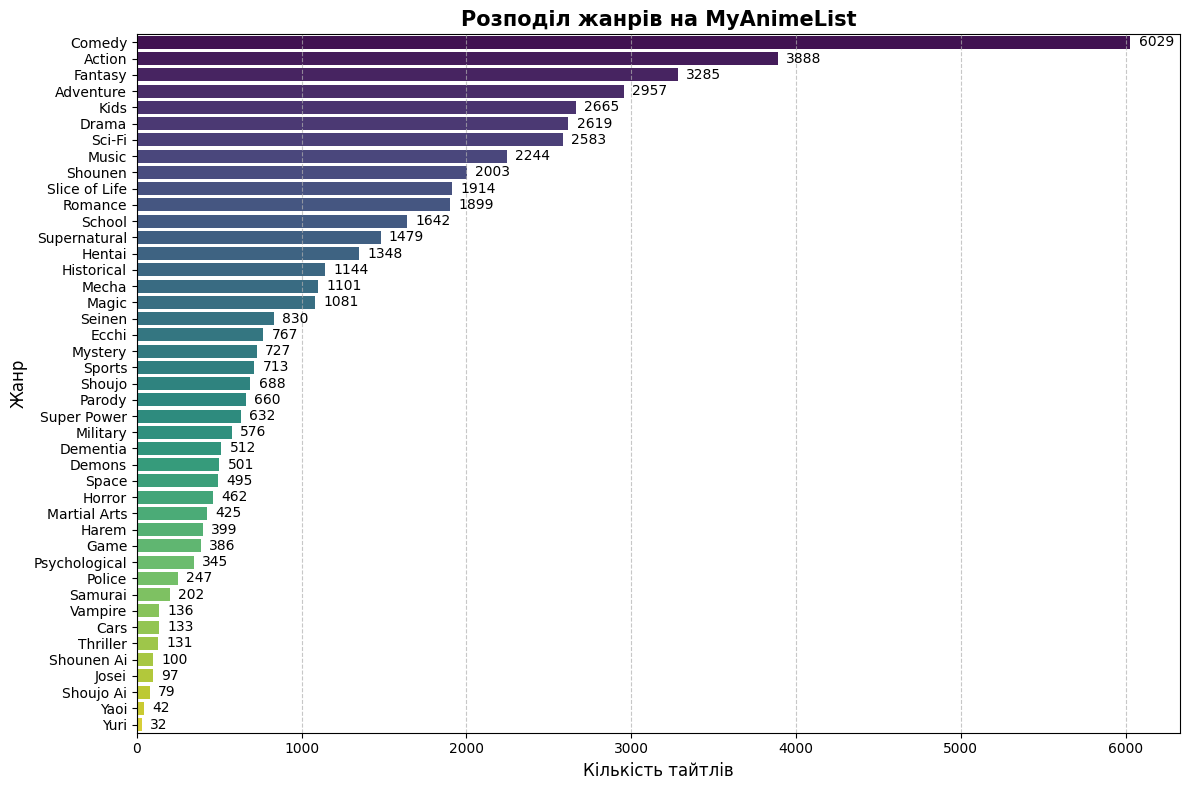

In [72]:
# 1. Відкидаємо порожні значення (ті 63 NaN)
valid_genres = df_anime['Genres'].dropna()

# 2. Розділяємо рядки по комі і "вибухаємо" (explode) їх в окремі елементи
all_genres = valid_genres.str.split(', ').explode()

# Очищаємо від можливих зайвих пробілів на краях
all_genres = all_genres.str.strip()

# 3. Рахуємо статистику
genre_counts = all_genres.value_counts()
total_unique_genres = len(genre_counts)
total_anime_with_genres = len(valid_genres)

# Створюємо зручний DataFrame для звіту
df_genre_stats = pd.DataFrame({
    'Кількість аніме': genre_counts,
    'Відсоток від усіх аніме (%)': (genre_counts / total_anime_with_genres * 100).round(2)
})

print("=========================================================")
print("               АНАЛІЗ РОЗПОДІЛУ ЖАНРІВ                   ")
print("=========================================================")
print(f"Всього унікальних жанрів у базі: {total_unique_genres}")
print(f"Аніме, що мають хоча б один жанр: {total_anime_with_genres}")
print("-" * 57)
print("Розподіл жанрів:\n")
print(df_genre_stats)
print("=========================================================\n")

# 4. Візуалізація: Горизонтальний Bar Chart для Топ-20
plt.figure(figsize=(12, 8))
sns.barplot(
    x=genre_counts.values, 
    y=genre_counts.index, 
    palette='viridis'
)
plt.title('Розподіл жанрів на MyAnimeList', fontsize=15, fontweight='bold')
plt.xlabel('Кількість тайтлів', fontsize=12)
plt.ylabel('Жанр', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Додаємо підписи значень на самі стовпчики
for index, value in enumerate(genre_counts.values):
    plt.text(value + 50, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [73]:
# 1. Перевіряємо, що лежить у колонці Episodes
unknown_episodes_count = (df_anime['Episodes'] == 'Unknown').sum()

print("--- АНАЛІЗ КОЛОНКИ Episodes ---")
print(f"Кількість рядків з 'Unknown': {unknown_episodes_count} ({(unknown_episodes_count/len(df_anime))*100:.2f}%)")

# 2. Перетворюємо 'Unknown' на NaN і змінюємо тип на float64
# Використовуємо pd.to_numeric, який безпечно конвертує текст у числа
df_anime['Episodes_Clean'] = pd.to_numeric(df_anime['Episodes'].replace('Unknown', np.nan), errors='coerce')

# 3. Перевіряємо результати
print(f"\nНовий тип колонки: {df_anime['Episodes_Clean'].dtype}")
print(f"Кількість NaN після конвертації: {df_anime['Episodes_Clean'].isna().sum()}")

# 4. Базова статистика по епізодах
print("\n--- СТАТИСТИКА КІЛЬКОСТІ ЕПІЗОДІВ ---")
print(df_anime['Episodes_Clean'].describe().round(1))

--- АНАЛІЗ КОЛОНКИ Episodes ---
Кількість рядків з 'Unknown': 516 (2.94%)

Новий тип колонки: float64
Кількість NaN після конвертації: 516

--- СТАТИСТИКА КІЛЬКОСТІ ЕПІЗОДІВ ---
count    17046.0
mean        11.5
std         47.3
min          1.0
25%          1.0
50%          2.0
75%         12.0
max       3057.0
Name: Episodes_Clean, dtype: float64


In [74]:
df_anime['Episodes'] = df_anime['Episodes_Clean']
df_anime = df_anime.drop(columns=['Episodes_Clean'])

--- СТАНДАРТНІ КІЛЬКОСТІ ЕПІЗОДІВ ---
1 еп.: 8381 аніме
12 еп.: 1445 аніме
2 еп.: 1368 аніме
13 еп.: 769 аніме
3 еп.: 631 аніме
26 еп.: 619 аніме
4 еп.: 451 аніме
6 еп.: 340 аніме
24 еп.: 258 аніме
52 еп.: 237 аніме
Інші нестандартні кількості: 2547 аніме



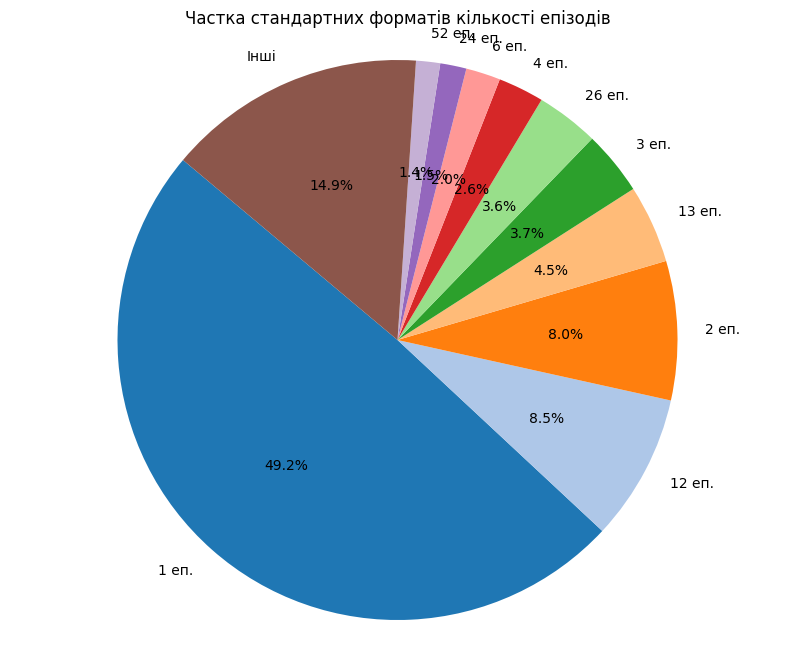

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# Підрахунок кількості аніме для кожного унікального значення епізодів
episodes_counts = df_anime['Episodes'].value_counts()

# Визначення кількості топових значень для відображення
top_n = 10
top_episodes = episodes_counts.head(top_n)

# Сумування всіх інших нестандартних значень
other_episodes_sum = episodes_counts.iloc[top_n:].sum()

# Формування фінального набору даних для графіка
plot_data = top_episodes.copy()
plot_data['Інші'] = other_episodes_sum

# Створення підписів для діаграми
labels = []
for idx in plot_data.index:
    if idx == 'Інші':
        labels.append(idx)
    else:
        labels.append(f"{int(idx)} еп.")

# Виведення текстової інформації на екран
print("--- СТАНДАРТНІ КІЛЬКОСТІ ЕПІЗОДІВ ---")
for val, count in top_episodes.items():
    print(f"{int(val)} еп.: {count} аніме")
print(f"Інші нестандартні кількості: {other_episodes_sum} аніме\n")

# Налаштування та побудова кругової діаграми
plt.figure(figsize=(10, 8))
plt.pie(
    plot_data, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.tab20.colors
)
plt.title('Частка стандартних форматів кількості епізодів')
plt.axis('equal') # Вирівнювання осей для ідеального кола

# Відображення графіка
plt.show()

In [76]:
# Заміна 'Unknown' на NaN у колонці 'Japanese name'
df_anime['Japanese name'] = df_anime['Japanese name'].replace('Unknown', np.nan)

# Перевірка кількості пропусків після заміни
missing_japanese_names = df_anime['Japanese name'].isna().sum()

# Виведення результату
print("--- ОЧИЩЕННЯ КОЛОНКИ Japanese name ---")
print(f"Кількість NaN після заміни 'Unknown': {missing_japanese_names}")

--- ОЧИЩЕННЯ КОЛОНКИ Japanese name ---
Кількість NaN після заміни 'Unknown': 48


--- КІЛЬКІСТЬ АНІМЕ ЗА ТИПАМИ ---
Type
TV         4996
OVA        3894
Movie      3041
Special    2218
ONA        1907
Music      1469
Unknown      37
Name: count, dtype: int64




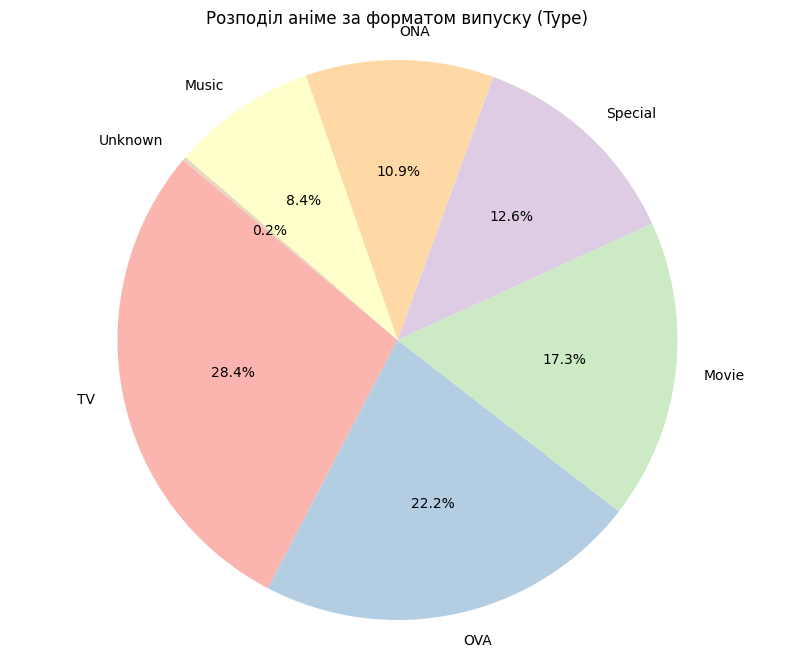

--- ОЧИЩЕННЯ ЗАВЕРШЕНО ---
Кількість NaN у колонці Type після заміни: 37


In [77]:
# 1. Підрахунок кількості аніме за кожним типом (включаючи 'Unknown')
type_counts = df_anime['Type'].value_counts()

# Виведення текстової статистики для точного розуміння цифр
print("--- КІЛЬКІСТЬ АНІМЕ ЗА ТИПАМИ ---")
print(type_counts)
print("\n")

# 2. Побудова кругової діаграми
plt.figure(figsize=(10, 8))
plt.pie(
    type_counts, 
    labels=type_counts.index, 
    autopct='%1.1f%%',       # Відображення відсотків з одним знаком після коми
    startangle=140,          # Поворот графіка для кращого візуального сприйняття
    colors=plt.cm.Pastel1.colors # Використання пастельної палітри кольорів
)
plt.title('Розподіл аніме за форматом випуску (Type)')
plt.axis('equal')            # Забезпечення ідеально круглої форми діаграми

# Відображення графіка на екрані
plt.show()

# 3. Заміна текстового 'Unknown' на стандартний пропуск NaN
df_anime['Type'] = df_anime['Type'].replace('Unknown', np.nan)

# Підрахунок та перевірка результату заміни
missing_types = df_anime['Type'].isna().sum()
print("--- ОЧИЩЕННЯ ЗАВЕРШЕНО ---")
print(f"Кількість NaN у колонці Type після заміни: {missing_types}")

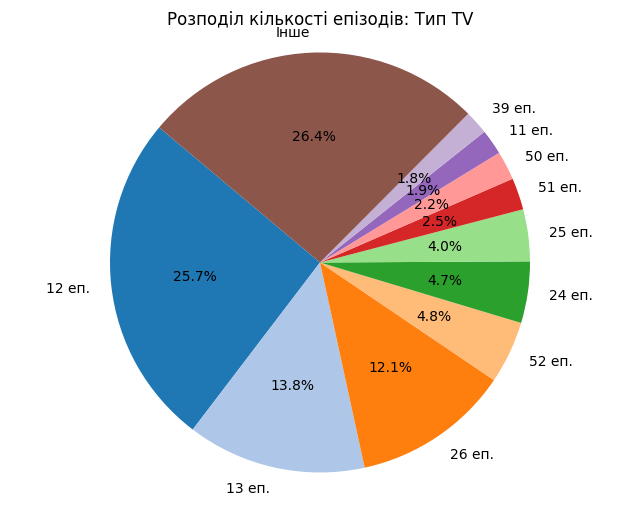

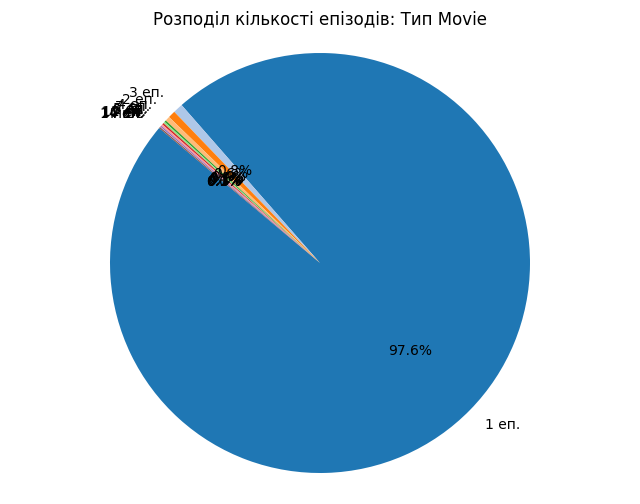

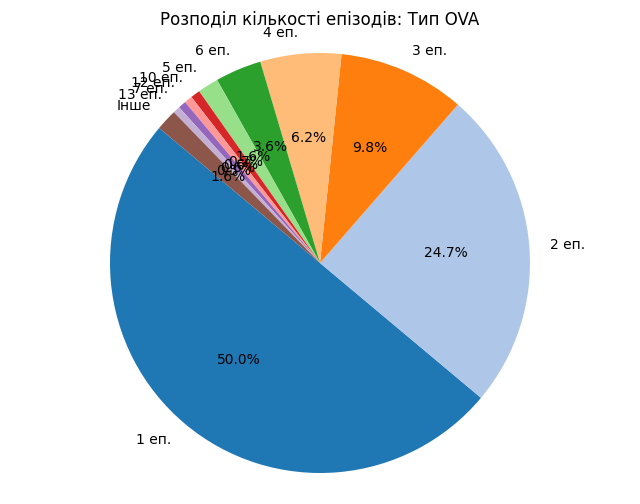

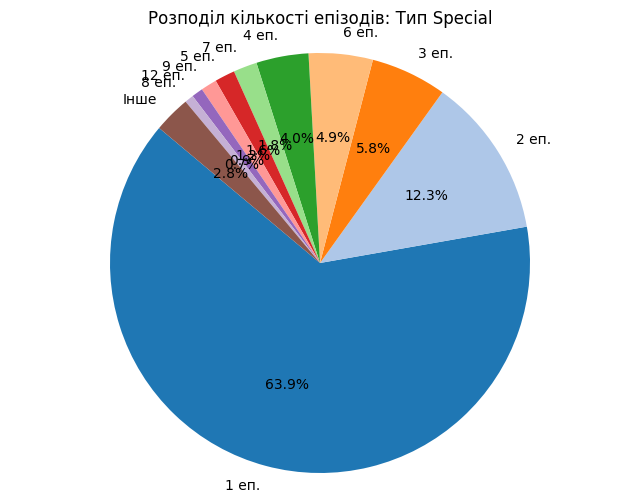

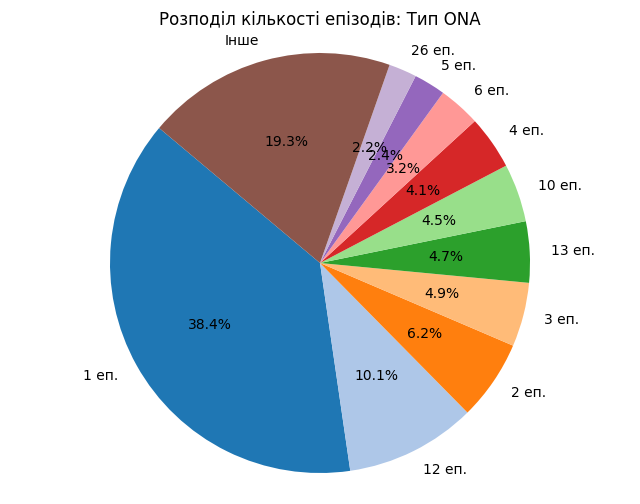

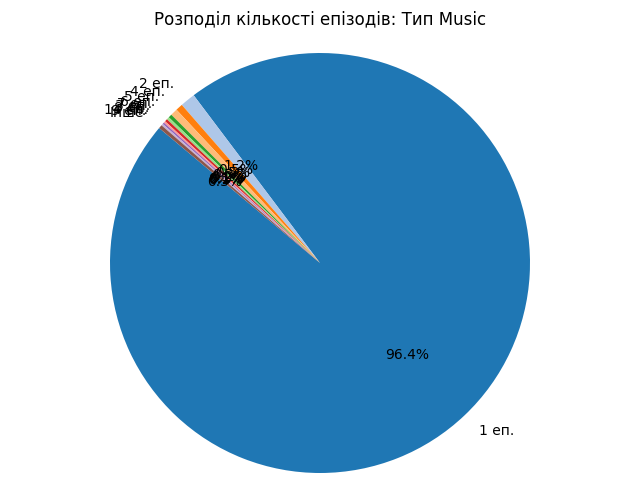

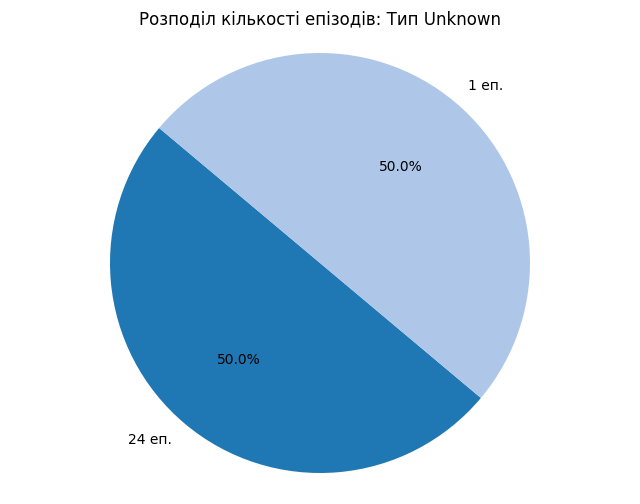

In [78]:
# Отримання списку унікальних типів, включаючи NaN
unique_types = df_anime['Type'].unique()

# Ітерація по кожному значенню типу
for anime_type in unique_types:
    # Фільтрація даних для поточного типу
    if pd.isna(anime_type):
        subset = df_anime[df_anime['Type'].isna()]
        type_label = 'Unknown'
    else:
        subset = df_anime[df_anime['Type'] == anime_type]
        type_label = anime_type
        
    # Підрахунок кількості епізодів
    episodes_counts = subset['Episodes'].value_counts()
    
    # Пропуск ітерації, якщо для даного типу немає інформації про епізоди
    if episodes_counts.empty:
        continue
        
    # Відбір топ-10 та підрахунок суми решти
    top_n = 10
    top_episodes = episodes_counts.head(top_n)
    other_episodes_sum = episodes_counts.iloc[top_n:].sum()
    
    # Підготовка даних для графіка
    plot_data = top_episodes.copy()
    if other_episodes_sum > 0:
        plot_data['Інше'] = other_episodes_sum
        
    # Формування підписів
    labels = [f"{int(idx)} еп." if str(idx).replace('.0','').isdigit() else str(idx) for idx in plot_data.index]
    
    # Побудова графіка
    plt.figure(figsize=(8, 6))
    plt.pie(
        plot_data, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.tab20.colors
    )
    plt.title(f'Розподіл кількості епізодів: Тип {type_label}')
    plt.axis('equal')
    plt.show()

In [79]:
# Загальна кількість рядків у датасеті
total_rows = len(df_anime)

# 1. Підрахунок кількості 'Unknown'
unknown_aired = (df_anime['Aired'] == 'Unknown').sum()
unknown_premiered = (df_anime['Premiered'] == 'Unknown').sum()

print("--- АНАЛІЗ 'Unknown' У КОЛОНКАХ ДАТ ---")
print(f"Колонка Aired: {unknown_aired} рядків ({ (unknown_aired / total_rows) * 100:.2f}%)")
print(f"Колонка Premiered: {unknown_premiered} рядків ({ (unknown_premiered / total_rows) * 100:.2f}%)")

# 2. Заміна 'Unknown' на NaN
df_anime['Aired'] = df_anime['Aired'].replace('Unknown', np.nan)
df_anime['Premiered'] = df_anime['Premiered'].replace('Unknown', np.nan)

# 3. Перевірка результату
print("\n--- ОЧИЩЕННЯ ЗАВЕРШЕНО ---")
print(f"Пропусків (NaN) у колонці Aired: {df_anime['Aired'].isna().sum()}")
print(f"Пропусків (NaN) у колонці Premiered: {df_anime['Premiered'].isna().sum()}")

--- АНАЛІЗ 'Unknown' У КОЛОНКАХ ДАТ ---
Колонка Aired: 309 рядків (1.76%)
Колонка Premiered: 12817 рядків (72.98%)

--- ОЧИЩЕННЯ ЗАВЕРШЕНО ---
Пропусків (NaN) у колонці Aired: 309
Пропусків (NaN) у колонці Premiered: 12817


In [80]:
# Групування за типом і розрахунок статистики пропусків
premiered_nan_stats = df_anime.groupby('Type', dropna=False).apply(
    lambda x: pd.Series({
        'Всього аніме': len(x),
        'Пропусків Premiered': x['Premiered'].isna().sum(),
        '% пропусків': (x['Premiered'].isna().sum() / len(x) * 100).round(2)
    })
)

print("--- АНАЛІЗ ПРОПУСКІВ PREMIERED ЗА ТИПАМИ ---")
print(premiered_nan_stats)

--- АНАЛІЗ ПРОПУСКІВ PREMIERED ЗА ТИПАМИ ---
         Всього аніме  Пропусків Premiered  % пропусків
Type                                                   
Movie          3041.0               3041.0       100.00
Music          1469.0               1469.0       100.00
ONA            1907.0               1907.0       100.00
OVA            3894.0               3894.0       100.00
Special        2218.0               2218.0       100.00
TV             4996.0                251.0         5.02
NaN              37.0                 37.0       100.00


In [81]:
# Створення маски для фільтрації: тип 'TV' ТА відсутнє значення у 'Premiered'
mask_tv_no_premiered = (df_anime['Type'] == 'TV') & (df_anime['Premiered'].isna())

# Створення окремого датафрейму з 251 аніме
tv_no_premiered_df = df_anime[mask_tv_no_premiered]

# Підрахунок статистики для колонки Aired
total_tv_missing_premiered = len(tv_no_premiered_df)
aired_missing_count = tv_no_premiered_df['Aired'].isna().sum()
aired_present_count = total_tv_missing_premiered - aired_missing_count

# Виведення загальної статистики
print("--- АНАЛІЗ КОЛОНКИ AIRED ДЛЯ TV БЕЗ PREMIERED ---")
print(f"Всього TV-аніме без Premiered: {total_tv_missing_premiered}")
print(f"Мають заповнену дату в Aired: {aired_present_count}")
print(f"Мають пропуск (NaN) у Aired: {aired_missing_count}\n")

# Виведення прикладів наявних дат для аналізу
if aired_present_count > 0:
    print("--- ПРИКЛАДИ НАЯВНИХ ДАТ У КОЛОНЦІ AIRED ---")
    examples = tv_no_premiered_df[tv_no_premiered_df['Aired'].notna()]
    print(examples[['Name', 'Aired', 'Episodes']].head(10).to_string(index=False))

--- АНАЛІЗ КОЛОНКИ AIRED ДЛЯ TV БЕЗ PREMIERED ---
Всього TV-аніме без Premiered: 251
Мають заповнену дату в Aired: 175
Мають пропуск (NaN) у Aired: 76

--- ПРИКЛАДИ НАЯВНИХ ДАТ У КОЛОНЦІ AIRED ---
                        Name                Aired  Episodes
                     Usavich         2006 to 2007      13.0
                   Mofu☆Mofu    Aug, 2008 to 2008      11.0
                Mikan-Seijin                 1992      26.0
               Keshikasu-kun Jan 12, 2010 to 2010      25.0
                     Domo TV                 2008      26.0
            Origami Warriors                 2004      52.0
Hello Kitty no Stump Village                 2005      26.0
               Xiang Qi Wang                 2006      26.0
        Chengyu Donghua Lang         1987 to 1988     180.0
                   Hyper ERT                 2008      20.0


In [82]:
import re

# 1. Фільтрація: Type - TV, Premiered - NaN, Aired - not NaN
mask = (df_anime['Type'] == 'TV') & (df_anime['Premiered'].isna()) & (df_anime['Aired'].notna())
df_filtered = df_anime[mask].copy()

# 2. Відділення дати початку (беремо все, що йде до ' to ')
df_filtered['Aired_Start'] = df_filtered['Aired'].astype(str).str.split(' to ').str[0]

# 3. Використання регулярного виразу для пошуку назви місяця у форматі MAL (Jan, Feb, Mar і т.д.)
# expand=False повертає знайдене значення як рядок (або NaN, якщо не знайдено)
month_pattern = r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)'
df_filtered['Extracted_Month'] = df_filtered['Aired_Start'].str.extract(month_pattern, expand=False, flags=re.IGNORECASE)

# 4. Відбір лише тих аніме, де місяць знайдено
df_with_month = df_filtered[df_filtered['Extracted_Month'].notna()]

# 5. Підрахунок результатів та виведення
count_with_month = len(df_with_month)

print("--- АНАЛІЗ НАЯВНОСТІ МІСЯЦЯ У КОЛОНЦІ AIRED ---")
print(f"Знайдено аніме з вказаним місяцем: {count_with_month}\n")

if count_with_month > 0:
    print("--- ПРИКЛАДИ 10 АНІМЕ З ВИЗНАЧЕНИМ МІСЯЦЕМ ---")
    print(df_with_month[['Name', 'Type', 'Aired', 'Premiered']].head(10).to_string(index=False))

--- АНАЛІЗ НАЯВНОСТІ МІСЯЦЯ У КОЛОНЦІ AIRED ---
Знайдено аніме з вказаним місяцем: 72

--- ПРИКЛАДИ 10 АНІМЕ З ВИЗНАЧЕНИМ МІСЯЦЕМ ---
                                   Name Type                Aired Premiered
                              Mofu☆Mofu   TV    Aug, 2008 to 2008       NaN
                          Keshikasu-kun   TV Jan 12, 2010 to 2010       NaN
                        Wo Wei Ge Kuang   TV  Aug 6, 2001 to 2002       NaN
                       Wei Qi Shao Nian   TV Jul 28, 2005 to 2009       NaN
                        Ginga Patrol PJ   TV  Oct 9, 1982 to 1983       NaN
       Qin Shi Ming Yue: Zhu Zi Bai Jia   TV Jun 10, 2010 to 2011       NaN
      Qin Shi Ming Yue: Ye Jin Tianming   TV Jul 17, 2008 to 2008       NaN
                        Chiisana Ojisan   TV  Oct 1, 2012 to 2014       NaN
     Qin Shi Ming Yue: Wanli Changcheng   TV Sep 30, 2012 to 2013       NaN
The Adventures of Hello Kitty & Friends   TV Feb 18, 2008 to 2009       NaN


In [83]:
# 1. Відділяємо першу частину дати (до ' to ') для всього датасету
# Використовуємо тимчасову колонку
df_anime['Aired_Start_Raw'] = df_anime['Aired'].astype(str).str.split(' to ').str[0]

# 2. Витягуємо рік (шукаємо 4 цифри підряд)
# astype(float) дозволяє коректно зберігати NaN для пропусків
df_anime['Start_Year'] = df_anime['Aired_Start_Raw'].str.extract(r'(\d{4})').astype(float)

# 3. Витягуємо місяць і перетворюємо його на число (1-12)
# Словник для перекладу тексту в числа
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Шукаємо текстовий місяць (Jan, Feb і т.д.)
df_anime['Start_Month_Text'] = df_anime['Aired_Start_Raw'].str.extract(
    r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)', 
    flags=re.IGNORECASE
)[0]

# Замінюємо текст на числа за допомогою словника
df_anime['Start_Month'] = df_anime['Start_Month_Text'].map(month_map)

# 4. Видаляємо тимчасові колонки, щоб тримати датасет у чистоті
df_anime = df_anime.drop(columns=['Aired_Start_Raw', 'Start_Month_Text'])

# Виведення результатів
print("--- СТВОРЕННЯ ЧИСЛОВИХ КОЛОНОК ДАТИ ЗАВЕРШЕНО ---")
print(f"Всього аніме в базі: {len(df_anime)}")
print(f"Аніме з відомим роком початку (Start_Year): {df_anime['Start_Year'].notna().sum()}")
print(f"Аніме з відомим місяцем початку (Start_Month): {df_anime['Start_Month'].notna().sum()}\n")

# Покажемо кілька рядків для перевірки
print("--- ПРИКЛАД НОВИХ КОЛОНОК ---")
print(df_anime[['Name', 'Aired', 'Start_Year', 'Start_Month']].head())

--- СТВОРЕННЯ ЧИСЛОВИХ КОЛОНОК ДАТИ ЗАВЕРШЕНО ---
Всього аніме в базі: 17562
Аніме з відомим роком початку (Start_Year): 17253
Аніме з відомим місяцем початку (Start_Month): 15802

--- ПРИКЛАД НОВИХ КОЛОНОК ---
                              Name                         Aired  Start_Year  \
0                     Cowboy Bebop   Apr 3, 1998 to Apr 24, 1999      1998.0   
1  Cowboy Bebop: Tengoku no Tobira                   Sep 1, 2001      2001.0   
2                           Trigun   Apr 1, 1998 to Sep 30, 1998      1998.0   
3               Witch Hunter Robin   Jul 2, 2002 to Dec 24, 2002      2002.0   
4                   Bouken Ou Beet  Sep 30, 2004 to Sep 29, 2005      2004.0   

   Start_Month  
0          4.0  
1          9.0  
2          4.0  
3          7.0  
4          9.0  


--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ PRODUCERS ---
Кількість 'Unknown': 7794 (44.38%)

--- СТАТИСТИКА ПРОДЮСЕРІВ ---
Кількість унікальних продюсерів: 1306
Кількість NaN після заміни: 7794

Топ-10 продюсерів за кількістю аніме:
Producers
NHK              715
Aniplex          495
TV Tokyo         476
Lantis           445
Bandai Visual    416
Fuji TV          332
Movic            325
Pony Canyon      315
Sotsu            301
Dentsu           293


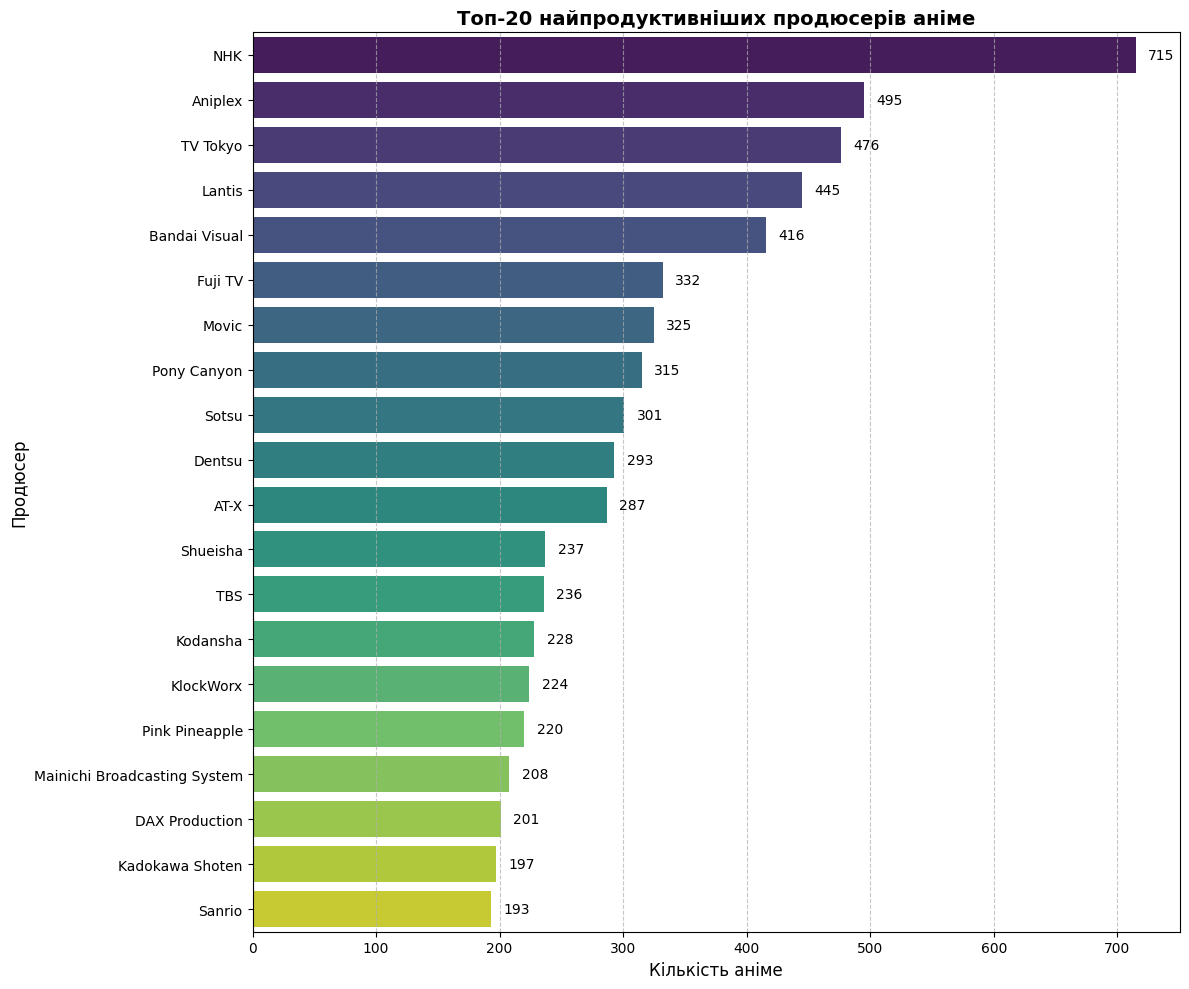

In [84]:
# 1. Підрахунок 'Unknown'
total_rows = len(df_anime)
unknown_producers_count = (df_anime['Producers'] == 'Unknown').sum()
unknown_producers_pct = (unknown_producers_count / total_rows) * 100

print("--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ PRODUCERS ---")
print(f"Кількість 'Unknown': {unknown_producers_count} ({unknown_producers_pct:.2f}%)\n")

# 2. Заміна 'Unknown' на NaN
df_anime['Producers'] = df_anime['Producers'].replace('Unknown', np.nan)

# 3. Розбиття рядків з кількома продюсерами та їх підрахунок
# Вилучаємо NaN перед розбиттям, щоб уникнути помилок
valid_producers = df_anime['Producers'].dropna()

# Розділяємо по комі, розгортаємо в окремі рядки та видаляємо зайві пробіли
exploded_producers = valid_producers.str.split(', ').explode().str.strip()

# Рахуємо частоту кожного продюсера
producer_counts = exploded_producers.value_counts()
total_unique_producers = len(producer_counts)

print("--- СТАТИСТИКА ПРОДЮСЕРІВ ---")
print(f"Кількість унікальних продюсерів: {total_unique_producers}")
print(f"Кількість NaN після заміни: {df_anime['Producers'].isna().sum()}\n")

print("Топ-10 продюсерів за кількістю аніме:")
print(producer_counts.head(10).to_string())

# 4. Візуалізація (Топ-20 продюсерів)
plt.figure(figsize=(12, 10))

# Використання hue та legend=False для сумісності з новими версіями seaborn
sns.barplot(
    x=producer_counts.head(20).values, 
    y=producer_counts.head(20).index, 
    hue=producer_counts.head(20).index,
    palette='viridis',
    legend=False
)

plt.title('Топ-20 найпродуктивніших продюсерів аніме', fontsize=14, fontweight='bold')
plt.xlabel('Кількість аніме', fontsize=12)
plt.ylabel('Продюсер', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Додавання числових значень на стовпчики для точності
for index, value in enumerate(producer_counts.head(20).values):
    plt.text(value + 10, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ LICENSORS ---
Кількість 'Unknown': 13616 (77.53%)

--- СТАТИСТИКА ЛІЦЕНЗОРІВ ---
Кількість унікальних лицензорів: 78
Кількість NaN після заміни: 13616

Топ-10 лицензорів за кількістю аніме:
Licensors
Funimation                  1118
Sentai Filmworks             744
Discotek Media               364
ADV Films                    293
Media Blasters               271
Bandai Entertainment         201
Aniplex of America           192
Geneon Entertainment USA     174
VIZ Media                    174
Nozomi Entertainment         134


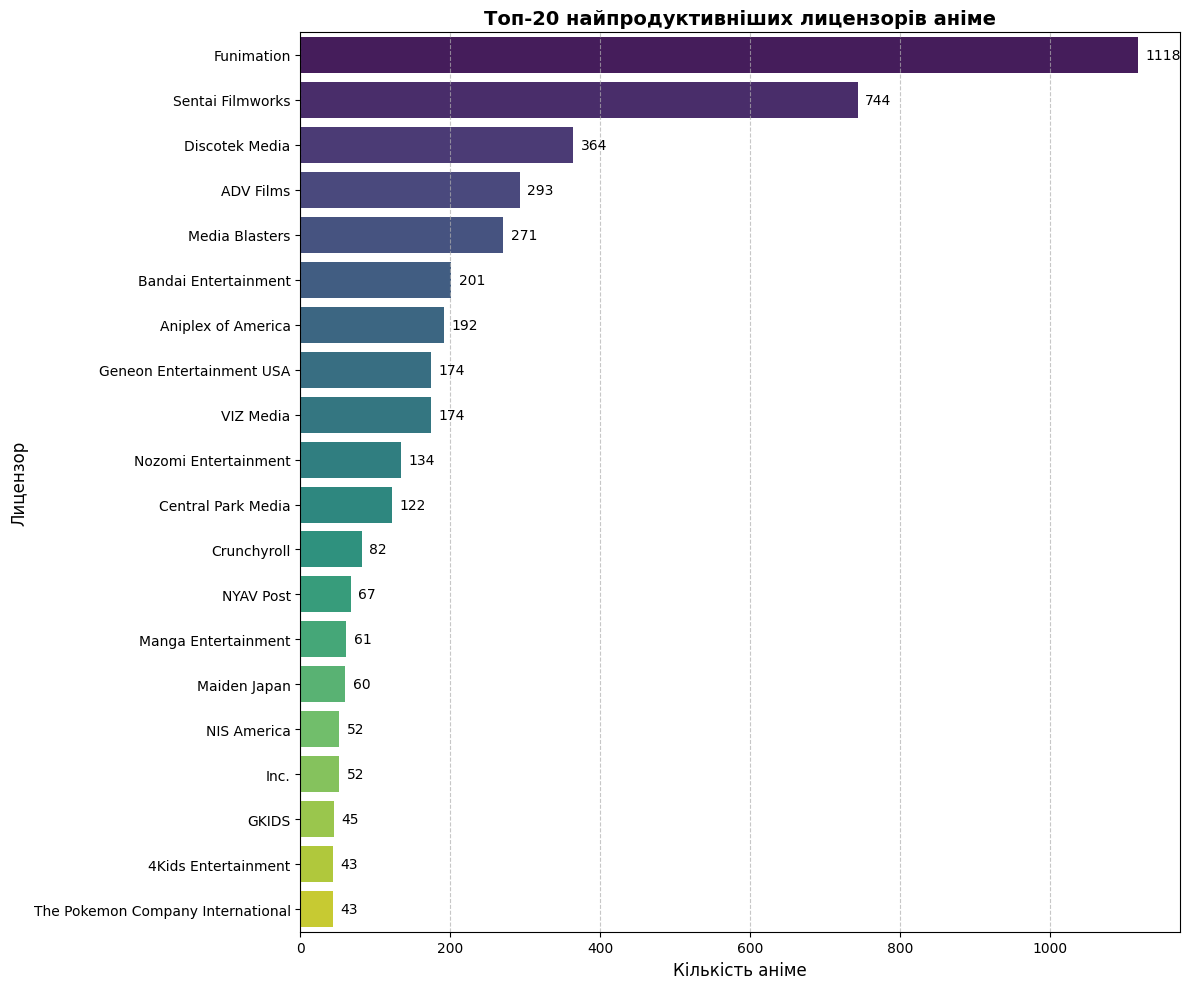

In [85]:
# 1. Підрахунок 'Unknown'
total_rows = len(df_anime)
unknown_licensors_count = (df_anime['Licensors'] == 'Unknown').sum()
unknown_licensors_pct = (unknown_licensors_count / total_rows) * 100

print("--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ LICENSORS ---")
print(f"Кількість 'Unknown': {unknown_licensors_count} ({unknown_licensors_pct:.2f}%)\n")

# 2. Заміна 'Unknown' на NaN
df_anime['Licensors'] = df_anime['Licensors'].replace('Unknown', np.nan)

# 3. Розбиття рядків з кількома продюсерами та їх підрахунок
# Вилучаємо NaN перед розбиттям, щоб уникнути помилок
valid_licensors = df_anime['Licensors'].dropna()

# Розділяємо по комі, розгортаємо в окремі рядки та видаляємо зайві пробіли
exploded_licensors = valid_licensors.str.split(', ').explode().str.strip()

# Рахуємо частоту кожного лицензора
licensor_counts = exploded_licensors.value_counts()
total_unique_licensors = len(licensor_counts)

print("--- СТАТИСТИКА ЛІЦЕНЗОРІВ ---")
print(f"Кількість унікальних лицензорів: {total_unique_licensors}")
print(f"Кількість NaN після заміни: {df_anime['Licensors'].isna().sum()}\n")

print("Топ-10 лицензорів за кількістю аніме:")
print(licensor_counts.head(10).to_string())

# 4. Візуалізація (Топ-20 лицензорів)
plt.figure(figsize=(12, 10))

# Використання hue та legend=False для сумісності з новими версіями seaborn
sns.barplot(
    x=licensor_counts.head(20).values, 
    y=licensor_counts.head(20).index, 
    hue=licensor_counts.head(20).index,
    palette='viridis',
    legend=False
)

plt.title('Топ-20 найпродуктивніших лицензорів аніме', fontsize=14, fontweight='bold')
plt.xlabel('Кількість аніме', fontsize=12)
plt.ylabel('Лицензор', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Додавання числових значень на стовпчики для точності
for index, value in enumerate(licensor_counts.head(20).values):
    plt.text(value + 10, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ STUDIOS ---
Кількість 'Unknown': 7079 (40.31%)

--- СТАТИСТИКА СТУДІЙ ---
Кількість унікальних студій: 722
Кількість NaN після заміни: 7079

Топ-10 студій за кількістю аніме:
Studios
Toei Animation       778
Sunrise              502
J.C.Staff            382
Madhouse             364
Production I.G       335
TMS Entertainment    300
Studio Deen          287
Studio Pierrot       263
OLM                  237
Nippon Animation     217


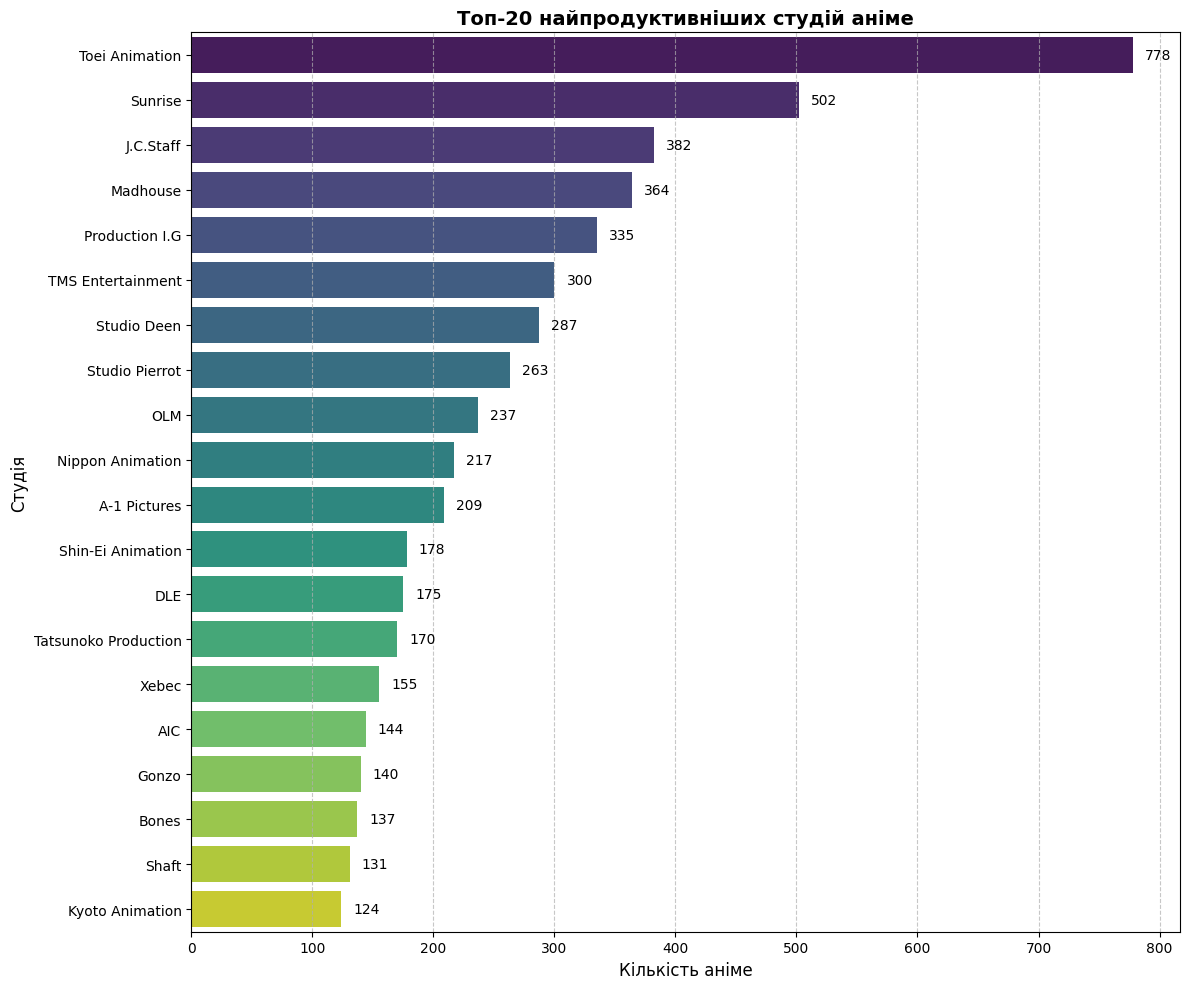

In [86]:
# 1. Підрахунок 'Unknown'
total_rows = len(df_anime)
unknown_studios_count = (df_anime['Studios'] == 'Unknown').sum()
unknown_studios_pct = (unknown_studios_count / total_rows) * 100

print("--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ STUDIOS ---")
print(f"Кількість 'Unknown': {unknown_studios_count} ({unknown_studios_pct:.2f}%)\n")

# 2. Заміна 'Unknown' на NaN
df_anime['Studios'] = df_anime['Studios'].replace('Unknown', np.nan)

# 3. Розбиття рядків з кількома продюсерами та їх підрахунок
# Вилучаємо NaN перед розбиттям, щоб уникнути помилок
valid_studios = df_anime['Studios'].dropna()

# Розділяємо по комі, розгортаємо в окремі рядки та видаляємо зайві пробіли
exploded_studios = valid_studios.str.split(', ').explode().str.strip()

# Рахуємо частоту кожного студії
studio_counts = exploded_studios.value_counts()
total_unique_studios = len(studio_counts)

print("--- СТАТИСТИКА СТУДІЙ ---")
print(f"Кількість унікальних студій: {total_unique_studios}")
print(f"Кількість NaN після заміни: {df_anime['Studios'].isna().sum()}\n")

print("Топ-10 студій за кількістю аніме:")
print(studio_counts.head(10).to_string())

# 4. Візуалізація (Топ-20 студій)
plt.figure(figsize=(12, 10))

# Використання hue та legend=False для сумісності з новими версіями seaborn
sns.barplot(
    x=studio_counts.head(20).values, 
    y=studio_counts.head(20).index, 
    hue=studio_counts.head(20).index,
    palette='viridis',
    legend=False
)

plt.title('Топ-20 найпродуктивніших студій аніме', fontsize=14, fontweight='bold')
plt.xlabel('Кількість аніме', fontsize=12)
plt.ylabel('Студія', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Додавання числових значень на стовпчики для точності
for index, value in enumerate(studio_counts.head(20).values):
    plt.text(value + 10, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ SOURCE ---
Кількість 'Unknown': 3567 (20.31%)

--- ВСІ ДЖЕРЕЛА ---
Source
Original         5215
Manga            3825
Visual novel      993
Game              880
Light novel       768
Other             597
Novel             510
Music             317
4-koma manga      288
Web manga         252
Picture book      147
Book              112
Card game          64
Digital manga      15
Radio              12

Кількість NaN після заміни: 3567



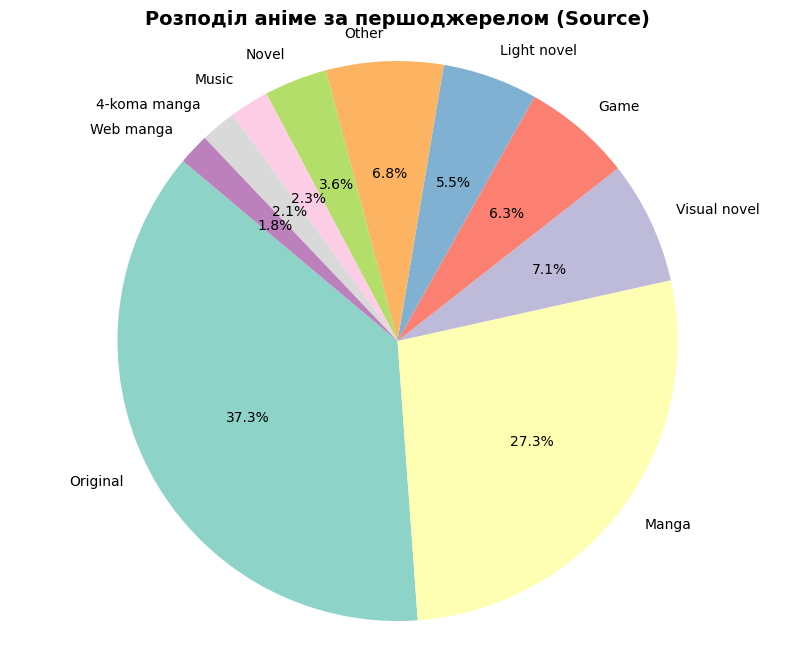

In [87]:
# 1. Підрахунок 'Unknown' у колонці Source
total_rows = len(df_anime)
unknown_source_count = (df_anime['Source'] == 'Unknown').sum()
unknown_source_pct = (unknown_source_count / total_rows) * 100

print("--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ SOURCE ---")
print(f"Кількість 'Unknown': {unknown_source_count} ({unknown_source_pct:.2f}%)\n")

# 2. Заміна 'Unknown' на NaN
df_anime['Source'] = df_anime['Source'].replace('Unknown', np.nan)

# 3. Підрахунок кількості аніме для кожного джерела
source_counts = df_anime['Source'].value_counts()

print("--- ВСІ ДЖЕРЕЛА ---")
print(source_counts.to_string())
print(f"\nКількість NaN після заміни: {df_anime['Source'].isna().sum()}\n")

# 4. Підготовка даних для кругової діаграми (Топ-10 + Інше)
top_n = 10
top_sources = source_counts.head(top_n)
other_sources_sum = source_counts.iloc[top_n:].sum()

# Створюємо копію даних для графіка та додаємо категорію 'Інші'
plot_data = top_sources.copy()
if other_sources_sum > 0:
   plot_data['Other'] = plot_data['Other'] + other_sources_sum

# 5. Побудова кругової діаграми
plt.figure(figsize=(10, 8))
plt.pie(
    plot_data, 
    labels=plot_data.index, 
    autopct='%1.1f%%',       # Показуємо відсотки з однією цифрою після коми
    startangle=140,          # Повертаємо графік для гарного вигляду
    colors=plt.cm.Set3.colors # Використовуємо приємну палітру кольорів
)

plt.title('Розподіл аніме за першоджерелом (Source)', fontsize=14, fontweight='bold')
plt.axis('equal') # Робимо діаграму ідеально круглою

# Відображення графіка
plt.show()

--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ RATING ---
Кількість 'Unknown': 688 (3.92%)

--- ВСІ РЕЙТИНГИ ---
Rating
PG-13 - Teens 13 or older         6132
G - All Ages                      5782
PG - Children                     1461
Rx - Hentai                       1345
R - 17+ (violence & profanity)    1157
R+ - Mild Nudity                   997

Кількість NaN після заміни: 688



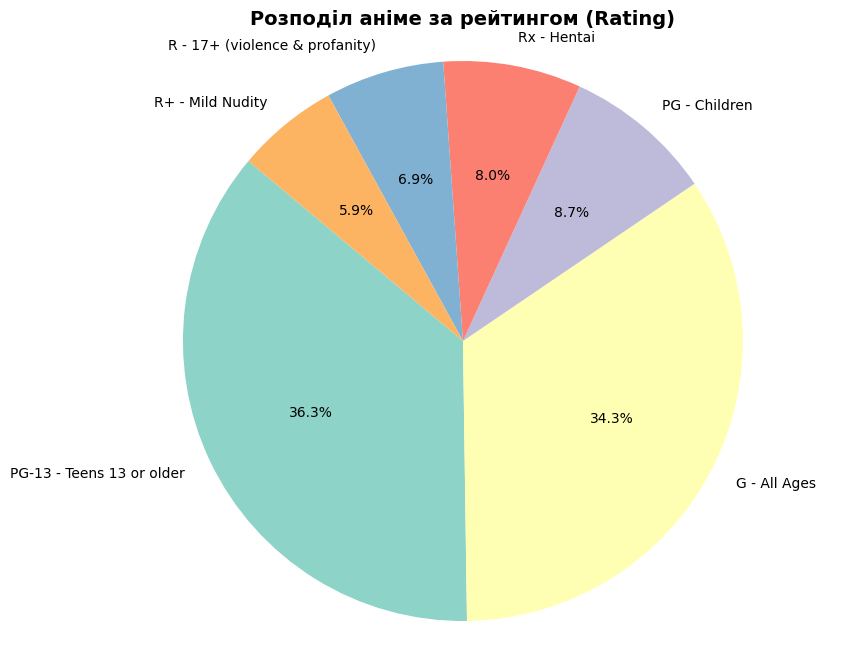

In [88]:
# 1. Підрахунок 'Unknown' у колонці Rating
total_rows = len(df_anime)
unknown_rating_count = (df_anime['Rating'] == 'Unknown').sum()
unknown_rating_pct = (unknown_rating_count / total_rows) * 100

print("--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ RATING ---")
print(f"Кількість 'Unknown': {unknown_rating_count} ({unknown_rating_pct:.2f}%)\n")

# 2. Заміна 'Unknown' на NaN
df_anime['Rating'] = df_anime['Rating'].replace('Unknown', np.nan)

# 3. Підрахунок кількості аніме для кожного рейтингу
rating_counts = df_anime['Rating'].value_counts()

print("--- ВСІ РЕЙТИНГИ ---")
print(rating_counts.to_string())
print(f"\nКількість NaN після заміни: {df_anime['Rating'].isna().sum()}\n")


# Створюємо копію даних для графіка
plot_data = rating_counts.copy()

# 5. Побудова кругової діаграми
plt.figure(figsize=(10, 8))
plt.pie(
    plot_data, 
    labels=plot_data.index, 
    autopct='%1.1f%%',       # Показуємо відсотки з однією цифрою після коми
    startangle=140,          # Повертаємо графік для гарного вигляду
    colors=plt.cm.Set3.colors # Використовуємо приємну палітру кольорів
)

plt.title('Розподіл аніме за рейтингом (Rating)', fontsize=14, fontweight='bold')
plt.axis('equal') # Робимо діаграму ідеально круглою

# Відображення графіка
plt.show()

--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ DURATION ---
Кількість 'Unknown': 555 (3.16%)

--- ТОП-10 ТРИВАЛОСТЕЙ ---
Duration
24 min. per ep.    1723
23 min. per ep.    1070
25 min. per ep.     846
30 min. per ep.     746
2 min.              745
3 min.              547
4 min.              530
3 min. per ep.      415
5 min. per ep.      397
1 min.              369

Кількість NaN після заміни: 555



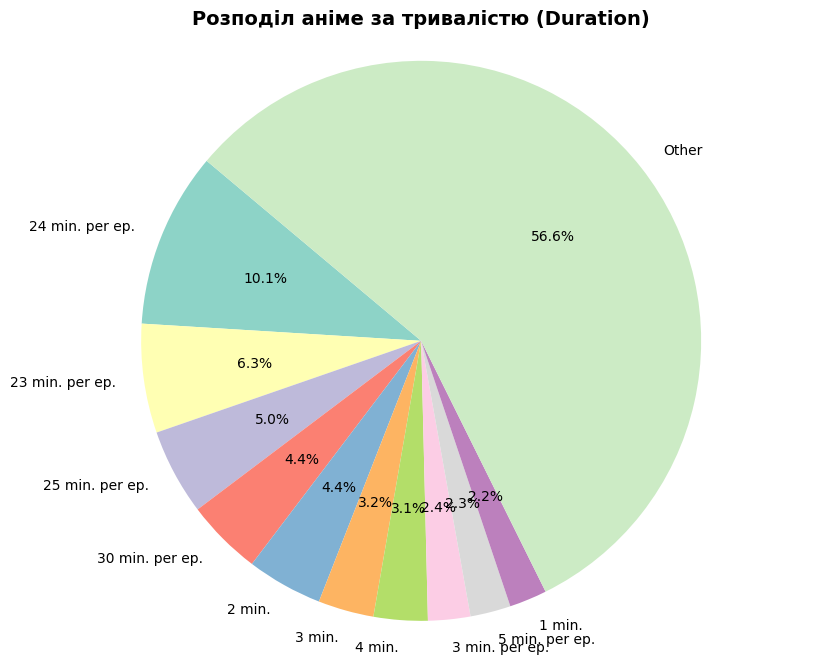

In [89]:
# 1. Підрахунок 'Unknown' у колонці Duration
total_rows = len(df_anime)
unknown_duration_count = (df_anime['Duration'] == 'Unknown').sum()
unknown_duration_pct = (unknown_duration_count / total_rows) * 100

print("--- АНАЛІЗ ПРОПУСКІВ У КОЛОНЦІ DURATION ---")
print(f"Кількість 'Unknown': {unknown_duration_count} ({unknown_duration_pct:.2f}%)\n")

# 2. Заміна 'Unknown' на NaN
df_anime['Duration'] = df_anime['Duration'].replace('Unknown', np.nan)

# 3. Підрахунок кількості аніме для кожного тривалості
duration_counts = df_anime['Duration'].value_counts()

print("--- ТОП-10 ТРИВАЛОСТЕЙ ---")
print(duration_counts.head(10).to_string())
print(f"\nКількість NaN після заміни: {df_anime['Duration'].isna().sum()}\n")

# 4. Підготовка даних для кругової діаграми (Топ-10 + Інше)
top_n = 10
top_durations = duration_counts.head(top_n)
other_durations_sum = duration_counts.iloc[top_n:].sum()

# Створюємо копію даних для графіка та додаємо категорію 'Інші'
plot_data = top_durations.copy()
if other_durations_sum > 0:
   plot_data['Other'] = other_durations_sum

# 5. Побудова кругової діаграми
plt.figure(figsize=(10, 8))
plt.pie(
    plot_data, 
    labels=plot_data.index, 
    autopct='%1.1f%%',       # Показуємо відсотки з однією цифрою після коми
    startangle=140,          # Повертаємо графік для гарного вигляду
    colors=plt.cm.Set3.colors # Використовуємо приємну палітру кольорів
)

plt.title('Розподіл аніме за тривалістю (Duration)', fontsize=14, fontweight='bold')
plt.axis('equal') # Робимо діаграму ідеально круглою

# Відображення графіка
plt.show()

In [90]:
# 1. Заміна 'Unknown' на NaN у колонці Duration
df_anime['Duration'] = df_anime['Duration'].replace('Unknown', np.nan)

# 2. Створення функції для конвертації тексту в хвилини
def convert_to_minutes(duration_str):
    # Якщо значення є пропуском (NaN), повертаємо NaN
    if pd.isna(duration_str):
        return np.nan
        
    total_minutes = 0
    
    # Шукаємо години: цифри (\d+), після яких іде "hr"
    # re.search знаходить цей шаблон у тексті
    hours_match = re.search(r'(\d+)\s*hr', duration_str)
    if hours_match:
        # Якщо години знайдені, множимо їх на 60
        total_minutes += int(hours_match.group(1)) * 60
        
    # Шукаємо хвилини: цифри (\d+), після яких іде "min"
    minutes_match = re.search(r'(\d+)\s*min', duration_str)
    if minutes_match:
        # Якщо хвилини знайдені, просто додаємо їх
        total_minutes += int(minutes_match.group(1))
        
    return total_minutes

# 3. Застосування функції до колонки та створення нової колонки 'Duration_Minutes'
df_anime['Duration_Minutes'] = df_anime['Duration'].apply(convert_to_minutes)

# 4. Виведення результатів для перевірки
print("--- ПЕРЕВІРКА КОНВЕРТАЦІЇ ТРИВАЛОСТІ ---")
print(f"Кількість NaN у новій колонці: {df_anime['Duration_Minutes'].isna().sum()}\n")

# Показуємо випадкові 10 рядків, щоб перевірити різні формати (з годинами, хвилинами, per ep.)
# dropna() використовується лише для того, щоб показати заповнені приклади
examples = df_anime[['Duration', 'Duration_Minutes']].dropna().sample(10)
print(examples.to_string(index=False))

--- ПЕРЕВІРКА КОНВЕРТАЦІЇ ТРИВАЛОСТІ ---
Кількість NaN у новій колонці: 555

       Duration  Duration_Minutes
        10 min.              10.0
        11 min.              11.0
        24 min.              24.0
        16 min.              16.0
 5 min. per ep.               5.0
        15 min.              15.0
24 min. per ep.              24.0
        57 min.              57.0
        59 min.              59.0
        13 min.              13.0


In [91]:
# 1. Розрахунок загальної тривалості у хвилинах
# Множимо тривалість одного епізоду на загальну кількість епізодів
df_anime['Total_Duration_Minutes'] = df_anime['Duration_Minutes'] * df_anime['Episodes']

# 2. Розрахунок загальної тривалості у годинах (ділимо хвилини на 60)
df_anime['Total_Duration_Hours'] = df_anime['Total_Duration_Minutes'] / 60

# 3. Виведення топ-5 найдовших аніме для перевірки
print("--- ТОП-5 НАЙДОВШИХ АНІМЕ ЗА ЗАГАЛЬНИМ ЧАСОМ (ГОДИНИ) ---")

# Сортуємо дані від найбільшого до найменшого (ascending=False)
longest_anime = df_anime.sort_values(by='Total_Duration_Hours', ascending=False)

# Вибираємо для відображення лише найцікавіші колонки
columns_to_show = ['Name', 'Type', 'Episodes', 'Duration_Minutes', 'Total_Duration_Hours']
print(longest_anime[columns_to_show].head(5).to_string(index=False))

# Перевірка наявності пропусків у новій колонці
print(f"\nКількість пропусків у Total_Duration_Hours: {df_anime['Total_Duration_Hours'].isna().sum()}")

--- ТОП-5 НАЙДОВШИХ АНІМЕ ЗА ЗАГАЛЬНИМ ЧАСОМ (ГОДИНИ) ---
                              Name Type  Episodes  Duration_Minutes  Total_Duration_Hours
Manga Nippon Mukashibanashi (1976)   TV    1471.0              25.0            612.916667
                           Lan Mao   TV    3057.0              11.0            560.450000
                   Doraemon (1979)   TV    1787.0              11.0            327.616667
    Shima Shima Tora no Shimajirou   TV     726.0              23.0            278.300000
                Naruto: Shippuuden   TV     500.0              23.0            191.666667

Кількість пропусків у Total_Duration_Hours: 794


In [92]:
# 1. Створюємо список колонок, які нас цікавлять
columns_to_check = ['Watching', 'Completed', 'On-Hold', 'Dropped', 'Plan to Watch']

# Отримуємо загальну кількість рядків для розрахунку відсотків
total_rows = len(df_anime)

print("--- АНАЛІЗ КОЛОНОК СТАТУСУ ПЕРЕГЛЯДУ ---")

# 2. Запускаємо цикл по кожній колонці
for col in columns_to_check:
    
    # 3. Підрахунок 'Unknown'
    unknown_count = (df_anime[col] == 'Unknown').sum()
    unknown_pct = (unknown_count / total_rows) * 100
    
    # 4. Підрахунок нулів
    # Перевіряємо різні формати нуля: числове (0, 0.0) та текстове ('0')
    zero_count = ((df_anime[col] == 0) | (df_anime[col] == 0.0) | (df_anime[col] == '0')).sum()
    zero_pct = (zero_count / total_rows) * 100
    
    # 5. Виведення результатів на екран
    print(f"\nКолонка: {col}")
    print(f"  Кількість 'Unknown': {unknown_count} ({unknown_pct:.2f}%)")
    print(f"  Кількість нулів (0): {zero_count} ({zero_pct:.2f}%)")

--- АНАЛІЗ КОЛОНОК СТАТУСУ ПЕРЕГЛЯДУ ---

Колонка: Watching
  Кількість 'Unknown': 0 (0.00%)
  Кількість нулів (0): 357 (2.03%)

Колонка: Completed
  Кількість 'Unknown': 0 (0.00%)
  Кількість нулів (0): 531 (3.02%)

Колонка: On-Hold
  Кількість 'Unknown': 0 (0.00%)
  Кількість нулів (0): 871 (4.96%)

Колонка: Dropped
  Кількість 'Unknown': 0 (0.00%)
  Кількість нулів (0): 376 (2.14%)

Колонка: Plan to Watch
  Кількість 'Unknown': 0 (0.00%)
  Кількість нулів (0): 0 (0.00%)


--- ЗАГАЛЬНА АКТИВНІСТЬ КОРИСТУВАЧІВ ПО ВСІЙ БАЗІ ---
Watching          39,189,388
Completed        388,042,424
On-Hold           16,772,582
Dropped           20,663,441
Plan to Watch    144,005,436


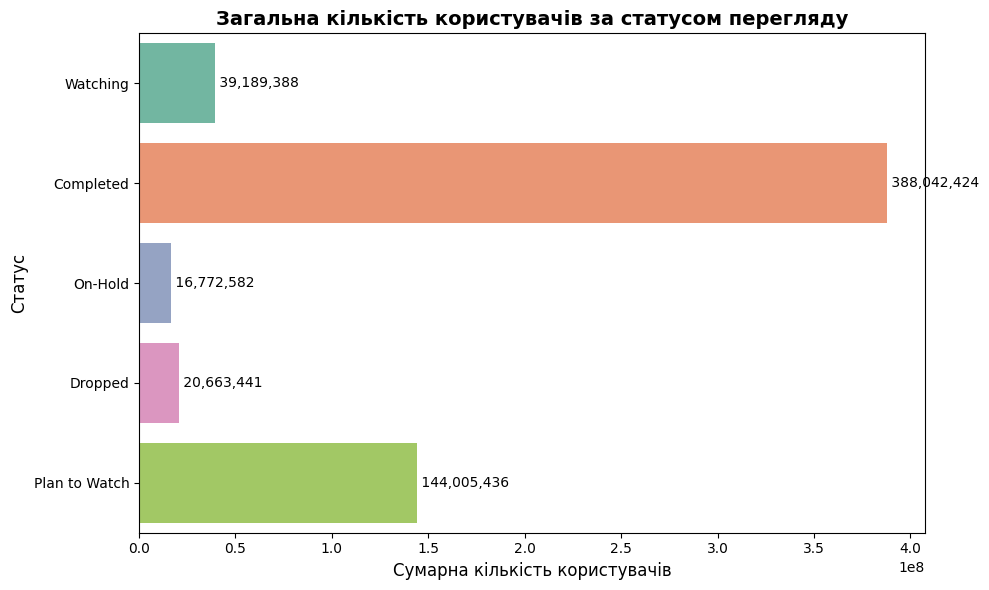

In [93]:
# Список колонок статусу
status_columns = ['Watching', 'Completed', 'On-Hold', 'Dropped', 'Plan to Watch']

# Конвертація колонок у числовий формат (errors='coerce' перетворить будь-які непередбачені артефакти на NaN)
# Використовуємо .fillna(0), щоб гарантувати цілі числа, якщо немає інших протипоказань для цього датасету
for col in status_columns:
    df_anime[col] = pd.to_numeric(df_anime[col], errors='coerce').fillna(0).astype(int)

# Підрахунок загальної суми для кожної категорії по всій базі
total_status_counts = df_anime[status_columns].sum()

# Виведення результатів
print("--- ЗАГАЛЬНА АКТИВНІСТЬ КОРИСТУВАЧІВ ПО ВСІЙ БАЗІ ---")
print(total_status_counts.apply(lambda x: f"{x:,.0f}").to_string())

# Побудова графіка
plt.figure(figsize=(10, 6))
sns.barplot(
    x=total_status_counts.values, 
    y=total_status_counts.index, 
    palette='Set2',
    hue=total_status_counts.index,
    legend=False
)

plt.title('Загальна кількість користувачів за статусом перегляду', fontsize=14, fontweight='bold')
plt.xlabel('Сумарна кількість користувачів', fontsize=12)
plt.ylabel('Статус', fontsize=12)

# Додавання форматованих значень на графік для точності
for index, value in enumerate(total_status_counts.values):
    plt.text(value, index, f' {value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

--- СЕРЕДНІЙ НОРМАЛІЗОВАНИЙ РОЗПОДІЛ СТАТУСІВ (%) ---
Watching          5.37%
Completed        49.05%
On-Hold           2.65%
Dropped           8.12%
Plan to Watch    34.81%


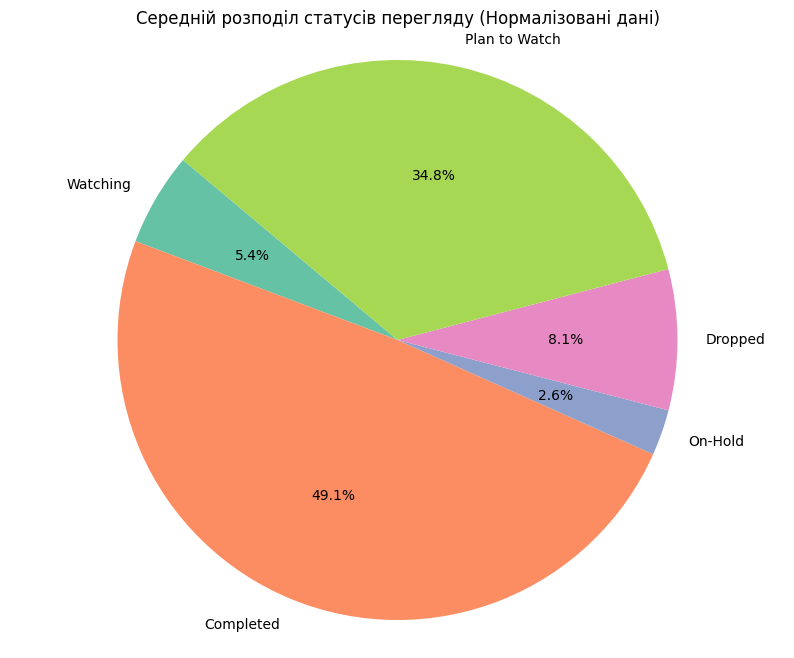

In [94]:
# Список колонок статусу
status_columns = ['Watching', 'Completed', 'On-Hold', 'Dropped', 'Plan to Watch']

# 1. Розрахунок загальної кількості взаємодій для кожного аніме (по рядках)
df_anime['Total_Interactions'] = df_anime[status_columns].sum(axis=1)

# 2. Нормалізація даних: розрахунок відсотка кожної категорії для кожного тайтлу
for col in status_columns:
    # Ділення на загальну кількість взаємодій. fillna(0) обробляє випадки ділення на нуль
    df_anime[f'{col}_Norm_Pct'] = (df_anime[col] / df_anime['Total_Interactions']) * 100
    df_anime[f'{col}_Norm_Pct'] = df_anime[f'{col}_Norm_Pct'].fillna(0)

# 3. Підрахунок середнього значення нормалізованих відсотків по всій базі
norm_columns = [f'{col}_Norm_Pct' for col in status_columns]
average_normalized_status = df_anime[norm_columns].mean()

# Очищення назв індексів для виведення
clean_labels = [col.replace('_Norm_Pct', '') for col in norm_columns]
average_normalized_status.index = clean_labels

# Виведення результатів
print("--- СЕРЕДНІЙ НОРМАЛІЗОВАНИЙ РОЗПОДІЛ СТАТУСІВ (%) ---")
print(average_normalized_status.apply(lambda x: f"{x:.2f}%").to_string())

# 4. Візуалізація результатів (Кругова діаграма)
plt.figure(figsize=(10, 8))

# Побудова кругової діаграми на основі середніх нормалізованих значень
plt.pie(
    average_normalized_status.values, 
    labels=average_normalized_status.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Set2.colors
)

plt.title('Середній розподіл статусів перегляду (Нормалізовані дані)')
plt.axis('equal') # Вирівнювання осей для правильного кола

plt.show()

In [95]:
# Пошук усіх колонок, що починаються з 'Score-'
score_columns = df_anime.filter(regex='^Score-').columns

# Заміна NaN на 0 у знайдених колонках
df_anime[score_columns] = df_anime[score_columns].fillna(0)

# Виведення результату для перевірки
print("--- ОЧИЩЕННЯ КОЛОНОК SCORE ЗАВЕРШЕНО ---")
print(f"Оброблено колонок: {len(score_columns)}")
print("Залишок пропусків (NaN):")
print(df_anime[score_columns].isna().sum().to_string())

--- ОЧИЩЕННЯ КОЛОНОК SCORE ЗАВЕРШЕНО ---
Оброблено колонок: 10
Залишок пропусків (NaN):
Score-10    0
Score-9     0
Score-8     0
Score-7     0
Score-6     0
Score-5     0
Score-4     0
Score-3     0
Score-2     0
Score-1     0


In [96]:
# Формування списку назв колонок, які потрібно видалити
columns_to_drop = [
    'Watching_Norm_Pct', 
    'Completed_Norm_Pct', 
    'On-Hold_Norm_Pct', 
    'Dropped_Norm_Pct', 
    'Plan to Watch_Norm_Pct'
]

# Видалення колонок та збереження результату в той самий датафрейм
df_anime = df_anime.drop(columns=columns_to_drop)

# Виведення результату для перевірки
print("--- ВИДАЛЕННЯ КОЛОНОК ЗАВЕРШЕНО ---")

--- ВИДАЛЕННЯ КОЛОНОК ЗАВЕРШЕНО ---


In [97]:
print("=== 1. ЗАГАЛЬНА ІНФОРМАЦІЯ (df.info()) ===")
# Використовуємо buffer, щоб info() вивелось акуратно, або просто викликаємо
df_anime.info()

=== 1. ЗАГАЛЬНА ІНФОРМАЦІЯ (df.info()) ===
<class 'pandas.DataFrame'>
RangeIndex: 17562 entries, 0 to 17561
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   MAL_ID                  17562 non-null  int64  
 1   Name                    17562 non-null  str    
 2   Score                   12421 non-null  float64
 3   Genres                  17499 non-null  str    
 4   English name            6997 non-null   str    
 5   Japanese name           17514 non-null  str    
 6   Type                    17525 non-null  str    
 7   Episodes                17046 non-null  float64
 8   Aired                   17253 non-null  str    
 9   Premiered               4745 non-null   str    
 10  Producers               9768 non-null   str    
 11  Licensors               3946 non-null   str    
 12  Studios                 10483 non-null  str    
 13  Source                  13995 non-null  str    
 14  Durati

In [98]:
# 1. Визначаємо шлях до папки зі збереженими даними
# Оскільки ноутбук знаходиться в папці 'notebooks', 
# нам потрібно піднятися на рівень вище '..' щоб потрапити в 'data'
processed_data_path = '../data/processed'
file_name = 'anime_clean.parquet'
full_path = os.path.join(processed_data_path, file_name)

# 2. Зберігаємо датафрейм у форматі Parquet
# index=False означає, що ми не зберігаємо технічну колонку з номерами рядків
try:
    df_anime.to_parquet(full_path, index=False)
    print(f"--- УСПІХ ---")
    print(f"Файл успішно збережено за шляхом: {full_path}")
    print(f"Розмір збереженого файлу: {os.path.getsize(full_path) / (1024*1024):.2f} MB")
except Exception as e:
    print(f"--- ПОМИЛКА ---")
    print(f"Не вдалося зберегти файл: {e}")

--- УСПІХ ---
Файл успішно збережено за шляхом: ../data/processed\anime_clean.parquet
Розмір збереженого файлу: 6.26 MB


In [99]:
# 1. Створюємо копію основного датафрейму
df_anime_safe = df_anime.copy()

# 2. Фільтрація за рейтингом (видаляємо Rx - Hentai)
# Залишаємо лише ті рядки, де рейтинг НЕ дорівнює 'Rx - Hentai'
df_anime_safe = df_anime_safe[df_anime_safe['Rating'] != 'Rx - Hentai']

# 3. Фільтрація за жанрами (видаляємо Yaoi, Yuri, Hentai)
# Використовуємо .str.contains з регулярним виразом
# case=False робить пошук незалежним від регістру
# na=False дозволяє ігнорувати порожні значення (якщо вони залишилися)
adult_genres_pattern = 'Yaoi|Yuri|Hentai'
mask_adult_genres = df_anime_safe['Genres'].str.contains(adult_genres_pattern, case=False, na=False)

# Залишаємо лише ті рядки, які НЕ відповідають масці (використовуємо знак ~ для інверсії)
df_anime_safe = df_anime_safe[~mask_adult_genres]

# 4. Налаштування шляхів та збереження
output_file_safe = os.path.join(processed_data_path, 'anime_safe.parquet')

try:
    # Зберігаємо у форматі Parquet без індексів
    df_anime_safe.to_parquet(output_file_safe, engine='pyarrow', index=False)
    
    print("--- УСПІХ ---")
    print(f"Безпечний набір даних збережено!")
    print(f"Шлях: {output_file_safe}")
    print(f"Залишилося тайтлів: {len(df_anime_safe)} (видалено {len(df_anime) - len(df_anime_safe)})")

except Exception as e:
    print(f"--- ПОМИЛКА ПРИ ЗБЕРЕЖЕННІ ---")
    print(f"Деталі: {e}")

--- УСПІХ ---
Безпечний набір даних збережено!
Шлях: ../data/processed\anime_safe.parquet
Залишилося тайтлів: 16183 (видалено 1379)


How are MyAnimeList scores calculated?
All scores given in the database are calculated as a weighted score.

Weighted Score = (v / (v + m)) * S + (m / (v + m)) * C
S = Average score for the anime/manga
v = Number users giving a score for the anime/manga †
m = Minimum number of scored users required to get a calculated score
C = The mean score across the entire Anime/Manga database

† Note that v does not correspond to the "number of scored users" as seen on the database page. Scores from users who have not viewed 1/5 of the series upon its completion are not included. Scores given from illegitimate accounts created to sway votes are also not included in the scoring algorithm.

Not Yet Aired entries have no score and will display N/A. Entries that do not meet the minimum number of scored users will also not display a calculated score.

Top Anime/Manga Rankings
The "Top Upcoming" and "Most Popular" rankings are ordered by the number of users who have added the entry to their list. All other Top Anime and Top Manga rankings are ordered by weighted score, as calculated above. Please note that while R18+ entries calculate a weighted score, they are excluded from the rankings. Music Videos are also excluded from Top Anime.